In [14]:
import pandas as pd
import pandas_gbq
from google.cloud import bigquery
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

print("SIA Wevengers 분석 환경 준비 완료")

SIA Wevengers 분석 환경 준비 완료


In [15]:

import pandas as pd
import pandas_gbq
from google.oauth2 import service_account

from google.oauth2 import service_account

# 1. 신분증(JSON 키) 경로 지정
KEY_PATH = 'google_key.json'

# 2. 인증 객체 생성
credentials = service_account.Credentials.from_service_account_file(KEY_PATH)

# 3. 프로젝트 ID 설정
project_id = 'coral-bucksaw-482803-p2'

# 4. 데이터 불러오기
query = "SELECT SQLDATE FROM `gdelt-bq.full.events` LIMIT 5"
df = pandas_gbq.read_gbq(query, project_id=project_id, credentials=credentials)

print("인증 성공! 데이터를 가져왔습니다.")

Downloading: 100%|██████████|
인증 성공! 데이터를 가져왔습니다.


In [16]:
from spacetrack import SpaceTrackClient

st = SpaceTrackClient(
    identity="yulihyeon06@gmail.com",
    password="Rosa900108liu860606"
)

# tle_latest → gp 로 변경
try:
    result = list(st.gp(
        norad_cat_id=25544,   # ISS
        orderby="epoch desc",
        limit=1,
        format="tle"
    ))
    print("성공!")
    print(result[0] if result else "데이터 없음")
except Exception as e:
    print(f"실패: {repr(e)}")

성공!
1


In [ ]:
"""
2022-08-04 진먼기지지휘부 상공 통과 위성 리스트 확인
사전 조건: st = SpaceTrackClient(...) 노트북에서 미리 생성
"""

import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── 설정 ─────────────────────────────────────────────────────────
ROI = {"name": "진먼기지지휘부", "lat": 24.415, "lon": 118.295}
START_DT          = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT            = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEVATION_DEG = 30
INTERVAL_MIN      = 1

# ════════════════════════════════════════════════════════════════
# Step 1 — TLE 수집
# ════════════════════════════════════════════════════════════════
print("Step 1 — TLE 수집 중...")

raw     = list(st.gp_history(
    epoch="2022-08-04--2022-08-04",
    orderby="norad_cat_id asc",
    limit=5000,
    format="json"
))
records = json.loads("".join(raw))
print(f"  수집: {len(records)}건")

# TLE 추출
tle_list = []
for rec in records:
    l1 = rec.get("TLE_LINE1", "")
    l2 = rec.get("TLE_LINE2", "")
    if l1.startswith("1 ") and l2.startswith("2 "):
        tle_list.append({
            "name":     rec.get("OBJECT_NAME", "UNKNOWN").strip(),
            "norad_id": rec.get("NORAD_CAT_ID", ""),
            "line1":    l1,
            "line2":    l2,
        })

print(f"  TLE 파싱: {len(tle_list)}기")

# ════════════════════════════════════════════════════════════════
# Step 2 — 궤도 계산 + 통과 탐지
# ════════════════════════════════════════════════════════════════
print(f"\nStep 2 — 궤도 계산 중 ({len(tle_list)}기)...")

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(tle, roi, start_dt, end_dt):
    try:
        sat = Satrec.twoline2rv(tle["line1"], tle["line2"])
    except Exception:
        return []

    passes, buf = [], []
    cur     = start_dt
    step    = timedelta(minutes=INTERVAL_MIN)
    in_pass = False

    while cur <= end_dt:
        jd, fr   = jday(cur.year, cur.month, cur.day,
                        cur.hour, cur.minute, cur.second)
        e, r, v  = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue

        x, y, z  = r
        alt      = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat      = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        jd_t     = jd + fr
        T        = (jd_t - 2451545.0) / 36525.0
        gmst     = (280.46061837 + 360.98564736629
                    * (jd_t - 2451545.0) + 0.000387933 * T**2) % 360
        lon      = (np.degrees(np.arctan2(y, x)) - gmst + 180) % 360 - 180
        dist     = haversine_km(roi["lat"], roi["lon"], lat, lon)
        elev     = np.degrees(np.arctan2(alt, dist)) if dist > 1 else 90.0

        if elev >= MIN_ELEVATION_DEG:
            buf.append({"time": cur, "elev": round(elev, 1),
                        "alt": round(alt, 1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step

    return passes

# 전체 위성 루프
results = []
for i, tle in enumerate(tle_list):
    passes = find_passes(tle, ROI, START_DT, END_DT)
    for p in passes:
        results.append({
            "위성명":    tle["name"],
            "NORAD_ID": tle["norad_id"],
            "통과시간(UTC)": str(p["time"])[:19],
            "최대앙각(°)":  p["elev"],
            "궤도고도(km)": p["alt"],
        })
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(tle_list)} 처리... 통과 {len(results)}회")

# ════════════════════════════════════════════════════════════════
# Step 3 — 결과 출력
# ════════════════════════════════════════════════════════════════
passes_df = pd.DataFrame(results)

if passes_df.empty:
    print("\n⚠ 통과 위성 없음")
else:
    passes_df = passes_df.sort_values(
        "최대앙각(°)", ascending=False).reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"2022-08-04 {ROI['name']} 상공 통과 위성")
    print(f"{'='*60}")
    print(f"총 {passes_df['위성명'].nunique()}기 / {len(passes_df)}회 통과\n")

    print(passes_df[["위성명","NORAD_ID","통과시간(UTC)",
                      "최대앙각(°)","궤도고도(km)"]].to_string(index=False))

    passes_df.to_csv("passes_20220804.csv",
                     index=False, encoding="utf-8-sig")
    print("\n→ passes_20220804.csv 저장 완료")

In [ ]:
"""
2022-08-04 진먼기지지휘부 상공 통과 위성 리스트 확인
사전 조건: st = SpaceTrackClient(...) 노트북에서 미리 생성
"""

import json
import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── 설정 ─────────────────────────────────────────────────────────
ROI = {"name": "진먼기지지휘부", "lat": 24.415, "lon": 118.295}
START_DT          = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT            = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEVATION_DEG = 30
INTERVAL_MIN      = 1

# ════════════════════════════════════════════════════════════════
# Step 1 — TLE 수집
# ════════════════════════════════════════════════════════════════
print("Step 1 — TLE 수집 중...")

raw     = list(st.gp_history(
    epoch=">2022-08-03,<2022-08-05",
    orderby="norad_cat_id asc",
    limit=5000,
    format="json"
))
records = json.loads("".join(raw))
print(f"  수집: {len(records)}건")

# TLE 추출
tle_list = []
for rec in records:
    l1 = rec.get("TLE_LINE1", "")
    l2 = rec.get("TLE_LINE2", "")
    if l1.startswith("1 ") and l2.startswith("2 "):
        tle_list.append({
            "name":     rec.get("OBJECT_NAME", "UNKNOWN").strip(),
            "norad_id": rec.get("NORAD_CAT_ID", ""),
            "line1":    l1,
            "line2":    l2,
        })

print(f"  TLE 파싱: {len(tle_list)}기")

# ════════════════════════════════════════════════════════════════
# Step 2 — 궤도 계산 + 통과 탐지
# ════════════════════════════════════════════════════════════════
print(f"\nStep 2 — 궤도 계산 중 ({len(tle_list)}기)...")

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(tle, roi, start_dt, end_dt):
    try:
        sat = Satrec.twoline2rv(tle["line1"], tle["line2"])
    except Exception:
        return []

    passes, buf = [], []
    cur     = start_dt
    step    = timedelta(minutes=INTERVAL_MIN)
    in_pass = False

    while cur <= end_dt:
        jd, fr   = jday(cur.year, cur.month, cur.day,
                        cur.hour, cur.minute, cur.second)
        e, r, v  = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue

        x, y, z  = r
        alt      = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat      = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        jd_t     = jd + fr
        T        = (jd_t - 2451545.0) / 36525.0
        gmst     = (280.46061837 + 360.98564736629
                    * (jd_t - 2451545.0) + 0.000387933 * T**2) % 360
        lon      = (np.degrees(np.arctan2(y, x)) - gmst + 180) % 360 - 180
        dist     = haversine_km(roi["lat"], roi["lon"], lat, lon)
        elev     = np.degrees(np.arctan2(alt, dist)) if dist > 1 else 90.0

        if elev >= MIN_ELEVATION_DEG:
            buf.append({"time": cur, "elev": round(elev, 1),
                        "alt": round(alt, 1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step

    return passes

# 전체 위성 루프
results = []
for i, tle in enumerate(tle_list):
    passes = find_passes(tle, ROI, START_DT, END_DT)
    for p in passes:
        results.append({
            "위성명":    tle["name"],
            "NORAD_ID": tle["norad_id"],
            "통과시간(UTC)": str(p["time"])[:19],
            "최대앙각(°)":  p["elev"],
            "궤도고도(km)": p["alt"],
        })
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(tle_list)} 처리... 통과 {len(results)}회")

# ════════════════════════════════════════════════════════════════
# Step 3 — 결과 출력
# ════════════════════════════════════════════════════════════════
passes_df = pd.DataFrame(results)

if passes_df.empty:
    print("\n⚠ 통과 위성 없음")
else:
    passes_df = passes_df.sort_values(
        "최대앙각(°)", ascending=False).reset_index(drop=True)

    print(f"\n{'='*60}")
    print(f"2022-08-04 {ROI['name']} 상공 통과 위성")
    print(f"{'='*60}")
    print(f"총 {passes_df['위성명'].nunique()}기 / {len(passes_df)}회 통과\n")

    print(passes_df[["위성명","NORAD_ID","통과시간(UTC)",
                      "최대앙각(°)","궤도고도(km)"]].to_string(index=False))

    passes_df.to_csv("passes_20220804.csv",
                     index=False, encoding="utf-8-sig")
    print("\n→ passes_20220804.csv 저장 완료")

동일 NORAD ID + 동일 시간 중복을 제거
운용 가능 고도 필터 (300~1200km LEO만)
잔해물·비운용 위성을 필터링

In [ ]:
# 1. 중복 제거 (NORAD_ID + 통과시간 기준)
passes_clean = passes_df.drop_duplicates(
    subset=["NORAD_ID", "통과시간(UTC)"]
).copy()

# 2. 운용 가능 고도 필터 (300~1200km LEO만)
passes_clean = passes_clean[
    passes_clean["궤도고도(km)"].between(300, 1200)
].copy()

# 3. 앙각 높은 순 정렬
passes_clean = passes_clean.sort_values(
    "최대앙각(°)", ascending=False).reset_index(drop=True)

print(f"정제 후: {passes_clean['NORAD_ID'].nunique()}기 / {len(passes_clean)}회")
print(f"\n[상위 30개]")
print(passes_clean[["위성명","NORAD_ID","통과시간(UTC)",
                     "최대앙각(°)","궤도고도(km)"]].head(30).to_string(index=False))

In [ ]:
# Step 4만 따로 실행할 경우
passes_clean = passes_df.drop_duplicates(subset=["NORAD_ID","통과시간(UTC)"]).copy()
passes_clean = passes_clean[passes_clean["궤도고도(km)"].between(300, 1200)].copy()
passes_clean = passes_clean.sort_values("최대앙각(°)", ascending=False).reset_index(drop=True)
print(f"정제 후: {passes_clean['NORAD_ID'].nunique()}기 / {len(passes_clean)}회")
print(passes_clean.head(30).to_string(index=False))

In [ ]:
# 잔해물·로켓바디 제외 + 실제 운용 위성만
passes_ops = passes_clean[
    ~passes_clean["위성명"].str.contains(
        "DEB|R/B|DEBRIS|ROCKET|TRANSTAGE|AGENA|ABLESTAR|SCOUT|ATLAS|TITAN|THOR|COSMOS|SL-",
        case=False, na=False
    )
].copy()

print(f"운용 위성만: {passes_ops['NORAD_ID'].nunique()}기 / {len(passes_ops)}회")
print(passes_ops[["위성명","NORAD_ID","통과시간(UTC)",
                   "최대앙각(°)","궤도고도(km)"]].head(50).to_string(index=False))

In [ ]:
# 2010년 이후 발사 위성만 (NORAD_ID 기준 약 37000 이상)
# + 현재 운용 중인 주요 지구관측 위성 NORAD ID 직접 지정

# NORAD_ID 타입 확인
print(passes_ops["NORAD_ID"].dtype)
print(passes_ops["NORAD_ID"].head(3))

# 문자열이면 정수 변환 후 필터
passes_ops["NORAD_ID_int"] = pd.to_numeric(
    passes_ops["NORAD_ID"], errors="coerce")

print(f"\nNORAD_ID 범위: {passes_ops['NORAD_ID_int'].min()} ~ {passes_ops['NORAD_ID_int'].max()}")

# 2010년 이후 (NORAD_ID >= 37000)
passes_modern = passes_ops[
    passes_ops["NORAD_ID_int"] >= 37000
].copy()

print(f"\n2010년 이후 위성: {passes_modern['NORAD_ID_int'].nunique()}기 / {len(passes_modern)}회")
print(passes_modern[["위성명","NORAD_ID","통과시간(UTC)",
                      "최대앙각(°)","궤도고도(km)"]].to_string(index=False))

In [ ]:
import json

# NORAD_ID 내림차순으로 최신 위성부터 수집
raw = list(st.gp_history(
    epoch=">2022-08-03,<2022-08-05",
    orderby="norad_cat_id desc",   # ← desc로 변경
    limit=5000,
    format="json"
))
records = json.loads("".join(raw))
print(f"수집: {len(records)}건")

# NORAD_ID 범위 확인
norad_ids = [int(r.get("NORAD_CAT_ID", 0)) for r in records]
print(f"NORAD_ID 범위: {min(norad_ids)} ~ {max(norad_ids)}")
print(f"37000 이상: {sum(1 for n in norad_ids if n >= 37000)}건")
print(f"샘플 위성명:")
for r in records[:5]:
    print(f"  {r.get('NORAD_CAT_ID')} {r.get('OBJECT_NAME')}")

현재 코드 그대로 limit=5000 + desc
최신 위성 5,000기에서 통과 위성을 찾습니다.

In [ ]:
import json
import numpy as np
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── Step 1: 최신 위성 TLE 재수집 (desc) ─────────────────────────
print("TLE 재수집 중 (최신 위성 5000기)...")
raw     = list(st.gp_history(
    epoch=">2022-08-03,<2022-08-05",
    orderby="norad_cat_id desc",
    limit=5000,
    format="json"
))
records = json.loads("".join(raw))

tle_list_new = []
for rec in records:
    l1 = rec.get("TLE_LINE1", "")
    l2 = rec.get("TLE_LINE2", "")
    if l1.startswith("1 ") and l2.startswith("2 "):
        tle_list_new.append({
            "name":     rec.get("OBJECT_NAME", "").strip(),
            "norad_id": int(rec.get("NORAD_CAT_ID", 0)),
            "line1":    l1,
            "line2":    l2,
        })
print(f"TLE 파싱: {len(tle_list_new)}기")
print(f"NORAD_ID 범위: {min(t['norad_id'] for t in tle_list_new)} ~ "
      f"{max(t['norad_id'] for t in tle_list_new)}")

# ── Step 2: 궤도 계산 ────────────────────────────────────────────
ROI      = {"name": "진먼기지지휘부", "lat": 24.415, "lon": 118.295}
START_DT = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT   = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEV = 30

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(tle, roi, start_dt, end_dt):
    try:
        sat = Satrec.twoline2rv(tle["line1"], tle["line2"])
    except Exception:
        return []
    passes, buf, in_pass = [], [], False
    cur  = start_dt
    step = timedelta(minutes=1)
    while cur <= end_dt:
        jd, fr  = jday(cur.year, cur.month, cur.day,
                       cur.hour, cur.minute, cur.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue
        x, y, z = r
        alt  = np.sqrt(x**2+y**2+z**2) - 6371.0
        lat  = np.degrees(np.arctan2(z, np.sqrt(x**2+y**2)))
        jd_t = jd + fr
        T    = (jd_t - 2451545.0) / 36525.0
        gmst = (280.46061837 + 360.98564736629*(jd_t-2451545.0)
                + 0.000387933*T**2) % 360
        lon  = (np.degrees(np.arctan2(y,x)) - gmst + 180) % 360 - 180
        dist = haversine_km(roi["lat"], roi["lon"], lat, lon)
        elev = np.degrees(np.arctan2(alt, dist)) if dist > 1 else 90.0
        if elev >= MIN_ELEV:
            buf.append({"time": cur, "elev": round(elev,1),
                        "alt": round(alt,1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step
    return passes

print(f"\n궤도 계산 중 ({len(tle_list_new)}기)...")
results_new = []
for i, tle in enumerate(tle_list_new):
    for p in find_passes(tle, ROI, START_DT, END_DT):
        results_new.append({
            "위성명":       tle["name"],
            "NORAD_ID":    tle["norad_id"],
            "통과시간(UTC)": str(p["time"])[:19],
            "최대앙각(°)":  p["elev"],
            "궤도고도(km)": p["alt"],
        })
    if (i+1) % 500 == 0:
        print(f"  {i+1}/{len(tle_list_new)} 처리... 통과 {len(results_new)}회")

# ── Step 3: 정제 ─────────────────────────────────────────────────
passes_new = pd.DataFrame(results_new)

if passes_new.empty:
    print("⚠ 통과 위성 없음")
else:
    passes_new = passes_new.drop_duplicates(
        subset=["NORAD_ID","통과시간(UTC)"])
    passes_new = passes_new[passes_new["궤도고도(km)"].between(300, 1200)]
    passes_new = passes_new[passes_new["NORAD_ID"] >= 37000]
    passes_new = passes_new.sort_values(
        "최대앙각(°)", ascending=False).reset_index(drop=True)

    print(f"최신 운용 위성: {passes_new['NORAD_ID'].nunique()}기 / {len(passes_new)}회")
    print(passes_new[["위성명","NORAD_ID","통과시간(UTC)",
                       "최대앙각(°)","궤도고도(km)"]].to_string(index=False))

    passes_new.to_csv("passes_20220804_modern.csv",
                      index=False, encoding="utf-8-sig")
    print("\n→ passes_20220804_modern.csv 저장 완료")


In [ ]:
"""
2022-08-04 진먼기지지휘부 상공 통과 위성 67기
광학 / SAR / 기타 분류 + 우선순위 정렬
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 위성 분류 사전
# ════════════════════════════════════════════════════════════════
# (위성명 키워드, 센서종류, 해상도m, 운용국, 설명)
SAT_CATALOG = {
    # ── SAR ──────────────────────────────────────────────────────
    "ICEYE":        ("SAR",   1.0,  "FIN", "ICEYE 상업 SAR"),
    "YAOGAN-35":    ("SAR",   1.0,  "CHN", "PLA 정찰 SAR·광학"),
    "HAWK":         ("RF",    None, "USA", "HawkEye360 전파신호"),
    "SLINGSHOT":    ("RF",    None, "USA", "Slingshot RF"),
    # ── 광학 ─────────────────────────────────────────────────────
    "GHGSAT":       ("OPT",   25.0, "CAN", "GHGSat 가스탐지"),
    "LEMUR":        ("MET",   None, "USA", "Spire 기상·AIS"),
    "FOSSASAT":     ("IOT",   None, "ESP", "FossaSat IoT"),
    "SNUGLITE":     ("OPT",   None, "KOR", "서울대 큐브샛"),
    "SBUDNIC":      ("OPT",   None, "USA", "Brown Univ 큐브샛"),
    "MISR":         ("OPT",   None, "IRN", "이란 큐브샛"),
    "CTIM":         ("MET",   None, "USA", "Colorado 기상"),
    "RANDEV":       ("EXP",   None, "RUS", "러시아 실험위성"),
    "KSLV":         ("DUM",   None, "KOR", "누리호 더미"),
    "STEP CUBE":    ("OPT",   None, "KOR", "조선대 큐브샛"),
    "GLOBALSTAR":   ("COM",   None, "USA", "Globalstar 통신"),
    "VIGORIDE":     ("TUG",   None, "USA", "Momentus 우주예인선"),
    "MIMAN":        ("OPT",   None, "ISR", "이스라엘 큐브샛"),
    "MEZNSAT":      ("OPT",   None, "UAE", "UAE 큐브샛"),
    "PLANETUM":     ("OPT",   None, "CZE", "체코 큐브샛"),
    "UNICORN":      ("OPT",   None, "GBR", "Alba Orbital 광학"),
    "TRSI":         ("IOT",   None, "USA", "IoT 위성"),
    "LIGHT":        ("OPT",   None, "ISR", "이스라엘 광학"),
}

# 분류 함수
def classify_sat(name):
    name_upper = name.upper()
    for keyword, info in SAT_CATALOG.items():
        if keyword.upper() in name_upper:
            return info
    return ("UNK", None, "UNK", "분류 미상")

# passes_eo에 분류 적용
passes_eo = passes_eo.copy()
classify_results = passes_eo["위성명"].apply(classify_sat)
passes_eo["센서종류"]   = [r[0] for r in classify_results]
passes_eo["해상도(m)"]  = [r[1] for r in classify_results]
passes_eo["운용국"]     = [r[2] for r in classify_results]
passes_eo["설명"]       = [r[3] for r in classify_results]

# ════════════════════════════════════════════════════════════════
# 우선순위 점수
# ════════════════════════════════════════════════════════════════
# SAR=3점, OPT=2점, RF=1점, 기타=0점
# + 앙각 정규화 (0~1)
# + 해상도 보정 (해상도 있으면 +1)
SENSOR_SCORE = {"SAR": 3, "OPT": 2, "RF": 1,
                "MET": 0, "COM": 0, "EXP": 0,
                "IOT": 0, "TUG": 0, "DUM": 0, "UNK": 0}

elev_max = passes_eo["최대앙각(°)"].max()
elev_min = passes_eo["최대앙각(°)"].min()

passes_eo["sensor_score"] = passes_eo["센서종류"].map(SENSOR_SCORE).fillna(0)
passes_eo["elev_norm"]    = ((passes_eo["최대앙각(°)"] - elev_min)
                              / (elev_max - elev_min + 1e-9))
passes_eo["res_bonus"]    = passes_eo["해상도(m)"].notna().astype(int)

passes_eo["priority_score"] = (
    passes_eo["sensor_score"] * 0.5
    + passes_eo["elev_norm"]  * 0.3
    + passes_eo["res_bonus"]  * 0.2
).round(4)

# 우선순위 정렬
passes_eo = passes_eo.sort_values(
    ["priority_score","최대앙각(°)"], ascending=False
).reset_index(drop=True)

# ════════════════════════════════════════════════════════════════
# 결과 출력
# ════════════════════════════════════════════════════════════════
print("=" * 80)
print("2022-08-04 진먼기지지휘부 상공 통과 위성 — 센서 분류 + 우선순위")
print("=" * 80)

# 센서 종류별 요약
print(f"\n[센서 종류별 위성 수]")
print(passes_eo.groupby("센서종류")["NORAD_ID"].nunique()
      .sort_values(ascending=False).to_string())

# 촬영 가능 위성 (SAR + OPT)
imaging = passes_eo[passes_eo["센서종류"].isin(["SAR","OPT"])]
print(f"\n[촬영 가능 위성 (SAR + OPT): {imaging['NORAD_ID'].nunique()}기]")
print(f"\n{'순위':>4} {'위성명':<25} {'센서':>5} {'운용국':>6} "
      f"{'통과시간(UTC)':<22} {'앙각°':>7} {'고도km':>7} {'점수':>7}  설명")
print("-" * 105)
for rank, (_, row) in enumerate(imaging.iterrows(), 1):
    print(f"  {rank:>3}  {str(row['위성명'])[:24]:<24} "
          f"{row['센서종류']:>5} {row['운용국']:>6} "
          f"{row['통과시간(UTC)']:<20} "
          f"{row['최대앙각(°)']:>7.1f} "
          f"{row['궤도고도(km)']:>7.1f} "
          f"{row['priority_score']:>7.4f}  "
          f"{row['설명']}")

# 전체 목록
print(f"\n[전체 위성 목록 (우선순위 순)]")
print(f"\n{'순위':>4} {'위성명':<25} {'센서':>5} {'운용국':>6} "
      f"{'통과시간(UTC)':<22} {'앙각°':>7} {'점수':>7}")
print("-" * 80)
for rank, (_, row) in enumerate(passes_eo.iterrows(), 1):
    print(f"  {rank:>3}  {str(row['위성명'])[:24]:<24} "
          f"{row['센서종류']:>5} {row['운용국']:>6} "
          f"{row['통과시간(UTC)']:<20} "
          f"{row['최대앙각(°)']:>7.1f} "
          f"{row['priority_score']:>7.4f}")

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    "2022-08-04 진먼기지지휘부 상공 통과 위성 — 센서 분류 + 우선순위",
    fontsize=13, y=1.02
)

sensor_colors = {
    "SAR": "#C44E52", "OPT": "#4C72B0", "RF": "#DD8452",
    "MET": "#55A868", "COM": "#AAAAAA", "UNK": "#CCCCCC",
    "EXP": "#9B59B6", "IOT": "#95A5A6", "TUG": "#BDC3C7",
    "DUM": "#ECF0F1",
}

# ① 센서별 위성 수
ax = axes[0]
cnt = passes_eo.groupby("센서종류")["NORAD_ID"].nunique().sort_values(ascending=False)
colors = [sensor_colors.get(s, "#888") for s in cnt.index]
bars = ax.bar(cnt.index, cnt.values, color=colors, alpha=0.85, edgecolor="white")
for bar, v in zip(bars, cnt.values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.2,
            str(v), ha="center", fontsize=9)
ax.set_ylabel("위성 수")
ax.set_title("① 센서 종류별 위성 수")

# ② 우선순위 상위 20개
ax = axes[1]
top20 = passes_eo.head(20)
bar_colors = [sensor_colors.get(s, "#888") for s in top20["센서종류"]]
ax.barh(range(len(top20)), top20["priority_score"],
        color=bar_colors, alpha=0.85, edgecolor="white")
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(
    [f"{row['위성명'][:18]} ({row['센서종류']})"
     for _, row in top20.iterrows()],
    fontsize=7.5
)
ax.set_xlabel("우선순위 점수")
ax.set_title("② 우선순위 상위 20개")
ax.invert_yaxis()

# ③ 앙각 vs 고도 산점도
ax = axes[2]
for sensor, group in passes_eo.groupby("센서종류"):
    color = sensor_colors.get(sensor, "#888")
    ax.scatter(group["최대앙각(°)"], group["궤도고도(km)"],
               s=60, color=color, alpha=0.7,
               label=sensor, edgecolors="white", linewidth=0.5)
ax.set_xlabel("최대 앙각 (°)")
ax.set_ylabel("궤도 고도 (km)")
ax.set_title("③ 앙각 vs 고도 (센서별 색상)")
ax.legend(fontsize=7.5, loc="upper right")
ax.axhline(600, color="gray", linewidth=0.8,
           linestyle="--", alpha=0.5, label="600km")

plt.tight_layout()
plt.savefig("sat_classification_20220804.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n→ sat_classification_20220804.png 저장 완료")

# CSV 저장
passes_eo.to_csv("passes_classified_20220804.csv",
                 index=False, encoding="utf-8-sig")
print("→ passes_classified_20220804.csv 저장 완료")

In [ ]:
# UNK 위성 목록 확인
unk_sats = passes_eo[passes_eo["센서종류"] == "UNK"][
    ["위성명","NORAD_ID","통과시간(UTC)","최대앙각(°)"]
].drop_duplicates("NORAD_ID").sort_values("최대앙각(°)", ascending=False)
print(unk_sats.to_string(index=False))

In [ ]:
# UNK 위성 추가 분류 사전
UNK_CATALOG = {
    "NACHOS":       ("OPT",   None, "USA", "NRL 나노위성 광학"),
    "NUSAT":        ("OPT",   6.0,  "ARG", "Satellogic 다분광 광학"),
    "ION SCV":      ("TUG",   None, "ITA", "D-Orbit 우주운송체"),
    "GAOFEN":       ("OPT",   0.5,  "CHN", "중국 고해상도 광학"),
    "SUPERVIEW":    ("OPT",   0.5,  "CHN", "중국 상업 고해상도 광학"),
    "DUMMY":        ("DUM",   None, "KOR", "더미 위성"),
    "UMBRA":        ("SAR",   0.25, "USA", "Umbra 상업 SAR — 최고해상도"),
    "RECURVE":      ("OPT",   None, "USA", "큐브샛 광학"),
    "CONNECTA":     ("IOT",   None, "ESP", "IoT 통신"),
    "ARMSAT":       ("OPT",   None, "PHI", "필리핀 큐브샛"),
    "SZ-14":        ("CRW",   None, "CHN", "선저우-14 유인우주선"),
    "CSS":          ("CRW",   None, "CHN", "중국 우주정거장"),
    "GUARDIAN":     ("OPT",   None, "USA", "큐브샛 광학"),
    "VEERY":        ("OPT",   None, "USA", "Hawks 큐브샛"),
    "OP2":          ("OPT",   None, "USA", "Tyvak 큐브샛"),
    "SHERPA":       ("TUG",   None, "USA", "Spaceflight 우주운송체"),
    "PROGRESS":     ("CRW",   None, "RUS", "러시아 화물우주선"),
    "CRS-25":       ("CRW",   None, "USA", "SpaceX 화물우주선"),
    "AMS":          ("EXP",   None, "INT", "알파자기분광기 실험"),
    "PVSAT":        ("OPT",   None, "NLD", "네덜란드 큐브샛"),
    "CPOD":         ("EXP",   None, "USA", "랑데부 실험"),
    "PTD":          ("EXP",   None, "USA", "NASA 기술실증"),
    "CNCE":         ("IOT",   None, "USA", "Swarm IoT"),
    "WENTIAN":      ("LAB",   None, "CHN", "중국 우주정거장 모듈"),
}

# 기존 UNK에 추가 분류 적용
for i, row in passes_eo[passes_eo["센서종류"] == "UNK"].iterrows():
    name_upper = row["위성명"].upper()
    for keyword, info in UNK_CATALOG.items():
        if keyword.upper() in name_upper:
            passes_eo.at[i, "센서종류"]  = info[0]
            passes_eo.at[i, "해상도(m)"] = info[1]
            passes_eo.at[i, "운용국"]    = info[2]
            passes_eo.at[i, "설명"]      = info[3]
            break

# 재점수 계산
elev_max = passes_eo["최대앙각(°)"].max()
elev_min = passes_eo["최대앙각(°)"].min()
passes_eo["sensor_score"] = passes_eo["센서종류"].map(SENSOR_SCORE).fillna(0)
passes_eo["elev_norm"]    = ((passes_eo["최대앙각(°)"] - elev_min)
                              / (elev_max - elev_min + 1e-9))
passes_eo["res_bonus"]    = passes_eo["해상도(m)"].notna().astype(int)
passes_eo["priority_score"] = (
    passes_eo["sensor_score"] * 0.5
    + passes_eo["elev_norm"]  * 0.3
    + passes_eo["res_bonus"]  * 0.2
).round(4)

passes_eo = passes_eo.sort_values(
    ["priority_score","최대앙각(°)"], ascending=False
).reset_index(drop=True)

# 결과 출력
print("[센서 종류별 위성 수 — 업데이트]")
print(passes_eo.groupby("센서종류")["NORAD_ID"].nunique()
      .sort_values(ascending=False).to_string())

print(f"\n[촬영 가능 위성 (SAR + OPT) 우선순위]")
imaging = passes_eo[passes_eo["센서종류"].isin(["SAR","OPT"])]
print(f"{'순위':>4} {'위성명':<25} {'센서':>5} {'운용국':>6} "
      f"{'통과시간(UTC)':<22} {'앙각°':>7} {'고도km':>7} {'해상도m':>8}  설명")
print("-" * 110)
for rank, (_, row) in enumerate(imaging.iterrows(), 1):
    res = f"{row['해상도(m)']}m" if pd.notna(row["해상도(m)"]) else "-"
    print(f"  {rank:>3}  {str(row['위성명'])[:24]:<24} "
          f"{row['센서종류']:>5} {row['운용국']:>6} "
          f"{row['통과시간(UTC)']:<20} "
          f"{row['최대앙각(°)']:>7.1f} "
          f"{row['궤도고도(km)']:>7.1f} "
          f"{res:>8}  {row['설명']}")

passes_eo.to_csv("passes_classified_20220804_v2.csv",
                 index=False, encoding="utf-8-sig")
print("\n→ passes_classified_20220804_v2.csv 저장 완료")

 22년 8월 4일 지나간 시간 별 위성 시각화

In [ ]:
"""
2022-08-04 진먼기지지휘부 상공 통과 위성
시간별 타임라인 시각화
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# 데이터 준비 — passes_eo 기반
# ════════════════════════════════════════════════════════════════
# 촬영 의미 있는 위성만 (SAR + OPT, 큐브샛 제외)
IMAGING_SENSORS = ["SAR", "OPT"]
EXCLUDE_KEYWORDS = [
    "CUBESAT","DUMMY","CUBE LAB","FOSSASAT","SNUGLITE",
    "SBUDNIC","MIMAN","MEZNSAT","CTIM","PVSAT","VEERY",
    "NACHOS","RECURVE","GUARDIAN","ARMSAT","CONNECTA",
    "AMS","CPOD","PTD","CNCE","PROGRESS","CRS","SZ-14",
    "CSS","WENTIAN","SHERPA","ION SCV","OP2","VIGORIDE",
    "LEMUR","GLOBALSTAR"
]

df_plot = passes_eo[
    passes_eo["센서종류"].isin(IMAGING_SENSORS)
].copy()

# 큐브샛·비촬영 위성 제외
mask = df_plot["위성명"].str.upper().apply(
    lambda n: not any(kw.upper() in n for kw in EXCLUDE_KEYWORDS)
)
df_plot = df_plot[mask].copy()

# 통과 시간 → 시각 (소수 시간)
df_plot["통과시간(UTC)"] = pd.to_datetime(df_plot["통과시간(UTC)"])
df_plot["hour_float"]   = (df_plot["통과시간(UTC)"].dt.hour
                           + df_plot["통과시간(UTC)"].dt.minute / 60)

# 센서별 색상
SENSOR_CLR = {"SAR": "#E74C3C", "OPT": "#3498DB"}
df_plot["color"] = df_plot["센서종류"].map(SENSOR_CLR)

# 위성별 최고 앙각 기준 대표 통과 선택
df_repr = (df_plot.sort_values("최대앙각(°)", ascending=False)
           .drop_duplicates(subset=["위성명"])
           .sort_values("hour_float")
           .reset_index(drop=True))

print(f"촬영 후보 위성: {len(df_repr)}기")
print(df_repr[["위성명","센서종류","통과시간(UTC)",
               "최대앙각(°)","궤도고도(km)","설명"]].to_string(index=False))

# ════════════════════════════════════════════════════════════════
# Figure 1 — 타임라인 + 앙각 버블
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig,
                        height_ratios=[3, 1], hspace=0.35, wspace=0.3)

# ── Chart 1: 타임라인 (메인) ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("#0D1B2A")
fig.patch.set_facecolor("#0D1B2A")

# 배경 격자
for h in range(0, 25, 2):
    ax1.axvline(h, color="#1E3A5F", linewidth=0.5, zorder=1)
for h in range(0, 25):
    ax1.axvline(h, color="#162840", linewidth=0.3, zorder=1)

# 위성별 타임라인
for i, (_, row) in enumerate(df_repr.iterrows()):
    color   = SENSOR_CLR.get(row["센서종류"], "#888")
    size    = (row["최대앙각(°)"] / 90) * 300 + 50

    # 통과 시간 마커
    ax1.scatter(row["hour_float"], i,
                s=size, c=color, alpha=0.85, zorder=5,
                edgecolors="white", linewidth=0.8)

    # 위성명 레이블
    ax1.text(row["hour_float"] + 0.2, i,
             f"{row['위성명']}",
             fontsize=8, color="white", va="center",
             fontweight="bold" if row["센서종류"] == "SAR" else "normal")

    # 앙각 텍스트
    ax1.text(row["hour_float"] - 0.15, i,
             f"{row['최대앙각(°)']:.0f}°",
             fontsize=7, color=color, va="center", ha="right")

    # 수평 점선
    ax1.axhline(i, color="#1E3A5F", linewidth=0.4,
                linestyle=":", zorder=1, alpha=0.5)

# X축 설정
ax1.set_xlim(-0.5, 24.5)
ax1.set_ylim(-0.8, len(df_repr) - 0.2)
ax1.set_xticks(range(0, 25, 1))
ax1.set_xticklabels([f"{h:02d}:00" for h in range(25)],
                    fontsize=7.5, color="#8BAFC8", rotation=45)
ax1.set_yticks([])
ax1.set_xlabel("통과 시간 (UTC, 2022-08-04)",
               fontsize=10, color="#8BAFC8", labelpad=8)
ax1.set_title(
    "2022-08-04  진먼기지지휘부 (24.415N, 118.295E) 상공 위성 통과 타임라인\n"
    "● 원 크기 = 앙각 크기  |  숫자 = 최대 앙각(°)",
    fontsize=12, color="white", pad=12, loc="left"
)

# 범례
legend_elements = [
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#E74C3C",
           markersize=10, label="SAR (운량 무관 촬영 가능)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="#3498DB",
           markersize=10, label="OPT (광학, 운량 ≤30% 필요)"),
    Line2D([0],[0], marker="o", color="w", markerfacecolor="white",
           markersize=6,  label="● 크기 = 앙각 (클수록 좋음)"),
]
ax1.legend(handles=legend_elements, loc="upper left",
           framealpha=0.3, facecolor="#0D1B2A",
           labelcolor="white", fontsize=8.5)

# ── Chart 2: 시간대별 통과 수 ────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("#0D1B2A")

# 전체 passes_eo 기준 (SAR+OPT 전체)
hourly = df_plot.copy()
hourly["hour"] = hourly["통과시간(UTC)"].dt.hour
hour_cnt = hourly.groupby(["hour","센서종류"]).size().unstack(fill_value=0)

bottom = np.zeros(24)
for sensor, color in SENSOR_CLR.items():
    if sensor in hour_cnt.columns:
        vals = hour_cnt.reindex(range(24), fill_value=0)[sensor].values
        ax2.bar(range(24), vals, bottom=bottom,
                color=color, alpha=0.8, width=0.8,
                edgecolor="#0D1B2A", linewidth=0.3)
        bottom += vals

ax2.set_xlim(-0.5, 23.5)
ax2.set_xticks(range(0, 24, 2))
ax2.set_xticklabels([f"{h:02d}h" for h in range(0,24,2)],
                    fontsize=7.5, color="#8BAFC8")
ax2.set_ylabel("통과 위성 수", color="#8BAFC8", fontsize=8)
ax2.set_title("시간대별 통과 위성 수",
              color="white", fontsize=9, pad=6)
ax2.tick_params(colors="#8BAFC8")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 3: 위성별 앙각 랭킹 ───────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor("#0D1B2A")

rank_df = df_repr.sort_values("최대앙각(°)", ascending=True)
colors3 = [SENSOR_CLR.get(s, "#888") for s in rank_df["센서종류"]]
bars    = ax3.barh(range(len(rank_df)), rank_df["최대앙각(°)"],
                   color=colors3, alpha=0.85,
                   edgecolor="#0D1B2A", linewidth=0.3)
ax3.set_yticks(range(len(rank_df)))
ax3.set_yticklabels(rank_df["위성명"], fontsize=7.5, color="white")
ax3.set_xlabel("최대 앙각 (°)", color="#8BAFC8", fontsize=8)
ax3.set_title("위성별 최대 앙각 랭킹",
              color="white", fontsize=9, pad=6)
ax3.axvline(30, color="#E74C3C", linewidth=1,
            linestyle="--", alpha=0.5, label="최소 30°")
ax3.axvline(70, color="#F1C40F", linewidth=1,
            linestyle="--", alpha=0.5, label="우수 70°")
ax3.legend(fontsize=7.5, labelcolor="white",
           facecolor="#0D1B2A", framealpha=0.3)
ax3.tick_params(colors="#8BAFC8")
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# 값 레이블
for bar, val in zip(bars, rank_df["최대앙각(°)"]):
    ax3.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f"{val:.1f}°", va="center", fontsize=7, color="white")

plt.savefig("sat_timeline_20220804.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0D1B2A")
plt.show()
print("→ sat_timeline_20220804.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 텍스트 요약 출력
# ════════════════════════════════════════════════════════════════
print(f"""
{'='*65}
2022-08-04 진먼기지지휘부 상공 촬영 가능 위성 요약
{'='*65}
  총 촬영 후보: {len(df_repr)}기
  SAR: {(df_repr['센서종류']=='SAR').sum()}기  OPT: {(df_repr['센서종류']=='OPT').sum()}기
""")
print(f"{'위성명':<28} {'센서':>5} {'통과시간(UTC)':>20} {'앙각°':>7} {'고도km':>8}")
print("-" * 75)
for _, row in df_repr.sort_values("hour_float").iterrows():
    t = row["통과시간(UTC)"].strftime("%Y-%m-%d %H:%M")
    print(f"  {str(row['위성명'])[:26]:<26} {row['센서종류']:>5} "
          f"{t:>20} {row['최대앙각(°)']:>7.1f} {row['궤도고도(km)']:>8.1f}")

In [ ]:
import json

# 1. 쿼리 파라미터 단계별 확인
print("=== 테스트 1: epoch 없이 최신 TLE ===")
raw = list(st.gp(limit=3, format="json"))
records = json.loads("".join(raw))
print(f"건수: {len(records)}")
print(f"키: {list(records[0].keys()) if records else '없음'}")
print(f"TLE_LINE1: {records[0].get('TLE_LINE1','없음')[:50] if records else ''}")

print("\n=== 테스트 2: gp_history epoch 형식 변경 ===")
# 형식 1: 날짜만
raw2 = list(st.gp_history(
    epoch="2022-08-04",
    limit=3,
    format="json"
))
records2 = json.loads("".join(raw2))
print(f"형식1 (날짜만): {len(records2)}건")

print("\n=== 테스트 3: epoch 범위 다른 형식 ===")
raw3 = list(st.gp_history(
    epoch=">2022-08-03,<2022-08-05",
    limit=3,
    format="json"
))
records3 = json.loads("".join(raw3))
print(f"형식2 (>,< 연산자): {len(records3)}건")

In [ ]:
import json

# epoch 형식 수정 후 전체 수집 테스트
raw = list(st.gp_history(
    epoch=">2022-08-03,<2022-08-05",
    orderby="norad_cat_id asc",
    limit=5000,
    format="json"
))
records = json.loads("".join(raw))
print(f"수집: {len(records)}건")

# TLE 추출
tle_list = []
for rec in records:
    l1 = rec.get("TLE_LINE1", "")
    l2 = rec.get("TLE_LINE2", "")
    if l1.startswith("1 ") and l2.startswith("2 "):
        tle_list.append({
            "name":     rec.get("OBJECT_NAME", "").strip(),
            "norad_id": rec.get("NORAD_CAT_ID", ""),
            "line1":    l1,
            "line2":    l2,
        })
print(f"TLE 파싱: {len(tle_list)}기")
print(f"샘플: {tle_list[0]['name']} / {tle_list[1]['name']}")

In [ ]:
"""
Space-Track gp / gp_history API 기반
2022-08-04 대만해협 ROI 상공 통과 위성 확인

실행 전 설정:
    from spacetrack import SpaceTrackClient
    st = SpaceTrackClient(
        identity="your_email",
        password="your_password"
    )
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
TARGET_DATE       = "2022-08-04"
MIN_ELEVATION_DEG = 30
PASS_INTERVAL_MIN = 1

# ROI — 분석관이 선택한 좌표
ROI = {
    "name": "진먼기지지휘부",
    "lat":  24.415,
    "lon":  118.295,
}

# 분석 시간 범위: 2022-08-04 00:00 ~ 23:59 UTC
START_DT = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT   = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)

# ════════════════════════════════════════════════════════════════
# Step 1 — Space-Track gp_history로 과거 TLE 수집
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"Step 1 — Space-Track 과거 TLE 수집 ({TARGET_DATE})")
print("=" * 60)

# st 객체는 노트북에서 미리 생성된 것을 사용
# from spacetrack import SpaceTrackClient
# st = SpaceTrackClient(identity="...", password="...")

def fetch_historic_tle(st_client, target_date_str, days_range=2,
                       object_type="PAYLOAD", limit=500):
    """
    gp_history 클래스로 과거 TLE 수집
    target_date ±days_range 일 이내 에폭 TLE
    """
    dt     = pd.to_datetime(target_date_str)
    d_from = (dt - timedelta(days=days_range)).strftime("%Y-%m-%d")
    d_to   = (dt + timedelta(days=days_range)).strftime("%Y-%m-%d")
    epoch_range = f"{d_from}--{d_to}"

    print(f"  에폭 범위: {epoch_range}")
    print(f"  수집 중... (최대 {limit}기)")

    try:
        results = list(st_client.gp_history(
            epoch=epoch_range,
            object_type=object_type,
            orderby="norad_cat_id asc",
            limit=limit,
            format="tle"
        ))
        return results
    except Exception as e:
        print(f"  gp_history 실패: {e}")
        print("  gp (현재 TLE)로 대체 시도...")
        try:
            results = list(st_client.gp(
                object_type=object_type,
                orderby="norad_cat_id asc",
                limit=limit,
                format="tle"
            ))
            print(f"  ⚠ 현재 TLE 사용 (과거 날짜 정확도 낮음)")
            return results
        except Exception as e2:
            print(f"  gp도 실패: {e2}")
            return []

def parse_tle_response(tle_text):
    """Space-Track TLE 응답 파싱"""
    import re
    if isinstance(tle_text, list):
        tle_text = "\n".join(tle_text)
    tle_text = re.sub(r'(?<!\n)(1 \d{5}[A-Z\s])', r'\n\1', tle_text)
    tle_text = re.sub(r'(?<!\n)(2 \d{5}\s)', r'\n\1', tle_text)
    lines    = [l.strip() for l in tle_text.splitlines() if l.strip()]
    sats     = []
    i        = 0
    while i + 2 < len(lines):
        name, l1, l2 = lines[i], lines[i+1], lines[i+2]
        if l1.startswith("1 ") and l2.startswith("2 "):
            sats.append((name.strip(), l1, l2))
            i += 3
        else:
            i += 1
    return sats

# TLE 수집
tle_raw  = fetch_historic_tle(st, TARGET_DATE, days_range=2, limit=500)
tle_list = parse_tle_response(tle_raw if isinstance(tle_raw, str)
                               else "\n".join(str(x) for x in tle_raw))

print(f"\n  파싱된 위성: {len(tle_list)}기")
if tle_list:
    print(f"  샘플: {tle_list[0][0]} / {tle_list[1][0] if len(tle_list)>1 else ''}")

# TLE 로컬 저장
with open(f"tle_historic_{TARGET_DATE.replace('-','')}.txt", "w") as f:
    for name, l1, l2 in tle_list:
        f.write(f"{name}\n{l1}\n{l2}\n")
print(f"  → tle_historic_{TARGET_DATE.replace('-','')}.txt 저장")

# ════════════════════════════════════════════════════════════════
# Step 2 — 궤도 계산 + ROI 통과 탐지
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"Step 2 — 궤도 계산 + ROI 통과 탐지")
print(f"ROI: {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)")
print("=" * 60)

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def compute_elevation(sat_lat, sat_lon, sat_alt_km, obs_lat, obs_lon):
    dist_km = haversine_km(obs_lat, obs_lon, sat_lat, sat_lon)
    if dist_km < 1:
        return 90.0
    return np.degrees(np.arctan2(sat_alt_km, dist_km))

def find_passes(tle_tuple, roi, start_dt, end_dt, interval_min=1):
    name, line1, line2 = tle_tuple
    try:
        sat = Satrec.twoline2rv(line1, line2)
    except Exception:
        return []

    passes, pass_buf = [], []
    cur_dt  = start_dt
    dt_step = timedelta(minutes=interval_min)
    in_pass = False

    while cur_dt <= end_dt:
        jd, fr = jday(cur_dt.year, cur_dt.month, cur_dt.day,
                      cur_dt.hour, cur_dt.minute, cur_dt.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur_dt += dt_step
            continue

        x, y, z   = r
        alt_km    = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat_deg   = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        lon_rad   = np.arctan2(y, x)
        jd_total  = jd + fr
        T         = (jd_total - 2451545.0) / 36525.0
        gmst_deg  = (280.46061837
                     + 360.98564736629 * (jd_total - 2451545.0)
                     + 0.000387933 * T**2) % 360
        lon_deg   = (np.degrees(lon_rad) - gmst_deg + 180) % 360 - 180
        elev      = compute_elevation(lat_deg, lon_deg, alt_km,
                                      roi["lat"], roi["lon"])

        if elev >= MIN_ELEVATION_DEG:
            pass_buf.append({
                "time":          cur_dt,
                "elevation_deg": round(elev, 1),
                "alt_km":        round(alt_km, 1),
                "sat_lat":       round(lat_deg, 3),
                "sat_lon":       round(lon_deg, 3),
            })
            in_pass = True
        else:
            if in_pass and pass_buf:
                best = max(pass_buf, key=lambda x: x["elevation_deg"])
                passes.append(best)
                pass_buf = []
            in_pass = False

        cur_dt += dt_step

    return passes

# 전체 위성 궤도 계산
all_passes = []
print(f"\n  {len(tle_list)}기 위성 궤도 계산 중...")

for i, tle in enumerate(tle_list):
    passes = find_passes(tle, ROI, START_DT, END_DT, PASS_INTERVAL_MIN)
    for p in passes:
        norad = int(tle[1][2:7])
        p.update({"satellite": tle[0], "norad_id": norad})
    all_passes.extend(passes)
    if (i+1) % 100 == 0:
        print(f"    {i+1}/{len(tle_list)} 처리 완료  "
              f"(통과 {len(all_passes)}회 발견)")

passes_df = pd.DataFrame(all_passes)

if passes_df.empty:
    print("  ⚠ 통과 위성 없음 — ROI 좌표·기간 확인 필요")
else:
    passes_df = passes_df.sort_values(
        "elevation_deg", ascending=False).reset_index(drop=True)
    print(f"\n  통과 위성:   {passes_df['satellite'].nunique()}기")
    print(f"  통과 이벤트: {len(passes_df)}회")

    # 결과 출력
    print(f"\n[앙각 상위 20개 — 최적 촬영 후보]")
    print(f"{'시간(UTC)':<22} {'위성명':<25} {'고도(km)':>8} {'앙각(°)':>8}")
    print("-" * 68)
    for _, row in passes_df.head(20).iterrows():
        print(f"  {str(row['time'])[:19]:<20} "
              f"{str(row['satellite'])[:24]:<24} "
              f"{row['alt_km']:>8.1f} "
              f"{row['elevation_deg']:>8.1f}")

    # CSV 저장
    passes_df.to_csv(
        f"passes_{TARGET_DATE.replace('-','')}.csv",
        index=False, encoding="utf-8-sig"
    )
    print(f"\n  → passes_{TARGET_DATE.replace('-','')}.csv 저장 완료")

# ════════════════════════════════════════════════════════════════
# Step 3 — 시각화
# ════════════════════════════════════════════════════════════════
if not passes_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"{TARGET_DATE} {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)\n"
        f"상공 통과 위성 (앙각 ≥ {MIN_ELEVATION_DEG}°) — "
        f"총 {passes_df['satellite'].nunique()}기 / {len(passes_df)}회",
        fontsize=12, y=1.02
    )

    passes_df["hour"] = pd.to_datetime(passes_df["time"]).dt.hour

    # ── Chart 1: 시간대별 통과 수 ───────────────────────────────
    ax = axes[0]
    hour_cnt = passes_df.groupby("hour").size().reindex(
        range(24), fill_value=0)
    ax.bar(hour_cnt.index, hour_cnt.values,
           color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.set_xlabel("시간 (UTC)")
    ax.set_ylabel("통과 위성 수")
    ax.set_title("① 시간대별 통과 위성 수")
    ax.set_xticks(range(0, 24, 2))

    # ── Chart 2: 앙각 분포 ──────────────────────────────────────
    ax = axes[1]
    ax.hist(passes_df["elevation_deg"], bins=20,
            color="#55A868", alpha=0.85, edgecolor="white")
    ax.axvline(30,  color="#C44E52", linewidth=1.5, linestyle="--",
               label=f"최소 30°")
    ax.axvline(passes_df["elevation_deg"].median(),
               color="#DD8452", linewidth=1.5, linestyle=":",
               label=f"중위수 {passes_df['elevation_deg'].median():.1f}°")
    ax.set_xlabel("앙각 (°)")
    ax.set_ylabel("통과 횟수")
    ax.set_title("② 앙각 분포")
    ax.legend(fontsize=8)

    # ── Chart 3: 고도별 분포 ────────────────────────────────────
    ax = axes[2]
    ax.scatter(passes_df["elevation_deg"], passes_df["alt_km"],
               alpha=0.5, s=20, color="#4C72B0")
    ax.set_xlabel("앙각 (°)")
    ax.set_ylabel("위성 고도 (km)")
    ax.set_title("③ 앙각 vs 고도\n(고도별 위성 분포)")

    # 고도 구간 표시
    for alt, label, color in [(500, "LEO ~500km", "#C44E52"),
                               (700, "LEO ~700km", "#DD8452")]:
        ax.axhline(alt, color=color, linewidth=1,
                   linestyle="--", alpha=0.6, label=label)
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"passes_{TARGET_DATE.replace('-','')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"→ passes_{TARGET_DATE.replace('-','')}.png 저장 완료")

In [ ]:
# gp_history 응답 원본 확인
try:
    # 방법 1: epoch 범위 형식 변경
    result1 = list(st.gp_history(
        epoch=">2022-08-02",
        norad_cat_id=25544,   # ISS — 확실히 있는 위성
        limit=1,
        format="tle"
    ))
    print(f"방법1 결과: {len(result1)}건")
    print(result1[:1])
except Exception as e:
    print(f"방법1 실패: {repr(e)}")

try:
    # 방법 2: norad_cat_id 없이 전체 조회
    result2 = list(st.gp_history(
        epoch="2022-08-04--2022-08-05",
        limit=3,
        format="tle"
    ))
    print(f"\n방법2 결과: {len(result2)}건")
    print(result2[:1])
except Exception as e:
    print(f"방법2 실패: {repr(e)}")

try:
    # 방법 3: tle 클래스 직접 사용
    result3 = list(st.tle(
        epoch="2022-08-04--2022-08-05",
        limit=3,
        format="tle"
    ))
    print(f"\n방법3 결과: {len(result3)}건")
    print(result3[:1])
except Exception as e:
    print(f"방법3 실패: {repr(e)}")

try:
    # 방법 4: tle_publish 클래스
    result4 = list(st.tle_publish(
        publish_epoch="2022-08-04--2022-08-05",
        limit=3,
        format="tle"
    ))
    print(f"\n방법4 결과: {len(result4)}건")
    print(result4[:1])
except Exception as e:
    print(f"방법4 실패: {repr(e)}")

In [ ]:
# format 확인
try:
    # JSON 형식으로 받기
    result_json = list(st.gp_history(
        epoch="2022-08-04--2022-08-05",
        limit=3,
        format="json"
    ))
    print(f"JSON 결과: {len(result_json)}건")
    print(result_json[0] if result_json else "없음")
except Exception as e:
    print(f"JSON 실패: {repr(e)}")

try:
    # 3le 형식으로 받기 (name + line1 + line2)
    result_3le = list(st.gp_history(
        epoch="2022-08-04--2022-08-05",
        limit=5,
        format="3le"
    ))
    print(f"\n3le 결과: {len(result_3le)}건")
    for r in result_3le[:2]:
        print(repr(r))
except Exception as e:
    print(f"3le 실패: {repr(e)}")

In [ ]:
# JSON에서 TLE 추출 확인
result_json = list(st.gp_history(
    epoch="2022-08-04--2022-08-05",
    limit=5,
    format="json"
))

# 첫 번째 레코드 키 확인
print("키 목록:", list(result_json[0].keys()))
print("\n첫 번째 레코드:")
print(result_json[0])

In [ ]:
import json

# 원본 확인
result_json = list(st.gp_history(
    epoch="2022-08-04--2022-08-05",
    limit=3,
    format="json"
))

print(f"타입: {type(result_json)}")
print(f"첫 번째 타입: {type(result_json[0])}")
print(f"첫 번째 값: {repr(result_json[0][:200])}")

# 문자열이면 json 파싱
try:
    full_text = "".join(result_json)
    data = json.loads(full_text)
    print(f"\n파싱 후 타입: {type(data)}")
    print(f"레코드 수: {len(data)}")
    print(f"첫 번째 키: {list(data[0].keys())}")
    print(f"첫 번째 레코드: {data[0]}")
except Exception as e:
    print(f"파싱 실패: {e}")
    print(f"전체 텍스트 앞 500자: {repr(full_text[:500])}")

In [ ]:
"""
Space-Track gp_history JSON → TLE 추출
2022-08-04 진먼기지지휘부 상공 통과 위성 확인

사전 조건:
    from spacetrack import SpaceTrackClient
    st = SpaceTrackClient(identity="...", password="...")
"""

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic", "고딕", "Malgun", "Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
TARGET_DATE       = "2022-08-04"
MIN_ELEVATION_DEG = 30
PASS_INTERVAL_MIN = 1

ROI = {
    "name": "진먼기지지휘부",
    "lat":  24.415,
    "lon":  118.295,
}

START_DT = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT   = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)

# ════════════════════════════════════════════════════════════════
# Step 1 — 수집 결과 검증 및 DataFrame 변환 (수정본)
# ════════════════════════════════════════════════════════════════
# TLE DataFrame 생성
if tle_records:
    tle_df = pd.DataFrame(tle_records)
else:
    # 데이터가 없을 경우 에러 방지를 위해 빈 컬럼 구조만 정의
    tle_df = pd.DataFrame(columns=["name", "line1", "line2", "norad_id", "object_type", "country", "epoch", "inclination", "altitude_km"])

print(f"\n[수집 위성 통계]")
print(f"  총: {len(tle_df)}기")

# 데이터프레임이 비어있는지 확인 후 통계 출력
if tle_df.empty:
    print("  ⚠ [경고] Space-Track으로부터 수집된 TLE 데이터가 없습니다.")
    print("  → 원인: 해당 날짜(epoch)의 데이터가 없거나 API 쿼리 조건이 너무 엄격합니다.")
    print("  → 해결 팁: epoch_range를 '2022-08-01--2022-08-05'와 같이 앞뒤로 넓혀보세요.")
else:
    # 데이터가 있을 때만 정상적으로 통계 출력
    if 'object_type' in tle_df.columns:
        print(f"  object_type 분포:\n{tle_df['object_type'].value_counts().to_string()}")
    if 'altitude_km' in tle_df.columns:
        print(f"  고도 분포 (km):\n{tle_df['altitude_km'].describe().round(1).to_string()}")
    if 'inclination' in tle_df.columns:
        print(f"  경사각 분포:\n{tle_df['inclination'].describe().round(2).to_string()}")

    # 로컬 저장
    tle_df.to_csv(f"tle_records_{TARGET_DATE.replace('-','')}.csv",
                  index=False, encoding="utf-8-sig")
    print(f"\n  → tle_records_{TARGET_DATE.replace('-','')}.csv 저장")

# ════════════════════════════════════════════════════════════════
# Step 2 — 궤도 계산 + ROI 통과 탐지
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"Step 2 — 궤도 계산 + ROI 통과 탐지")
print(f"ROI: {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)")
print(f"시간: {START_DT} ~ {END_DT}")
print("=" * 60)

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def compute_elevation(sat_lat, sat_lon, sat_alt_km, obs_lat, obs_lon):
    dist_km = haversine_km(obs_lat, obs_lon, sat_lat, sat_lon)
    if dist_km < 1:
        return 90.0
    return np.degrees(np.arctan2(sat_alt_km, dist_km))

def find_passes(tle_rec, roi, start_dt, end_dt, interval_min=1):
    try:
        sat = Satrec.twoline2rv(tle_rec["line1"], tle_rec["line2"])
    except Exception:
        return []

    passes, pass_buf = [], []
    cur_dt  = start_dt
    dt_step = timedelta(minutes=interval_min)
    in_pass = False

    while cur_dt <= end_dt:
        jd, fr = jday(cur_dt.year, cur_dt.month, cur_dt.day,
                      cur_dt.hour, cur_dt.minute, cur_dt.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur_dt += dt_step
            continue

        x, y, z   = r
        alt_km    = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat_deg   = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        jd_total  = jd + fr
        T         = (jd_total - 2451545.0) / 36525.0
        gmst_deg  = (280.46061837
                     + 360.98564736629 * (jd_total - 2451545.0)
                     + 0.000387933 * T**2) % 360
        lon_deg   = (np.degrees(np.arctan2(y, x)) - gmst_deg + 180) % 360 - 180
        elev      = compute_elevation(lat_deg, lon_deg, alt_km,
                                      roi["lat"], roi["lon"])

        if elev >= MIN_ELEVATION_DEG:
            pass_buf.append({
                "time":          cur_dt,
                "elevation_deg": round(elev, 1),
                "alt_km":        round(alt_km, 1),
            })
            in_pass = True
        else:
            if in_pass and pass_buf:
                best = max(pass_buf, key=lambda x: x["elevation_deg"])
                best.update({
                    "name":        tle_rec["name"],
                    "norad_id":    tle_rec["norad_id"],
                    "object_type": tle_rec["object_type"],
                    "country":     tle_rec["country"],
                    "inclination": tle_rec["inclination"],
                    "orbit_alt":   tle_rec["altitude_km"],
                })
                passes.append(best)
                pass_buf = []
            in_pass = False

        cur_dt += dt_step

    return passes

# 전체 위성 궤도 계산
all_passes = []
print(f"\n  {len(tle_df)}기 위성 궤도 계산 중...")

for i, (_, rec) in enumerate(tle_df.iterrows()):
    passes = find_passes(rec, ROI, START_DT, END_DT, PASS_INTERVAL_MIN)
    all_passes.extend(passes)
    if (i+1) % 200 == 0:
        print(f"    {i+1}/{len(tle_df)} 처리  통과 {len(all_passes)}회 발견")

passes_df = pd.DataFrame(all_passes)

if passes_df.empty:
    print("  ⚠ 통과 위성 없음")
else:
    passes_df = passes_df.sort_values(
        "elevation_deg", ascending=False).reset_index(drop=True)

    print(f"\n  통과 위성:   {passes_df['name'].nunique()}기")
    print(f"  통과 이벤트: {len(passes_df)}회")

    # ── 결과 출력 ────────────────────────────────────────────────
    print(f"\n[앙각 상위 20개 — 최적 촬영 후보]")
    print(f"{'시간(UTC)':<22} {'위성명':<28} {'국가':>5} "
          f"{'고도km':>7} {'앙각°':>7} {'경사각':>8}")
    print("-" * 80)
    for _, row in passes_df.head(20).iterrows():
        print(f"  {str(row['time'])[:19]:<20} "
              f"{str(row['name'])[:27]:<27} "
              f"{str(row['country']):>5} "
              f"{row['alt_km']:>7.1f} "
              f"{row['elevation_deg']:>7.1f} "
              f"{row['inclination']:>8.2f}")

    # CSV 저장
    passes_df.to_csv(
        f"passes_{TARGET_DATE.replace('-','')}.csv",
        index=False, encoding="utf-8-sig"
    )
    print(f"\n  → passes_{TARGET_DATE.replace('-','')}.csv 저장")

# ════════════════════════════════════════════════════════════════
# Step 3 — 시각화
# ════════════════════════════════════════════════════════════════
if not passes_df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        f"{TARGET_DATE}  {ROI['name']} ({ROI['lat']}N, {ROI['lon']}E)\n"
        f"상공 통과 위성 — {passes_df['name'].nunique()}기 / "
        f"{len(passes_df)}회 (앙각 ≥ {MIN_ELEVATION_DEG}°)",
        fontsize=12, y=1.02
    )

    passes_df["hour"] = pd.to_datetime(passes_df["time"]).dt.hour

    # ① 시간대별 통과 수
    ax = axes[0]
    hour_cnt = passes_df.groupby("hour").size().reindex(
        range(24), fill_value=0)
    ax.bar(hour_cnt.index, hour_cnt.values,
           color="#4C72B0", alpha=0.85, edgecolor="white")
    ax.set_xlabel("시간 (UTC)")
    ax.set_ylabel("통과 위성 수")
    ax.set_title("① 시간대별 통과 위성 수")
    ax.set_xticks(range(0, 24, 2))

    # ② 앙각 분포
    ax = axes[1]
    ax.hist(passes_df["elevation_deg"], bins=20,
            color="#55A868", alpha=0.85, edgecolor="white")
    ax.axvline(passes_df["elevation_deg"].median(),
               color="#DD8452", linewidth=1.5, linestyle=":",
               label=f"중위수 {passes_df['elevation_deg'].median():.1f}°")
    ax.set_xlabel("앙각 (°)")
    ax.set_ylabel("통과 횟수")
    ax.set_title("② 앙각 분포")
    ax.legend(fontsize=8)

    # ③ 고도별 분포
    ax = axes[2]
    ax.hist(passes_df["orbit_alt"].clip(upper=2000), bins=30,
            color="#C44E52", alpha=0.8, edgecolor="white")
    for alt, label in [(500, "LEO 500km"), (700, "LEO 700km"),
                       (1200, "MEO 시작")]:
        ax.axvline(alt, color="gray", linewidth=1,
                   linestyle="--", alpha=0.6, label=label)
    ax.set_xlabel("궤도 고도 (km)")
    ax.set_ylabel("위성 수")
    ax.set_title("③ 궤도 고도별 분포")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(f"passes_{TARGET_DATE.replace('-','')}.png",
                dpi=150, bbox_inches="tight")
    plt.show()
    print(f"→ passes_{TARGET_DATE.replace('-','')}.png 저장 완료")

    # ── 국가별 통과 위성 수
    print(f"\n[국가별 통과 위성 수]")
    print(passes_df.groupby("country")["name"].nunique()
          .sort_values(ascending=False).head(10).to_string())

제미나이 

In [ ]:
# ════════════════════════════════════════════════════════════════
# Step 1 — Space-Track 과거 TLE 수집 범위 확장 (오류 수정본)
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"Step 1 — Space-Track 과거 TLE 수집 (기간 확장)")
print("=" * 60)

# 💡 핵심 튜닝: 위성 TLE는 매일 업데이트되지 않으므로 일주일 전부터 당일까지의 데이터를 긁어옵니다.
# 이렇게 해야 8월 4일 당일의 위성 위치를 정밀하게 복원할 수 있습니다.
EPOCH_RANGE = "2022-07-28--2022-08-04" 

# 수집 실행 (안전하게 limit을 10000건으로 확대)
tle_records = fetch_tle_json(st, EPOCH_RANGE, limit=10000)

# TLE DataFrame 생성 및 최신 에폭 기준 중복 제거
if tle_records:
    raw_df = pd.DataFrame(tle_records)
    # 동일 위성(norad_id)이 여러 개 수집된 경우, 가장 8월 4일에 가까운 최신 에폭만 남깁니다.
    tle_df = raw_df.sort_values("epoch").drop_duplicates("norad_id", keep="last").reset_index(drop=True)
else:
    tle_df = pd.DataFrame(columns=["name", "line1", "line2", "norad_id", "object_type", "country", "epoch", "inclination", "altitude_km"])

print(f"\n[최종 유효 위성 수]: {len(tle_df)}기")

if tle_df.empty:
    print("⚠ 수집된 데이터가 없습니다. Space-Track ID/비밀번호나 쿼리 제한을 확인하세요.")
    exit()

## 2022년 8월 4일 대만을 지나가는 활성화된 지구관측 위성 리스트 

In [ ]:
import json
import time
import pandas as pd
import numpy as np
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
ROI      = {"name": "대만 중심", "lat": 23.5, "lon": 121.0}
START_DT = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT   = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEV = 30

# 2022-08-04 기준 운용 위성 NORAD ID 범위 구간
NORAD_RANGES = [
    (1,     10000),
    (10001, 20000),
    (20001, 30000),
    (30001, 40000),
    (40001, 54000),
]

# ════════════════════════════════════════════════════════════════
# Step 1 — 구간별 PAYLOAD TLE 수집
# ════════════════════════════════════════════════════════════════
print("Step 1 — PAYLOAD TLE 구간별 수집")
print("(잔해물·로켓바디 제외, PAYLOAD만)")
print("=" * 50)

all_tle = []
for n_from, n_to in NORAD_RANGES:
    try:
        raw = list(st.gp_history(
            epoch=">2022-08-03,<2022-08-05",
            norad_cat_id=f"{n_from}--{n_to}",
            object_type="PAYLOAD",
            orderby="norad_cat_id asc",
            limit=5000,
            format="json"
        ))
        records = json.loads("".join(raw))
        for rec in records:
            l1 = rec.get("TLE_LINE1","")
            l2 = rec.get("TLE_LINE2","")
            if l1.startswith("1 ") and l2.startswith("2 "):
                all_tle.append({
                    "name":        rec.get("OBJECT_NAME","").strip(),
                    "norad_id":    int(rec.get("NORAD_CAT_ID",0)),
                    "object_type": rec.get("OBJECT_TYPE",""),
                    "country":     rec.get("COUNTRY_CODE",""),
                    "epoch":       rec.get("EPOCH",""),
                    "inclination": float(rec.get("INCLINATION",0)),
                    "altitude_km": float(rec.get("SEMIMAJOR_AXIS",6371))-6371,
                    "line1":       l1,
                    "line2":       l2,
                })
        print(f"  {n_from:>6}~{n_to:<6}: {len(records):>5}건  "
              f"(누적 {len(all_tle):,}기)")
        time.sleep(1)   # rate limit 방지
    except Exception as e:
        print(f"  {n_from}~{n_to} 실패: {e}")

print(f"\n총 PAYLOAD TLE: {len(all_tle):,}기")

# ════════════════════════════════════════════════════════════════
# Step 2 — 지구관측 위성 필터링
# ════════════════════════════════════════════════════════════════
print("\nStep 2 — 지구관측 위성 필터링")
print("(고도 300~1200km + 경사각 40° 이상)")
print("=" * 50)

eo_tle = [t for t in all_tle
          if 300 <= t["altitude_km"] <= 1200
          and t["inclination"] >= 40]

print(f"  전체 PAYLOAD: {len(all_tle):,}기")
print(f"  지구관측 후보: {len(eo_tle):,}기")

# ════════════════════════════════════════════════════════════════
# Step 3 — 궤도 계산 + 대만 상공 통과 탐지
# ════════════════════════════════════════════════════════════════
print(f"\nStep 3 — 궤도 계산 ({len(eo_tle):,}기)")
print("=" * 50)

def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(tle, roi, start_dt, end_dt):
    try:
        sat = Satrec.twoline2rv(tle["line1"], tle["line2"])
    except Exception:
        return []
    passes, buf, in_pass = [], [], False
    cur  = start_dt
    step = timedelta(minutes=1)
    while cur <= end_dt:
        jd, fr  = jday(cur.year, cur.month, cur.day,
                       cur.hour, cur.minute, cur.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue
        x, y, z = r
        alt  = np.sqrt(x**2+y**2+z**2) - 6371.0
        lat  = np.degrees(np.arctan2(z, np.sqrt(x**2+y**2)))
        jd_t = jd + fr
        T    = (jd_t - 2451545.0) / 36525.0
        gmst = (280.46061837 + 360.98564736629*(jd_t-2451545.0)
                + 0.000387933*T**2) % 360
        lon  = (np.degrees(np.arctan2(y,x)) - gmst + 180) % 360 - 180
        dist = haversine_km(roi["lat"], roi["lon"], lat, lon)
        elev = np.degrees(np.arctan2(alt, dist)) if dist > 1 else 90.0
        if elev >= MIN_ELEV:
            buf.append({"time": cur, "elev": round(elev,1),
                        "alt":  round(alt,1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step
    return passes

results = []
for i, tle in enumerate(eo_tle):
    for p in find_passes(tle, ROI, START_DT, END_DT):
        results.append({
            "위성명":       tle["name"],
            "NORAD_ID":    tle["norad_id"],
            "국가":         tle["country"],
            "통과시간(UTC)": str(p["time"])[:19],
            "최대앙각(°)":  p["elev"],
            "궤도고도(km)": p["alt"],
            "경사각(°)":    round(tle["inclination"],2),
        })
    if (i+1) % 500 == 0:
        print(f"  {i+1:>5}/{len(eo_tle)} 처리  통과 {len(results)}회")

# ════════════════════════════════════════════════════════════════
# Step 4 — 정제 + 출력
# ════════════════════════════════════════════════════════════════
passes_all = pd.DataFrame(results)

if passes_all.empty:
    print("⚠ 통과 위성 없음")
else:
    # 중복 제거 + 정렬
    passes_all = (passes_all
        .drop_duplicates(subset=["NORAD_ID","통과시간(UTC)"])
        .sort_values("최대앙각(°)", ascending=False)
        .reset_index(drop=True)
    )

    print(f"\n{'='*60}")
    print(f"2022-08-04 대만 상공 통과 지구관측 위성")
    print(f"{'='*60}")
    print(f"총 {passes_all['NORAD_ID'].nunique()}기 / {len(passes_all)}회\n")
    print(f"{'위성명':<28} {'NORAD':>7} {'국가':>5} "
          f"{'통과시간(UTC)':>20} {'앙각°':>7} {'고도km':>8}")
    print("-" * 80)
    for _, row in passes_all.iterrows():
        print(f"  {str(row['위성명'])[:26]:<26} {row['NORAD_ID']:>7} "
              f"{str(row['국가']):>5} {row['통과시간(UTC)']:>20} "
              f"{row['최대앙각(°)']:>7.1f} {row['궤도고도(km)']:>8.1f}")

    # 저장
    passes_all.to_csv("passes_taiwan_all_20220804.csv",
                      index=False, encoding="utf-8-sig")
    print(f"\n→ passes_taiwan_all_20220804.csv 저장 완료")

    # 국가별 요약
    print(f"\n[국가별 위성 수]")
    print(passes_all.groupby("국가")["NORAD_ID"].nunique()
          .sort_values(ascending=False).head(15).to_string())

## 2022년 8월 4일에 잔해물과 비운용위성을 제외하고 활성화된 지구 관측 위성 리스트

In [17]:
"""
Step 1 — 2022-08-04 활성 지구관측 위성 리스트 수집 및 저장
잔해물(DEBRIS)·로켓바디(ROCKET BODY) 제외, PAYLOAD만
고도 300~1200km + 경사각 40° 이상 = 지구관측 후보

사전 조건: st = SpaceTrackClient(...) 노트북에서 미리 생성
"""

import json
import time
import pandas as pd

# ════════════════════════════════════════════════════════════════
# NORAD ID 구간별 PAYLOAD TLE 수집
# ════════════════════════════════════════════════════════════════
NORAD_RANGES = [
    (1,     10000),
    (10001, 20000),
    (20001, 30000),
    (30001, 40000),
    (40001, 54000),   # 2022년 당시 최신 위성 상한
]

print("=" * 55)
print("Step 1 — 2022-08-04 활성 지구관측 위성 수집")
print("조건: PAYLOAD + 고도 300~1200km + 경사각 40°+")
print("=" * 55)

all_tle = []
for n_from, n_to in NORAD_RANGES:
    try:
        raw     = list(st.gp_history(
            epoch=">2022-08-03,<2022-08-05",
            norad_cat_id=f"{n_from}--{n_to}",
            object_type="PAYLOAD",
            orderby="norad_cat_id asc",
            limit=5000,
            format="json"
        ))
        records = json.loads("".join(raw))

        for rec in records:
            l1 = rec.get("TLE_LINE1", "")
            l2 = rec.get("TLE_LINE2", "")
            if not (l1.startswith("1 ") and l2.startswith("2 ")):
                continue

            incl    = float(rec.get("INCLINATION",    0))
            alt_km  = float(rec.get("SEMIMAJOR_AXIS", 6371)) - 6371

            # 지구관측 필터
            if not (300 <= alt_km <= 1200 and incl >= 40):
                continue

            all_tle.append({
                "name":        rec.get("OBJECT_NAME", "").strip(),
                "norad_id":    int(rec.get("NORAD_CAT_ID", 0)),
                "country":     rec.get("COUNTRY_CODE", ""),
                "epoch":       rec.get("EPOCH", ""),
                "inclination": round(incl, 2),
                "altitude_km": round(alt_km, 1),
                "period_min":  round(float(rec.get("PERIOD", 0)), 2),
                "rcs_size":    rec.get("RCS_SIZE", ""),
                "line1":       l1,
                "line2":       l2,
            })

        print(f"  {n_from:>6}~{n_to:<6}: {len(records):>5}건 수집  "
              f"지구관측 후보 누적 {len(all_tle):,}기")
        time.sleep(1)   # rate limit 방지

    except Exception as e:
        print(f"  {n_from}~{n_to} 실패: {repr(e)}")

print(f"\n수집 완료: 총 {len(all_tle):,}기")

# ── DataFrame 저장 ───────────────────────────────────────────────
eo_sat_df = pd.DataFrame(all_tle)

print(f"\n[기초 통계]")
print(f"  위성 수:      {len(eo_sat_df):,}기")
print(f"  고도 범위:    {eo_sat_df['altitude_km'].min():.1f} ~ "
      f"{eo_sat_df['altitude_km'].max():.1f} km")
print(f"  경사각 범위:  {eo_sat_df['inclination'].min():.1f} ~ "
      f"{eo_sat_df['inclination'].max():.1f}°")

print(f"\n[국가별 위성 수 TOP 15]")
print(eo_sat_df["country"].value_counts().head(15).to_string())

print(f"\n[샘플 10개]")
print(eo_sat_df[["name","norad_id","country",
                  "altitude_km","inclination"]].head(10).to_string(index=False))

# CSV 저장 (TLE 포함)
eo_sat_df.to_csv("eo_satellites_20220804.csv",
                 index=False, encoding="utf-8-sig")
print(f"\n→ eo_satellites_20220804.csv 저장 완료 ({len(eo_sat_df):,}기)")

# JSON 저장 (TLE 포함 — Step 2에서 로드용)
import json as _json
eo_sat_df.to_json("eo_satellites_20220804.json",
                  orient="records", force_ascii=False, indent=2)
print(f"→ eo_satellites_20220804.json 저장 완료")

Step 1 — 2022-08-04 활성 지구관측 위성 수집
조건: PAYLOAD + 고도 300~1200km + 경사각 40°+
       1~10000 :  2376건 수집  지구관측 후보 누적 1,059기
   10001~20000 :  3398건 수집  지구관측 후보 누적 2,351기
   20001~30000 :  5000건 수집  지구관측 후보 누적 4,185기
   30001~40000 :  3535건 수집  지구관측 후보 누적 5,960기
   40001~54000 :  5000건 수집  지구관측 후보 누적 9,629기

수집 완료: 총 9,629기

[기초 통계]
  위성 수:      9,629기
  고도 범위:    314.1 ~ 1199.9 km
  경사각 범위:  40.5 ~ 144.6°

[국가별 위성 수 TOP 15]
country
US      3163
CIS     2258
PRC     1461
ORB      299
JPN      296
IND      220
GER      184
FR       180
UK       161
ESA      133
IT       108
CA       106
ARGN      95
SAUD      72
SKOR      60

[샘플 10개]
      name  norad_id country  altitude_km  inclination
EXPLORER 7        22      US        582.5        50.28
EXPLORER 7        22      US        582.5        50.28
EXPLORER 7        22      US        582.5        50.28
EXPLORER 7        22      US        582.5        50.28
EXPLORER 7        22      US        582.5        50.28
EXPLORER 7        22      US      

In [18]:
# 파일 경로 확인
import os

# 현재 작업 디렉토리 확인
print("현재 디렉토리:", os.getcwd())

# 파일이 있는지 확인
candidates = [
    "UCS-Satellite-Database 5-1-2023.xlsx",
    r"C:\Users\user\Downloads\UCS-Satellite-Database_5-1-2023.xlsx",
    r"C:\Users\user\Desktop\UCS-Satellite-Database_5-1-2023.xlsx",
]
for path in candidates:
    if os.path.exists(path):
        print(f"찾음: {path}")
    else:
        print(f"없음: {path}")

현재 디렉토리: c:\Users\user\DS8_SIA_Project\EDA
찾음: UCS-Satellite-Database 5-1-2023.xlsx
없음: C:\Users\user\Downloads\UCS-Satellite-Database_5-1-2023.xlsx
없음: C:\Users\user\Desktop\UCS-Satellite-Database_5-1-2023.xlsx


UCS Satellite Database 로드
  전체 위성: 7,560기
  NORAD ID 유효: 7,560기
  지구관측 위성: 1,235기

Space-Track 데이터와 NORAD ID 조인
  Space-Track 지구관측 위성: 9,629기
  UCS 매칭 성공: 2,519기 (26.2%)
  UCS 매칭 실패: 7,110기 (73.8%)

[센서 종류별 위성 수 — UCS 기준]
  분류 미상            (UNK   ): 7,110기  73.8%
  광학 고해상도          (OPT_HR): 1,330기  13.8%
  기상               (MET   ):   439기  4.6%
  지구과학             (SCI   ):   244기  2.5%
  전자정보             (ELINT ):   199기  2.1%
  SAR (레이더)        (SAR   ):   175기  1.8%
  RF·AIS 탐지        (RF    ):   122기  1.3%
  광학 중해상도          (OPT_MR):    10기  0.1%

[SAR 위성 목록]
       name  norad_id country  altitude_km  inclination detailed_purpose
   ICEYE-X1     43114     FIN        485.0        97.36    Radar Imaging
   ICEYE-X1     43114     FIN        485.0        97.36    Radar Imaging
   ICEYE-X1     43114     FIN        485.0        97.36    Radar Imaging
   ICEYE-X1     43114     FIN        485.0        97.36    Radar Imaging
   ICEYE-X1     43114     FIN        485.0        97.36    Rad

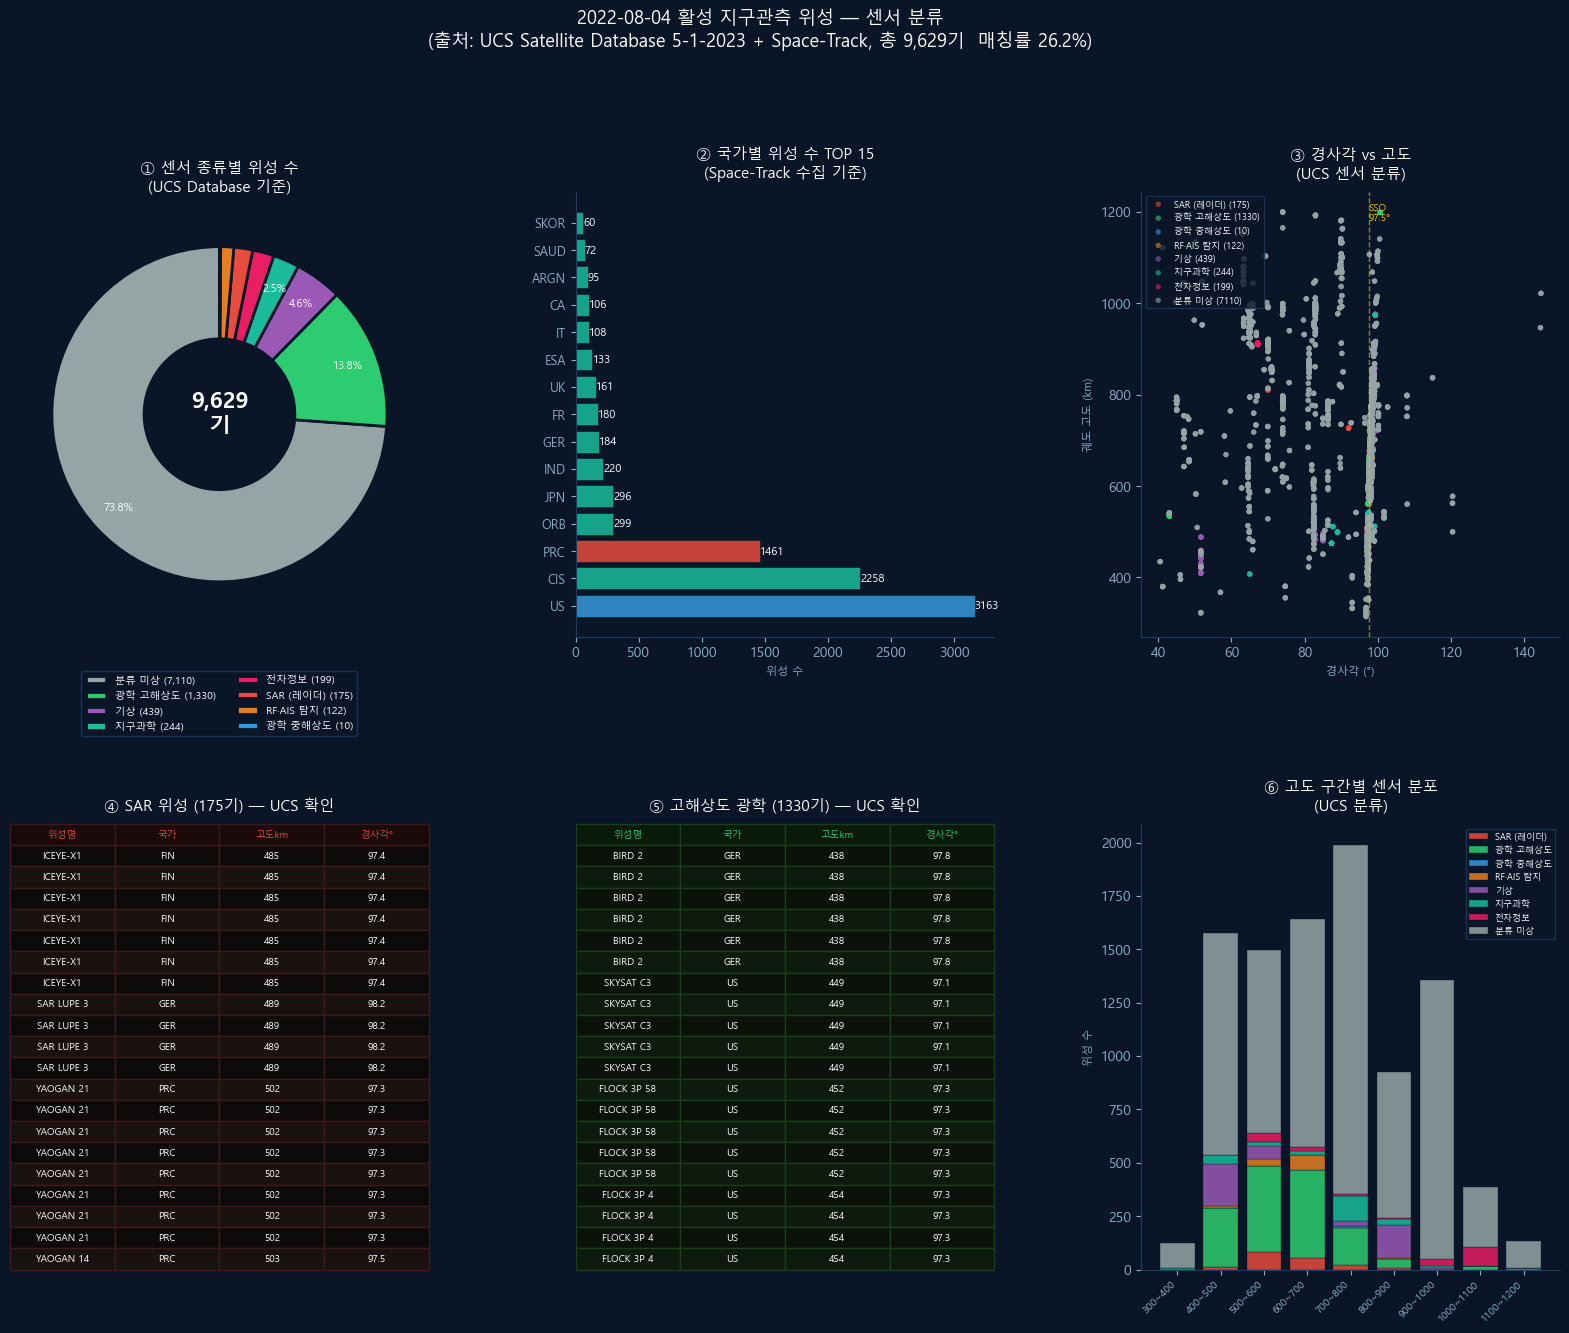

→ eo_satellite_ucs_classification.png 저장 완료


In [19]:
"""
Step 3 (UCS 버전) — UCS Satellite Database 기반 센서 분류 및 시각화
NORAD ID로 Space-Track 데이터와 조인

사전 조건:
  - eo_satellites_20220804.csv (step1 결과)
  - UCS-Satellite-Database_5-1-2023.xlsx
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# Step 1 — UCS 데이터베이스 로드 + 정제
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("UCS Satellite Database 로드")
print("=" * 55)

UCS_PATH = "UCS-Satellite-Database 5-1-2023.xlsx"

ucs_raw = pd.read_excel(UCS_PATH)
print(f"  전체 위성: {len(ucs_raw):,}기")

# 필요 컬럼만 추출
ucs = ucs_raw[[
    "NORAD Number",
    "Name of Satellite, Alternate Names",
    "Country of Operator/Owner",
    "Purpose",
    "Detailed Purpose",
    "Class of Orbit",
    "Type of Orbit",
    "Perigee (km)",
    "Apogee (km)",
    "Inclination (degrees)",
]].copy()

ucs.columns = [
    "norad_id", "sat_name", "country", "purpose",
    "detailed_purpose", "orbit_class", "orbit_type",
    "perigee_km", "apogee_km", "inclination"
]

# NORAD ID 정수 변환
ucs["norad_id"] = pd.to_numeric(ucs["norad_id"], errors="coerce")
ucs = ucs.dropna(subset=["norad_id"]).copy()
ucs["norad_id"] = ucs["norad_id"].astype(int)

print(f"  NORAD ID 유효: {len(ucs):,}기")
print(f"  지구관측 위성: {(ucs['purpose']=='Earth Observation').sum():,}기")

# ── Detailed Purpose → 센서 종류 매핑 ───────────────────────────
SENSOR_MAP = {
    "Radar Imaging":              "SAR",
    "Radar Imaging (SAR)":        "SAR",
    "Radar Imaging/Earth Science":"SAR",
    "SAR":                        "SAR",
    "Optical Imaging":            "OPT_HR",
    "Multispectral Imaging":      "OPT_MR",
    "Hyperspectral Imaging":      "OPT_HR",
    "Infrared Imaging":           "OPT_HR",
    "Video Imaging":              "OPT_HR",
    "Optical Imaging/Meterology": "OPT_MR",
    "Meteorology":                "MET",
    "Meteoology":                 "MET",
    "Meterology":                 "MET",
    "Meteoology/Earth Science":   "MET",
    "Meteorology/Earth Science":  "MET",
    "Earth Science/Meterology":   "MET",
    "Earth Science":              "SCI",
    "Automatic Identification System (AIS)": "RF",
    "Meteoology, Automatic Identification System (AIS)": "RF",
    "Meteorology, Automatic Identification System (AIS)": "RF",
    "Radio Frequency Monitoring": "RF",
    "Radio Spectrum Monitoring":  "RF",
    "Electronic Intelligence":    "ELINT",
    "Maritime Surveillance":      "SURV",
    "Early Warning":              "EW",
}

SENSOR_KR = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "RF":     "RF·AIS 탐지",
    "MET":    "기상",
    "SCI":    "지구과학",
    "ELINT":  "전자정보",
    "SURV":   "해양감시",
    "EW":     "조기경보",
    "UNK":    "분류 미상",
}

SENSOR_CLR = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "RF":     "#E67E22",
    "MET":    "#9B59B6",
    "SCI":    "#1ABC9C",
    "ELINT":  "#E91E63",
    "SURV":   "#607D8B",
    "EW":     "#FF5722",
    "UNK":    "#95A5A6",
}

def map_sensor(detailed):
    if pd.isna(detailed):
        return "UNK"
    for key, sensor in SENSOR_MAP.items():
        if key.lower() in str(detailed).lower():
            return sensor
    return "UNK"

ucs["sensor"] = ucs["detailed_purpose"].apply(map_sensor)

# ════════════════════════════════════════════════════════════════
# Step 2 — Space-Track 데이터와 조인
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("Space-Track 데이터와 NORAD ID 조인")
print("=" * 55)

eo_df = pd.read_csv("eo_satellites_20220804.csv")
print(f"  Space-Track 지구관측 위성: {len(eo_df):,}기")

# NORAD ID 조인
merged = eo_df.merge(
    ucs[["norad_id","sat_name","purpose","detailed_purpose",
         "orbit_type","sensor"]],
    on="norad_id",
    how="left"
)

# 조인 안 된 위성은 UNK
merged["sensor"]           = merged["sensor"].fillna("UNK")
merged["purpose"]          = merged["purpose"].fillna("Unknown")
merged["detailed_purpose"] = merged["detailed_purpose"].fillna("Unknown")

matched   = merged["sensor"].ne("UNK").sum()
unmatched = merged["sensor"].eq("UNK").sum()

print(f"  UCS 매칭 성공: {matched:,}기 ({matched/len(merged)*100:.1f}%)")
print(f"  UCS 매칭 실패: {unmatched:,}기 ({unmatched/len(merged)*100:.1f}%)")

# ── 결과 출력 ────────────────────────────────────────────────────
print(f"\n[센서 종류별 위성 수 — UCS 기준]")
sensor_cnt = merged["sensor"].value_counts()
for sensor, cnt in sensor_cnt.items():
    kr  = SENSOR_KR.get(sensor, sensor)
    pct = cnt / len(merged) * 100
    print(f"  {kr:<16} ({sensor:<6}): {cnt:>5,}기  {pct:.1f}%")

print(f"\n[SAR 위성 목록]")
sar = merged[merged["sensor"]=="SAR"][
    ["name","norad_id","country","altitude_km","inclination","detailed_purpose"]
].sort_values("altitude_km")
print(sar.to_string(index=False))

print(f"\n[고해상도 광학 위성 (상위 20개)]")
hr = merged[merged["sensor"]=="OPT_HR"][
    ["name","norad_id","country","altitude_km","inclination","detailed_purpose"]
].sort_values("altitude_km").head(20)
print(hr.to_string(index=False))

# CSV 저장
merged.to_csv("eo_satellites_ucs_classified_20220804.csv",
              index=False, encoding="utf-8-sig")
print(f"\n→ eo_satellites_ucs_classified_20220804.csv 저장 완료")

# ════════════════════════════════════════════════════════════════
# Step 3 — 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.35)

# ── Chart 1: 센서별 도넛 차트 ────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

labels  = [SENSOR_KR.get(s, s) for s in sensor_cnt.index]
sizes   = sensor_cnt.values
colors  = [SENSOR_CLR.get(s, "#888") for s in sensor_cnt.index]

wedges, _, autotexts = ax1.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2.5 else "",
    pctdistance=0.82,
    wedgeprops={"width": 0.55,
                "edgecolor": "#0A1628", "linewidth": 2},
    startangle=90
)
for at in autotexts:
    at.set_fontsize(8)
    at.set_color("white")

ax1.text(0, 0, f"{len(merged):,}\n기",
         ha="center", va="center",
         fontsize=16, fontweight="bold", color="white")

ax1.legend(
    wedges, [f"{l} ({v:,})" for l, v in zip(labels, sizes)],
    loc="lower center", bbox_to_anchor=(0.5, -0.28),
    ncol=2, fontsize=7.5,
    labelcolor="white",
    facecolor="#0A1628",
    edgecolor="#1E3A5F",
    framealpha=0.8
)
ax1.set_title("① 센서 종류별 위성 수\n(UCS Database 기준)",
              color="white", fontsize=11, pad=10)

# ── Chart 2: 국가별 위성 수 ──────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")

country_cnt = merged["country"].value_counts().head(15)
bar_colors  = [
    "#E74C3C" if c in ["PRC","China","CHN"] else
    "#3498DB" if c in ["US","USA"] else
    "#2ECC71" if c in ["KOR","South Korea"] else
    "#E67E22" if c in ["RUS","Russia"] else
    "#9B59B6" if c in ["EU","France","Germany"] else
    "#1ABC9C"
    for c in country_cnt.index
]
bars = ax2.barh(range(len(country_cnt)), country_cnt.values,
                color=bar_colors, alpha=0.85,
                edgecolor="#0A1628", linewidth=0.5)
ax2.set_yticks(range(len(country_cnt)))
ax2.set_yticklabels(country_cnt.index, color="white", fontsize=9)
ax2.set_xlabel("위성 수", color="#8BAFC8", fontsize=8)
ax2.set_title("② 국가별 위성 수 TOP 15\n(Space-Track 수집 기준)",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="#8BAFC8")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")
for bar, val in zip(bars, country_cnt.values):
    ax2.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va="center", fontsize=8, color="white")

# ── Chart 3: 경사각 vs 고도 산점도 ──────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")

for sensor in ["SAR","OPT_HR","OPT_MR","RF","MET","SCI","ELINT","UNK"]:
    sub = merged[merged["sensor"] == sensor]
    if sub.empty:
        continue
    ax3.scatter(sub["inclination"], sub["altitude_km"],
                s=15, c=SENSOR_CLR.get(sensor,"#888"),
                alpha=0.6,
                label=f"{SENSOR_KR.get(sensor,sensor)} ({len(sub)})",
                edgecolors="none")

ax3.axvline(97.5, color="#F1C40F", linewidth=1,
            linestyle="--", alpha=0.6)
ax3.text(97.5, 1180, "SSO\n97.5°",
         color="#F1C40F", fontsize=7, ha="left")
ax3.set_xlabel("경사각 (°)", color="#8BAFC8", fontsize=8)
ax3.set_ylabel("궤도 고도 (km)", color="#8BAFC8", fontsize=8)
ax3.set_title("③ 경사각 vs 고도\n(UCS 센서 분류)",
              color="white", fontsize=11, pad=10)
ax3.tick_params(colors="#8BAFC8")
ax3.legend(fontsize=6.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper left")
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 4: SAR 위성 표 ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628")
ax4.axis("off")

sar_show = merged[merged["sensor"]=="SAR"].sort_values(
    "altitude_km").head(20)
ax4.set_title(f"④ SAR 위성 ({len(merged[merged['sensor']=='SAR'])}기) — UCS 확인",
              color="white", fontsize=11, pad=10)
if not sar_show.empty:
    tbl_data = [
        [str(r["name"])[:22],
         str(r["country"])[:4],
         f"{r['altitude_km']:.0f}",
         f"{r['inclination']:.1f}"]
        for _, r in sar_show.iterrows()
    ]
    tbl = ax4.table(
        cellText=tbl_data,
        colLabels=["위성명","국가","고도km","경사각°"],
        cellLoc="center", loc="center",
        bbox=[0, 0, 1, 1]
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(7)
    for (r, c), cell in tbl.get_celld().items():
        cell.set_facecolor(
            "#1A0A0A" if r == 0 else
            "#1A1210" if r % 2 == 0 else "#0D0A0A"
        )
        cell.set_text_props(
            color="#E74C3C" if r == 0 else "white")
        cell.set_edgecolor("#3D1A1A")

# ── Chart 5: 고해상도 광학 위성 표 ──────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628")
ax5.axis("off")

hr_show = merged[merged["sensor"]=="OPT_HR"].sort_values(
    "altitude_km").head(20)
ax5.set_title(
    f"⑤ 고해상도 광학 ({len(merged[merged['sensor']=='OPT_HR'])}기) — UCS 확인",
    color="white", fontsize=11, pad=10)
if not hr_show.empty:
    tbl_data2 = [
        [str(r["name"])[:22],
         str(r["country"])[:4],
         f"{r['altitude_km']:.0f}",
         f"{r['inclination']:.1f}"]
        for _, r in hr_show.iterrows()
    ]
    tbl2 = ax5.table(
        cellText=tbl_data2,
        colLabels=["위성명","국가","고도km","경사각°"],
        cellLoc="center", loc="center",
        bbox=[0, 0, 1, 1]
    )
    tbl2.auto_set_font_size(False)
    tbl2.set_fontsize(7)
    for (r, c), cell in tbl2.get_celld().items():
        cell.set_facecolor(
            "#0A1A0A" if r == 0 else
            "#0D1A0D" if r % 2 == 0 else "#0A120A"
        )
        cell.set_text_props(
            color="#2ECC71" if r == 0 else "white")
        cell.set_edgecolor("#1A3D1A")

# ── Chart 6: 고도 구간별 센서 누적 막대 ─────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

bins        = [300,400,500,600,700,800,900,1000,1100,1200]
labels_bin  = [f"{b}~{bins[i+1]}" for i, b in enumerate(bins[:-1])]
sensor_order= ["SAR","OPT_HR","OPT_MR","RF","MET","SCI","ELINT","UNK"]

bottom = np.zeros(len(bins)-1)
for sensor in sensor_order:
    sub    = merged[merged["sensor"] == sensor]
    counts = pd.cut(sub["altitude_km"], bins=bins
                    ).value_counts().reindex(
        pd.IntervalIndex.from_breaks(bins), fill_value=0)
    color  = SENSOR_CLR.get(sensor, "#888")
    ax6.bar(range(len(bins)-1), counts.values,
            bottom=bottom, color=color, alpha=0.85,
            label=SENSOR_KR.get(sensor, sensor),
            edgecolor="#0A1628", linewidth=0.3)
    bottom += counts.values

ax6.set_xticks(range(len(labels_bin)))
ax6.set_xticklabels(labels_bin, rotation=45, ha="right",
                    fontsize=7.5, color="#8BAFC8")
ax6.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 고도 구간별 센서 분포\n(UCS 분류)",
              color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=6.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper right")
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

fig.suptitle(
    "2022-08-04 활성 지구관측 위성 — 센서 분류\n"
    f"(출처: UCS Satellite Database 5-1-2023 + Space-Track, "
    f"총 {len(merged):,}기  매칭률 {matched/len(merged)*100:.1f}%)",
    fontsize=13, color="white", y=1.01
)

plt.savefig("eo_satellite_ucs_classification.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0A1628")
plt.show()
print("→ eo_satellite_ucs_classification.png 저장 완료")

### UNK 위성 키워드 보완 분류

UNK 키워드 보완 분류 결과
  보완 전 UNK: 7,110기
  보완 후 UNK: 4,355기
  추가 분류:   2,755기

[분류 출처별 통계]
  미분류         : 4,355기 (45.2%)
  키워드 추정      : 2,755기 (28.6%)
  UCS 공식      : 2,519기 (26.2%)

[센서 종류별 — 출처 구분]
센서                    UCS    KEYWORD      UNK       합계
----------------------------------------------------
  분류 미상                 0          0    4,355    4,355
  SAR (레이더)           175      1,699        0    1,874
  광학 고해상도           1,330         27        0    1,357
  기상                  439        311        0      750
  광학 초소형                0        549        0      549
  전자정보                199         94        0      293
  지구과학                244          0        0      244
  RF·AIS 탐지           122          5        0      127
  광학 중해상도              10         65        0       75
  해양                    0          5        0        5

→ eo_satellites_full_classified_20220804.csv 저장 완료


C:\Users\user\AppData\Local\Temp\ipykernel_134700\3808939604.py:517: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig("eo_satellite_full_classification.png",
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


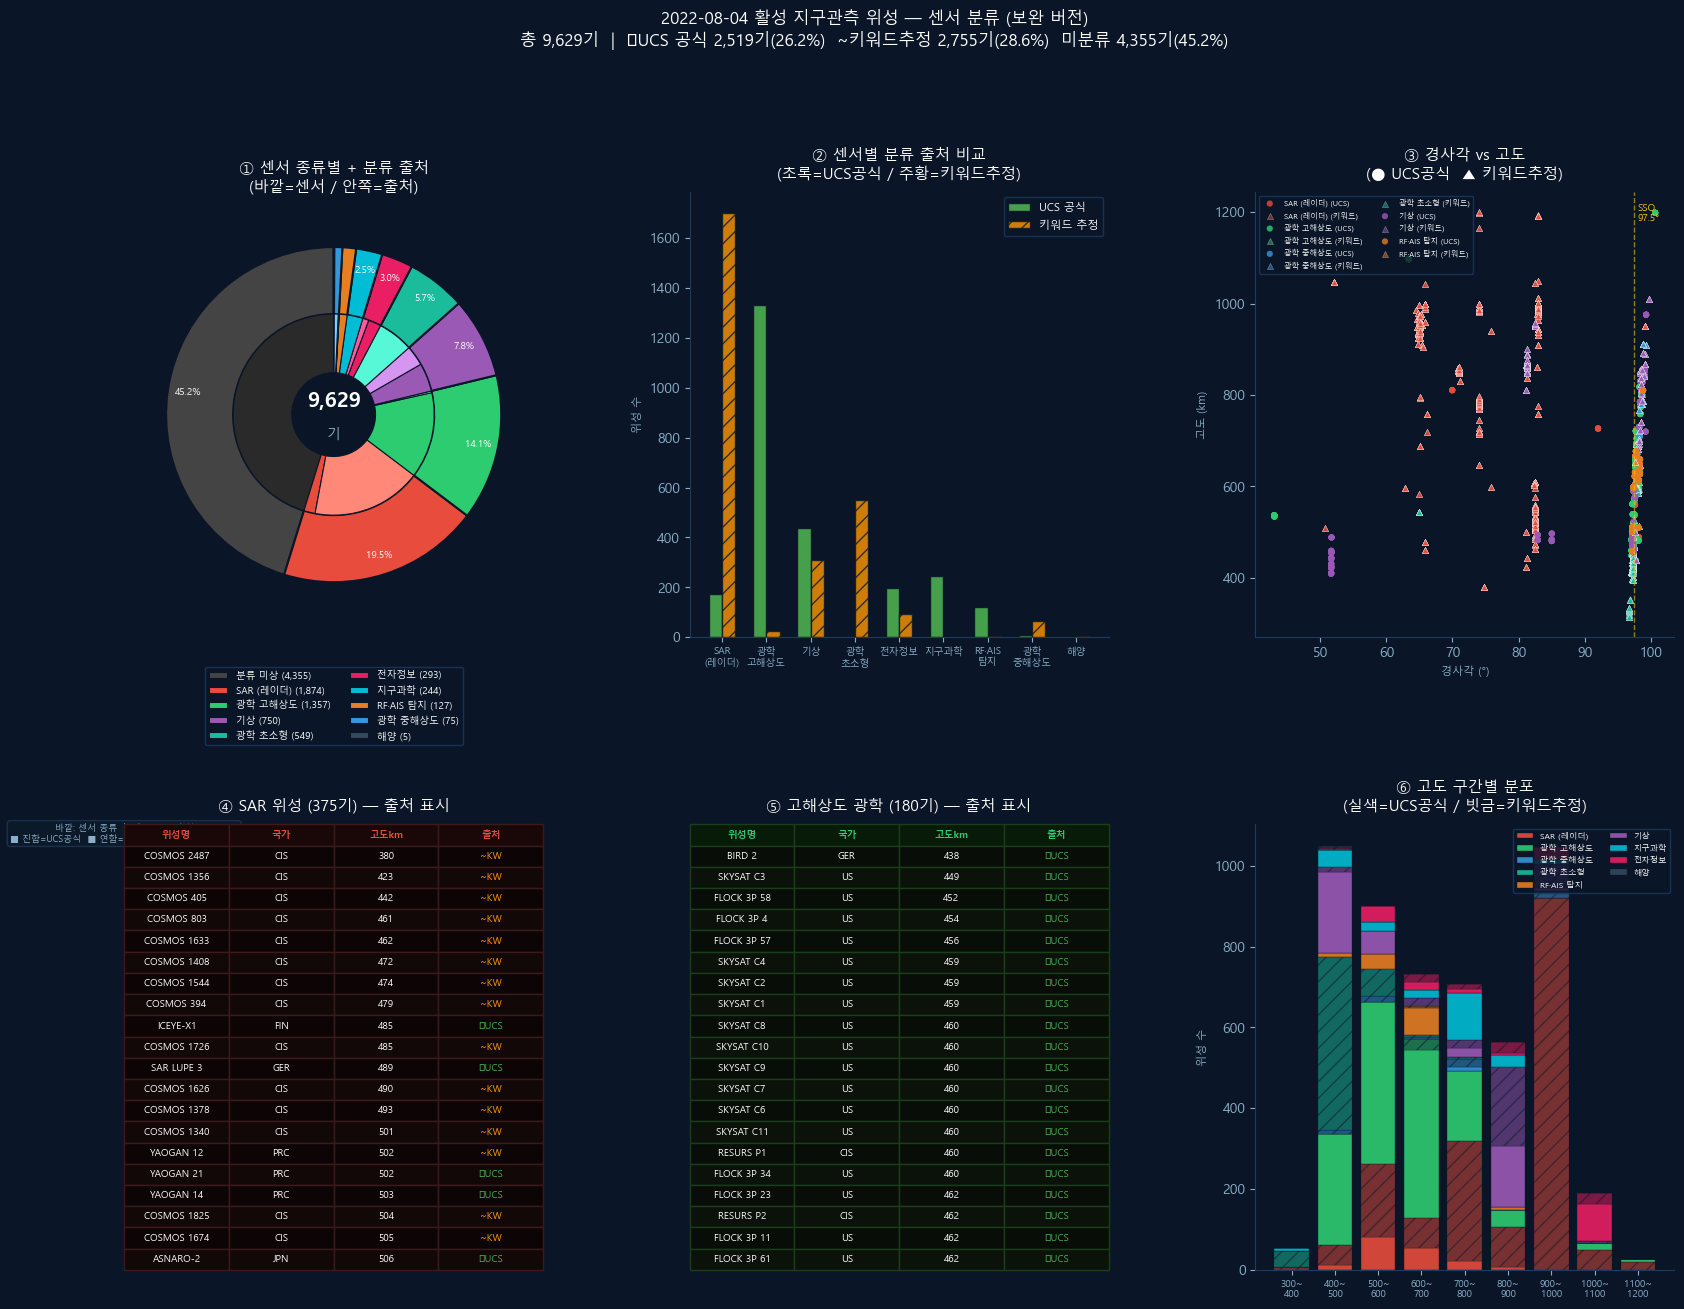

→ eo_satellite_full_classification.png 저장 완료


In [20]:
"""
Step 3-2 — UNK 위성 키워드 보완 분류
분류 출처: UCS(공식) vs KEYWORD(키워드 추정) 구분 표시

사전 조건: step3_classify_ucs.py 실행 후 merged DataFrame 존재
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# 키워드 보완 분류 사전
# ════════════════════════════════════════════════════════════════
KEYWORD_CLASSIFY = [
    # ── SAR ──────────────────────────────────────────────────────
    ("SENTINEL-1",    "SAR"),
    ("ICEYE",         "SAR"),
    ("UMBRA",         "SAR"),
    ("CAPELLA",       "SAR"),
    ("COSMO",         "SAR"),
    ("TERRASAR",      "SAR"),
    ("TANDEM",        "SAR"),
    ("RADARSAT",      "SAR"),
    ("ALOS",          "SAR"),
    ("PAZ",           "SAR"),
    ("KOMPSAT-5",     "SAR"),
    ("SAR LUPE",      "SAR"),
    ("YAOGAN-35",     "SAR"),
    ("YAOGAN-36",     "SAR"),
    ("YAOGAN",        "SAR"),   # 야오간 시리즈 전체
    ("HISEA",         "SAR"),
    ("GAOFEN-3",      "SAR"),
    ("LT-1",          "SAR"),
    ("LTAN",          "SAR"),
    # ── 고해상도 광학 ─────────────────────────────────────────────
    ("WORLDVIEW",     "OPT_HR"),
    ("GEOEYE",        "OPT_HR"),
    ("PLEIADES",      "OPT_HR"),
    ("SPOT-6",        "OPT_HR"),
    ("SPOT-7",        "OPT_HR"),
    ("KOMPSAT-3",     "OPT_HR"),
    ("KOMPSAT-2",     "OPT_HR"),
    ("GAOFEN-2",      "OPT_HR"),
    ("GAOFEN-7",      "OPT_HR"),
    ("GAOFEN-12",     "OPT_HR"),
    ("GAOFEN-13",     "OPT_HR"),
    ("GAOFEN-14",     "OPT_HR"),
    ("SUPERVIEW",     "OPT_HR"),
    ("JILIN",         "OPT_HR"),
    ("SKYSAT",        "OPT_HR"),
    ("TRIPLESAT",     "OPT_HR"),
    ("FORMOSAT",      "OPT_HR"),
    ("ALSAT",         "OPT_HR"),
    ("KAZEOSAT",      "OPT_HR"),
    ("DUBAISAT",      "OPT_HR"),
    ("BEIJING",       "OPT_HR"),
    ("ZIYUAN-3",      "OPT_HR"),
    ("CARTOSAT",      "OPT_HR"),
    ("IKONOS",        "OPT_HR"),
    ("QUICKBIRD",     "OPT_HR"),
    # ── 중해상도 광학 ─────────────────────────────────────────────
    ("SENTINEL-2",    "OPT_MR"),
    ("LANDSAT",       "OPT_MR"),
    ("RESOURCESAT",   "OPT_MR"),
    ("TERRA",         "OPT_MR"),
    ("AQUA",          "OPT_MR"),
    ("SUOMI",         "OPT_MR"),
    ("PROBA",         "OPT_MR"),
    ("GAOFEN-1",      "OPT_MR"),
    ("GAOFEN-4",      "OPT_MR"),
    ("GAOFEN-6",      "OPT_MR"),
    ("HJ-",           "OPT_MR"),
    ("CBERS",         "OPT_MR"),
    ("ZIYUAN-1",      "OPT_MR"),
    # ── 초소형 광학 ───────────────────────────────────────────────
    ("DOVE",          "OPT_SM"),
    ("FLOCK",         "OPT_SM"),
    ("NUSAT",         "OPT_SM"),
    ("PLANET",        "OPT_SM"),
    # ── 기상 ─────────────────────────────────────────────────────
    ("NOAA",          "MET"),
    ("METOP",         "MET"),
    ("METEOR",        "MET"),
    ("FENGYUN",       "MET"),
    ("FY-",           "MET"),
    ("HIMAWARI",      "MET"),
    ("COMS",          "MET"),
    ("COSMIC",        "MET"),
    ("GOES",          "MET"),
    # ── RF·AIS ───────────────────────────────────────────────────
    ("HAWK",          "RF"),
    ("SLINGSHOT",     "RF"),
    ("LEMUR",         "RF"),
    # ── 전자정보 ─────────────────────────────────────────────────
    ("USA ",          "ELINT"),   # NRO 위성
    # ── 해양 ─────────────────────────────────────────────────────
    ("JASON",         "OCN"),
    ("CRYOSAT",       "OCN"),
    ("ICESAT",        "OCN"),
    ("SWOT",          "OCN"),
]

SENSOR_KR = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "OPT_SM": "광학 초소형",
    "RF":     "RF·AIS 탐지",
    "MET":    "기상",
    "SCI":    "지구과학",
    "ELINT":  "전자정보",
    "SURV":   "해양감시",
    "EW":     "조기경보",
    "OCN":    "해양",
    "UNK":    "분류 미상",
}
SENSOR_CLR = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "OPT_SM": "#1ABC9C",
    "RF":     "#E67E22",
    "MET":    "#9B59B6",
    "SCI":    "#00BCD4",
    "ELINT":  "#E91E63",
    "SURV":   "#607D8B",
    "EW":     "#FF5722",
    "OCN":    "#34495E",
    "UNK":    "#444444",
}

# ════════════════════════════════════════════════════════════════
# UNK 보완 분류 적용
# ════════════════════════════════════════════════════════════════
df = merged.copy()

# 분류 출처 컬럼 초기화
# UCS: UCS 데이터베이스 매칭
# KEYWORD: 키워드 추정
# UNK: 미분류
df["source"] = df["sensor"].apply(
    lambda s: "UCS" if s != "UNK" else "UNK"
)

# 키워드 보완 분류
n_before = (df["sensor"] == "UNK").sum()

for keyword, sensor in KEYWORD_CLASSIFY:
    mask = (
        (df["sensor"] == "UNK") &
        (df["name"].str.upper().str.contains(keyword.upper(), na=False))
    )
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "KEYWORD"

n_after  = (df["sensor"] == "UNK").sum()
n_filled = n_before - n_after

print("=" * 55)
print("UNK 키워드 보완 분류 결과")
print("=" * 55)
print(f"  보완 전 UNK: {n_before:,}기")
print(f"  보완 후 UNK: {n_after:,}기")
print(f"  추가 분류:   {n_filled:,}기")

# ── 분류 출처별 통계 ─────────────────────────────────────────────
print(f"\n[분류 출처별 통계]")
src_cnt = df["source"].value_counts()
for src, cnt in src_cnt.items():
    label = {"UCS":"UCS 공식","KEYWORD":"키워드 추정","UNK":"미분류"}.get(src, src)
    print(f"  {label:<12}: {cnt:,}기 ({cnt/len(df)*100:.1f}%)")

print(f"\n[센서 종류별 — 출처 구분]")
print(f"{'센서':<16} {'UCS':>8} {'KEYWORD':>10} {'UNK':>8} {'합계':>8}")
print("-" * 52)
for sensor in df["sensor"].value_counts().index:
    ucs_cnt = ((df["sensor"]==sensor) & (df["source"]=="UCS")).sum()
    kw_cnt  = ((df["sensor"]==sensor) & (df["source"]=="KEYWORD")).sum()
    unk_cnt = ((df["sensor"]==sensor) & (df["source"]=="UNK")).sum()
    total   = ucs_cnt + kw_cnt + unk_cnt
    kr      = SENSOR_KR.get(sensor, sensor)
    print(f"  {kr:<14} {ucs_cnt:>8,} {kw_cnt:>10,} {unk_cnt:>8,} {total:>8,}")

# 저장
df.to_csv("eo_satellites_full_classified_20220804.csv",
          index=False, encoding="utf-8-sig")
print(f"\n→ eo_satellites_full_classified_20220804.csv 저장 완료")

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.35)

sensor_cnt = df["sensor"].value_counts()

# ── Chart 1: 센서별 도넛 — 출처 구분 색상 ───────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

# 바깥 링: 센서 종류
outer_labels = [SENSOR_KR.get(s, s) for s in sensor_cnt.index]
outer_sizes  = sensor_cnt.values
outer_colors = [SENSOR_CLR.get(s, "#888") for s in sensor_cnt.index]

# 안쪽 링: 출처 (UCS / KEYWORD / UNK)
src_by_sensor = []
src_colors_in = []
for sensor in sensor_cnt.index:
    ucs_n = ((df["sensor"]==sensor) & (df["source"]=="UCS")).sum()
    kw_n  = ((df["sensor"]==sensor) & (df["source"]=="KEYWORD")).sum()
    unk_n = ((df["sensor"]==sensor) & (df["source"]=="UNK")).sum()
    base  = SENSOR_CLR.get(sensor, "#888")
    if ucs_n > 0:
        src_by_sensor.append(ucs_n)
        src_colors_in.append(base)
    if kw_n > 0:
        src_by_sensor.append(kw_n)
        # 키워드 분류는 색상 연하게
        r = int(base[1:3], 16)
        g = int(base[3:5], 16)
        b = int(base[5:7], 16)
        lighter = f"#{min(r+60,255):02X}{min(g+60,255):02X}{min(b+60,255):02X}"
        src_colors_in.append(lighter)
    if unk_n > 0:
        src_by_sensor.append(unk_n)
        src_colors_in.append("#2A2A2A")

# 바깥 도넛
wedges_out, _, autotexts = ax1.pie(
    outer_sizes, labels=None, colors=outer_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.88,
    wedgeprops={"width": 0.4, "edgecolor": "#0A1628", "linewidth": 1.5},
    startangle=90, radius=1.0
)
for at in autotexts:
    at.set_fontsize(7)
    at.set_color("white")

# 안쪽 도넛 (출처)
ax1.pie(
    src_by_sensor, colors=src_colors_in,
    wedgeprops={"width": 0.35, "edgecolor": "#0A1628", "linewidth": 0.8},
    startangle=90, radius=0.6
)

# 중앙
ax1.text(0, 0.08, f"{len(df):,}",
         ha="center", va="center",
         fontsize=15, fontweight="bold", color="white")
ax1.text(0, -0.12, "기",
         ha="center", va="center",
         fontsize=10, color="#8BAFC8")

# 범례
ax1.legend(
    wedges_out,
    [f"{l} ({v:,})" for l, v in zip(outer_labels, outer_sizes)],
    loc="lower center", bbox_to_anchor=(0.5, -0.30),
    ncol=2, fontsize=7,
    labelcolor="white",
    facecolor="#0A1628",
    edgecolor="#1E3A5F",
    framealpha=0.8
)
# 출처 설명
ax1.text(0, -0.5,
         "바깥: 센서 종류  |  안쪽: 분류 출처\n"
         "■ 진함=UCS공식  ■ 연함=키워드추정  ■ 회색=미분류",
         ha="center", va="center",
         fontsize=6.5, color="#8BAFC8",
         transform=ax1.transAxes,
         bbox=dict(facecolor="#0D1B2A", alpha=0.7,
                   edgecolor="#1E3A5F", boxstyle="round,pad=0.3"))

ax1.set_title("① 센서 종류별 + 분류 출처\n(바깥=센서 / 안쪽=출처)",
              color="white", fontsize=11, pad=10)

# ── Chart 2: 분류 출처별 막대 ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")

sensors_ordered = [s for s in sensor_cnt.index if s != "UNK"]
x      = np.arange(len(sensors_ordered))
w      = 0.3
ucs_v  = [((df["sensor"]==s)&(df["source"]=="UCS")).sum()
           for s in sensors_ordered]
kw_v   = [((df["sensor"]==s)&(df["source"]=="KEYWORD")).sum()
           for s in sensors_ordered]

bars1 = ax2.bar(x - w/2, ucs_v, w, label="UCS 공식",
                color="#4CAF50", alpha=0.9, edgecolor="#0A1628")
bars2 = ax2.bar(x + w/2, kw_v,  w, label="키워드 추정",
                color="#FF9800", alpha=0.8, edgecolor="#0A1628",
                hatch="//")

ax2.set_xticks(x)
ax2.set_xticklabels(
    [SENSOR_KR.get(s, s).replace(" ","\n") for s in sensors_ordered],
    fontsize=7, color="white"
)
ax2.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax2.set_title("② 센서별 분류 출처 비교\n(초록=UCS공식 / 주황=키워드추정)",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="#8BAFC8")
ax2.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 3: 경사각 vs 고도 — 출처 구분 마커 ────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")

for sensor in ["SAR","OPT_HR","OPT_MR","OPT_SM","MET","RF"]:
    # UCS 공식
    sub_ucs = df[(df["sensor"]==sensor) & (df["source"]=="UCS")]
    if not sub_ucs.empty:
        ax3.scatter(sub_ucs["inclination"], sub_ucs["altitude_km"],
                    s=20, c=SENSOR_CLR.get(sensor,"#888"),
                    alpha=0.8, marker="o", edgecolors="none",
                    label=f"{SENSOR_KR.get(sensor,sensor)} (UCS)")
    # 키워드 추정
    sub_kw = df[(df["sensor"]==sensor) & (df["source"]=="KEYWORD")]
    if not sub_kw.empty:
        ax3.scatter(sub_kw["inclination"], sub_kw["altitude_km"],
                    s=20, c=SENSOR_CLR.get(sensor,"#888"),
                    alpha=0.5, marker="^", edgecolors="white",
                    linewidth=0.3,
                    label=f"{SENSOR_KR.get(sensor,sensor)} (키워드)")

ax3.axvline(97.5, color="#F1C40F", linewidth=1,
            linestyle="--", alpha=0.6)
ax3.text(98, 1180, "SSO\n97.5°", color="#F1C40F", fontsize=7)
ax3.set_xlabel("경사각 (°)", color="#8BAFC8", fontsize=8)
ax3.set_ylabel("고도 (km)", color="#8BAFC8", fontsize=8)
ax3.set_title("③ 경사각 vs 고도\n(● UCS공식  ▲ 키워드추정)",
              color="white", fontsize=11, pad=10)
ax3.tick_params(colors="#8BAFC8")
ax3.legend(fontsize=5.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper left", ncol=2)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 4: SAR 위성 — 출처 표시 표 ────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628")
ax4.axis("off")

sar_df = df[df["sensor"]=="SAR"].sort_values(
    "altitude_km").drop_duplicates("norad_id").head(20)
n_sar_total = df[df["sensor"]=="SAR"]["norad_id"].nunique()
ax4.set_title(f"④ SAR 위성 ({n_sar_total}기) — 출처 표시",
              color="white", fontsize=11, pad=10)

tbl_data = [
    [str(r["name"])[:20],
     str(r["country"])[:4],
     f"{r['altitude_km']:.0f}",
     "✓UCS" if r["source"]=="UCS" else "~KW"]
    for _, r in sar_df.iterrows()
]
tbl = ax4.table(
    cellText=tbl_data,
    colLabels=["위성명","국가","고도km","출처"],
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1A0808")
        cell.set_text_props(color="#E74C3C", fontweight="bold")
    else:
        row_data = tbl_data[r-1]
        is_ucs   = row_data[3] == "✓UCS"
        cell.set_facecolor("#120808" if r%2==0 else "#0D0505")
        if c == 3:
            cell.set_text_props(
                color="#4CAF50" if is_ucs else "#FF9800")
        else:
            cell.set_text_props(color="white")
    cell.set_edgecolor("#3D1A1A")

# ── Chart 5: OPT_HR 위성 — 출처 표시 표 ─────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628")
ax5.axis("off")

hr_df = df[df["sensor"]=="OPT_HR"].sort_values(
    "altitude_km").drop_duplicates("norad_id").head(20)
n_hr_total = df[df["sensor"]=="OPT_HR"]["norad_id"].nunique()
ax5.set_title(f"⑤ 고해상도 광학 ({n_hr_total}기) — 출처 표시",
              color="white", fontsize=11, pad=10)

tbl_data2 = [
    [str(r["name"])[:20],
     str(r["country"])[:4],
     f"{r['altitude_km']:.0f}",
     "✓UCS" if r["source"]=="UCS" else "~KW"]
    for _, r in hr_df.iterrows()
]
tbl2 = ax5.table(
    cellText=tbl_data2,
    colLabels=["위성명","국가","고도km","출처"],
    cellLoc="center", loc="center",
    bbox=[0, 0, 1, 1]
)
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(7)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#081A08")
        cell.set_text_props(color="#2ECC71", fontweight="bold")
    else:
        row_data = tbl_data2[r-1]
        is_ucs   = row_data[3] == "✓UCS"
        cell.set_facecolor("#0A120A" if r%2==0 else "#080D08")
        if c == 3:
            cell.set_text_props(
                color="#4CAF50" if is_ucs else "#FF9800")
        else:
            cell.set_text_props(color="white")
    cell.set_edgecolor("#1A3D1A")

# ── Chart 6: 고도 구간별 누적 막대 — 출처 구분 ───────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

bins       = [300,400,500,600,700,800,900,1000,1100,1200]
labels_bin = [f"{b}~\n{bins[i+1]}" for i, b in enumerate(bins[:-1])]
bottom_ucs = np.zeros(len(bins)-1)
bottom_kw  = np.zeros(len(bins)-1)

sensor_order = ["SAR","OPT_HR","OPT_MR","OPT_SM",
                "RF","MET","SCI","ELINT","OCN"]

for sensor in sensor_order:
    color = SENSOR_CLR.get(sensor, "#888")
    # UCS 공식 (실선)
    sub_u = df[(df["sensor"]==sensor) & (df["source"]=="UCS")]
    cnt_u = pd.cut(sub_u["altitude_km"], bins=bins
                   ).value_counts().reindex(
        pd.IntervalIndex.from_breaks(bins), fill_value=0).values
    ax6.bar(range(len(bins)-1), cnt_u,
            bottom=bottom_ucs, color=color, alpha=0.9,
            edgecolor="#0A1628", linewidth=0.3,
            label=f"{SENSOR_KR.get(sensor,sensor)}")
    bottom_ucs += cnt_u

    # 키워드 추정 (빗금)
    sub_k = df[(df["sensor"]==sensor) & (df["source"]=="KEYWORD")]
    cnt_k = pd.cut(sub_k["altitude_km"], bins=bins
                   ).value_counts().reindex(
        pd.IntervalIndex.from_breaks(bins), fill_value=0).values
    ax6.bar(range(len(bins)-1), cnt_k,
            bottom=bottom_ucs, color=color, alpha=0.5,
            edgecolor="#0A1628", linewidth=0.3, hatch="//")
    bottom_ucs += cnt_k

ax6.set_xticks(range(len(labels_bin)))
ax6.set_xticklabels(labels_bin, fontsize=7, color="#8BAFC8")
ax6.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 고도 구간별 분포\n(실색=UCS공식 / 빗금=키워드추정)",
              color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=6, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper right", ncol=2)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

# 전체 제목
ucs_total = (df["source"]=="UCS").sum()
kw_total  = (df["source"]=="KEYWORD").sum()
unk_total = (df["source"]=="UNK").sum()

fig.suptitle(
    f"2022-08-04 활성 지구관측 위성 — 센서 분류 (보완 버전)\n"
    f"총 {len(df):,}기  |  "
    f"✓UCS 공식 {ucs_total:,}기({ucs_total/len(df)*100:.1f}%)  "
    f"~키워드추정 {kw_total:,}기({kw_total/len(df)*100:.1f}%)  "
    f"미분류 {unk_total:,}기({unk_total/len(df)*100:.1f}%)",
    fontsize=12, color="white", y=1.01
)

plt.savefig("eo_satellite_full_classification.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0A1628")
plt.show()
print("→ eo_satellite_full_classification.png 저장 완료")

In [21]:
# source 컬럼 없으면 추가
if "source" not in merged.columns:
    merged["source"] = merged["sensor"].apply(
        lambda s: "UCS" if s != "UNK" else "UNK"
    )
    print(f"source 컬럼 추가 완료")
    print(merged["source"].value_counts())

source 컬럼 추가 완료
source
UNK    7110
UCS    2519
Name: count, dtype: int64


In [22]:
# source 컬럼 초기화 후 키워드 재분류 적용
import pandas as pd

# 1. source 컬럼 초기화
merged["source"] = merged["sensor"].apply(
    lambda s: "UCS" if s != "UNK" else "UNK"
)

# 2. 키워드 분류 재적용 (step3_classify_supplement의 KEYWORD_CLASSIFY 사전 필요)
# KEYWORD_CLASSIFY가 메모리에 없으면 step3_classify_supplement.py 먼저 실행

for keyword, sensor in KEYWORD_CLASSIFY:
    mask = (
        (merged["sensor"] == "UNK") &
        (merged["name"].str.upper().str.contains(keyword.upper(), na=False))
    )
    merged.loc[mask, "sensor"] = sensor
    merged.loc[mask, "source"] = "KEYWORD"

print(merged["source"].value_counts())

source
UNK        4355
KEYWORD    2755
UCS        2519
Name: count, dtype: int64


Step 1 — COSMOS 키워드 추정 재분류
  COSMOS 재분류: 1,646기 → UNK로 변경
  현재 UNK: 6,001기

Step 2 — Claude API 미분류 위성 분류
  분류 대상 고유 위성명: 1,169개
  배치 처리 시작 (30개씩)...
    API 오류: 'content'
  배치   1: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   2: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   3: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   4: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   5: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   6: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   7: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   8: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치   9: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  10: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  11: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  12: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  13: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  14: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  15: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  16: 30개 처리 → 0개 분류 완료
    API 오류: 'content'
  배치  17: 30개 처리 → 0개 분류 완료


C:\Users\user\AppData\Local\Temp\ipykernel_134700\723117476.py:424: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig("eo_satellite_final_classification.png",
C:\Users\user\AppData\Local\Temp\ipykernel_134700\723117476.py:424: UserWarning: Glyph 10022 (\N{BLACK FOUR POINTED STAR}) missing from font(s) Malgun Gothic.
  plt.savefig("eo_satellite_final_classification.png",
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10022 (\N{BLACK FOUR POINTED STAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


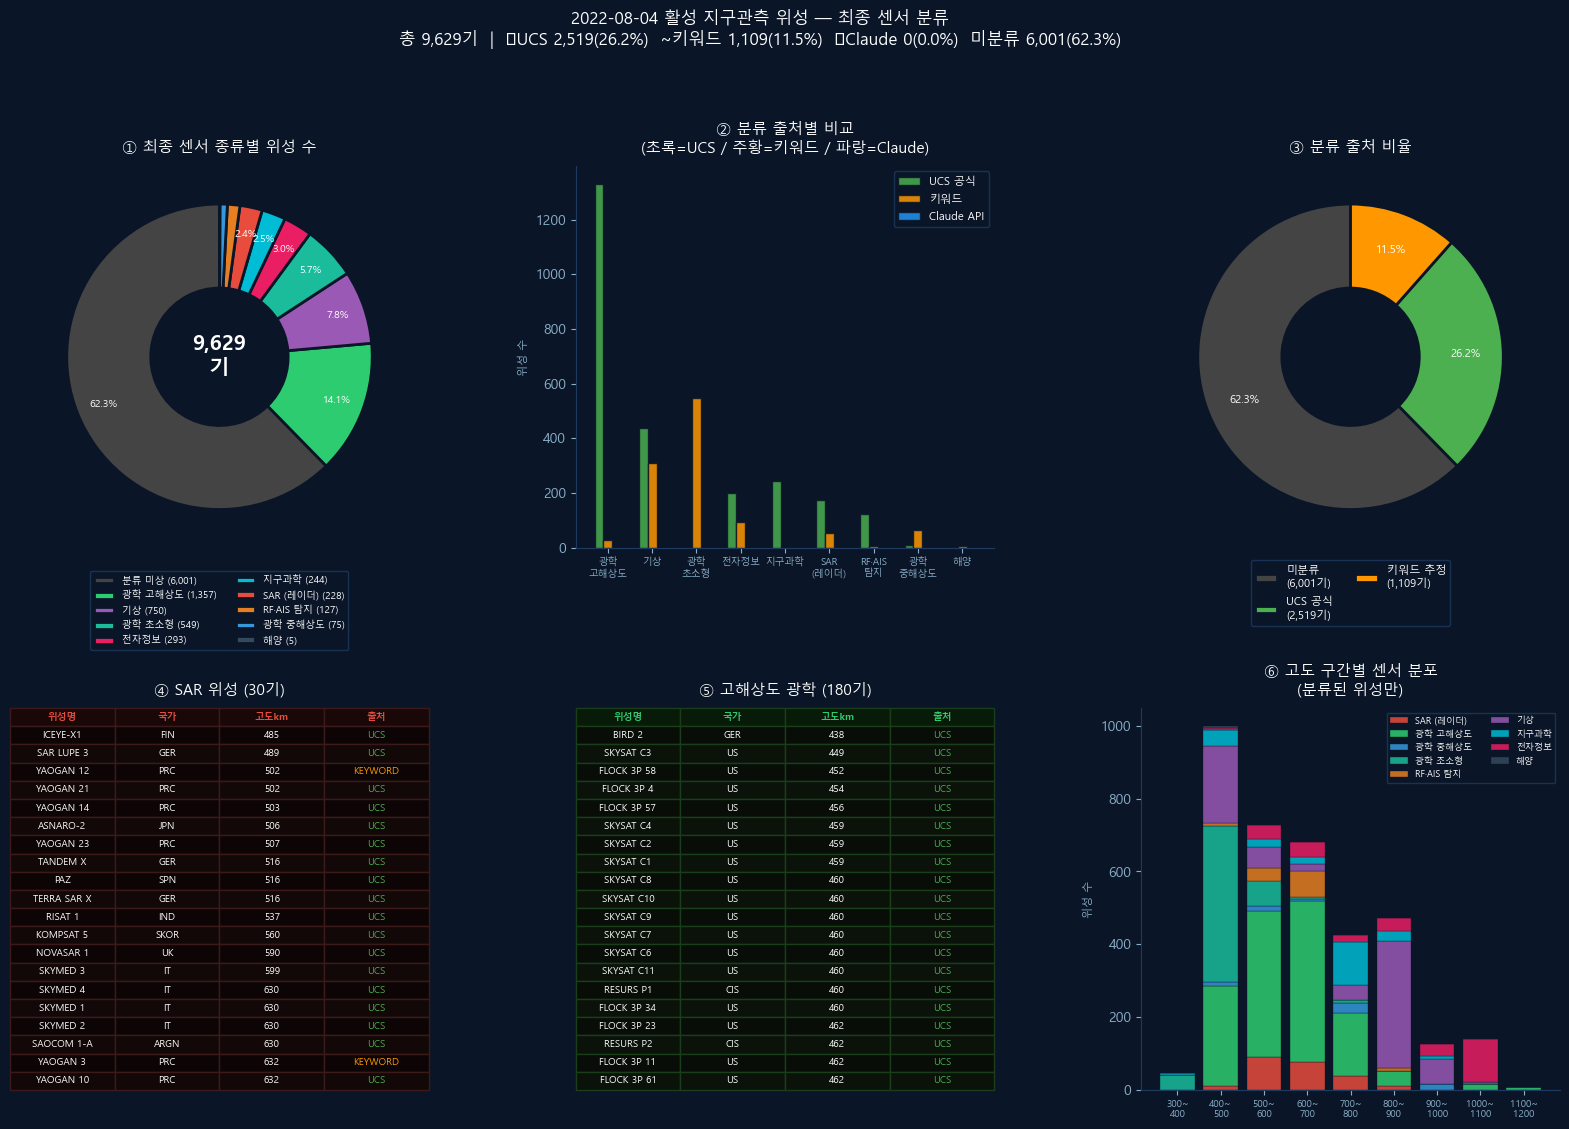

→ eo_satellite_final_classification.png 저장 완료


In [23]:
"""
Step 3-3 — COSMOS 재분류 + Claude API 미분류 위성 일괄 분류
"""

import json
import time
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

SENSOR_KR = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "OPT_SM": "광학 초소형",
    "RF":     "RF·AIS 탐지",
    "MET":    "기상",
    "SCI":    "지구과학",
    "ELINT":  "전자정보",
    "SURV":   "해양감시",
    "EW":     "조기경보",
    "OCN":    "해양",
    "UNK":    "분류 미상",
}
SENSOR_CLR = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "OPT_SM": "#1ABC9C",
    "RF":     "#E67E22",
    "MET":    "#9B59B6",
    "SCI":    "#00BCD4",
    "ELINT":  "#E91E63",
    "SURV":   "#607D8B",
    "EW":     "#FF5722",
    "OCN":    "#34495E",
    "UNK":    "#444444",
}
VALID_SENSORS = set(SENSOR_KR.keys())

# ════════════════════════════════════════════════════════════════
# Step 1 — COSMOS 재분류
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("Step 1 — COSMOS 키워드 추정 재분류")
print("=" * 55)

df = merged.copy()

cosmos_mask = (
    (df["source"] == "KEYWORD") &
    (df["name"].str.upper().str.startswith("COSMOS"))
)
n_cosmos = cosmos_mask.sum()
df.loc[cosmos_mask, "sensor"] = "UNK"
df.loc[cosmos_mask, "source"] = "UNK"
print(f"  COSMOS 재분류: {n_cosmos:,}기 → UNK로 변경")
print(f"  현재 UNK: {(df['sensor']=='UNK').sum():,}기")

# ════════════════════════════════════════════════════════════════
# Step 2 — Claude API로 미분류 위성 일괄 분류
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("Step 2 — Claude API 미분류 위성 분류")
print("=" * 55)

# UNK 위성명 고유값 추출
unk_names = (df[df["sensor"] == "UNK"]["name"]
             .dropna()
             .unique()
             .tolist())
print(f"  분류 대상 고유 위성명: {len(unk_names):,}개")

# Claude API 배치 분류 함수
def classify_batch(names_batch):
    """
    위성명 리스트를 Claude API로 일괄 분류
    반환: {위성명: 센서종류} dict
    """
    prompt = f"""다음은 인공위성 이름 목록입니다.
각 위성의 센서 종류를 아래 카테고리 중 하나로 분류하세요.

카테고리:
- SAR: 합성개구레이다 (레이더 영상)
- OPT_HR: 광학 고해상도 (해상도 1m 이하)
- OPT_MR: 광학 중해상도 (해상도 1~100m)
- OPT_SM: 광학 초소형 (큐브샛·나노샛 광학)
- MET: 기상 위성
- RF: 전파신호·AIS 탐지
- SCI: 지구과학·연구
- ELINT: 전자정보·신호정보
- EW: 조기경보
- OCN: 해양관측
- UNK: 알 수 없음

위성명 목록:
{json.dumps(names_batch, ensure_ascii=False)}

반드시 JSON 형식으로만 응답하세요. 다른 텍스트 없이:
{{"위성명1": "SAR", "위성명2": "OPT_HR", ...}}"""

    try:
        resp = requests.post(
            "https://api.anthropic.com/v1/messages",
            headers={"Content-Type": "application/json"},
            json={
                "model": "claude-sonnet-4-20250514",
                "max_tokens": 1000,
                "messages": [{"role": "user", "content": prompt}]
            },
            timeout=30
        )
        raw  = resp.json()["content"][0]["text"].strip()
        # JSON 파싱
        raw  = raw.replace("```json","").replace("```","").strip()
        data = json.loads(raw)
        # 유효 센서값만 반환
        return {k: v if v in VALID_SENSORS else "UNK"
                for k, v in data.items()}
    except Exception as e:
        print(f"    API 오류: {e}")
        return {}

# 배치 처리 (30개씩)
BATCH_SIZE = 30
results_api = {}

print(f"  배치 처리 시작 ({BATCH_SIZE}개씩)...")
for i in range(0, len(unk_names), BATCH_SIZE):
    batch   = unk_names[i:i+BATCH_SIZE]
    batch_result = classify_batch(batch)
    results_api.update(batch_result)

    classified = sum(1 for v in batch_result.values() if v != "UNK")
    print(f"  배치 {i//BATCH_SIZE+1:>3}: "
          f"{len(batch)}개 처리 → {classified}개 분류 완료")
    time.sleep(0.3)

# API 분류 적용
n_api_before = (df["sensor"] == "UNK").sum()
for name, sensor in results_api.items():
    if sensor == "UNK":
        continue
    mask = (df["sensor"] == "UNK") & (df["name"] == name)
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "CLAUDE"

n_api_after   = (df["sensor"] == "UNK").sum()
n_api_filled  = n_api_before - n_api_after

print(f"\n  Claude API 추가 분류: {n_api_filled:,}기")
print(f"  최종 UNK: {n_api_after:,}기 "
      f"({n_api_after/len(df)*100:.1f}%)")

# ── 최종 분류 출처 통계 ──────────────────────────────────────────
print(f"\n[최종 분류 출처별 통계]")
src_cnt = df["source"].value_counts()
src_labels = {
    "UCS":     "UCS 공식",
    "KEYWORD": "키워드 추정",
    "CLAUDE":  "Claude API",
    "UNK":     "미분류"
}
for src, cnt in src_cnt.items():
    label = src_labels.get(src, src)
    print(f"  {label:<14}: {cnt:,}기 ({cnt/len(df)*100:.1f}%)")

print(f"\n[센서 종류별 최종 통계]")
sensor_cnt = df["sensor"].value_counts()
for sensor, cnt in sensor_cnt.items():
    kr = SENSOR_KR.get(sensor, sensor)
    print(f"  {kr:<16}: {cnt:,}기 ({cnt/len(df)*100:.1f}%)")

# 저장
df.to_csv("eo_satellites_final_classified_20220804.csv",
          index=False, encoding="utf-8-sig")
print(f"\n→ eo_satellites_final_classified_20220804.csv 저장 완료")

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        hspace=0.42, wspace=0.35)

# ── Chart 1: 센서별 도넛 ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

labels  = [SENSOR_KR.get(s,s) for s in sensor_cnt.index]
sizes   = sensor_cnt.values
colors  = [SENSOR_CLR.get(s,"#888") for s in sensor_cnt.index]

wedges, _, autotexts = ax1.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.82,
    wedgeprops={"width":0.55,"edgecolor":"#0A1628","linewidth":2},
    startangle=90
)
for at in autotexts:
    at.set_fontsize(7.5)
    at.set_color("white")
ax1.text(0, 0, f"{len(df):,}\n기",
         ha="center", va="center",
         fontsize=15, fontweight="bold", color="white")
ax1.legend(wedges,
           [f"{l} ({v:,})" for l, v in zip(labels, sizes)],
           loc="lower center", bbox_to_anchor=(0.5, -0.28),
           ncol=2, fontsize=7, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax1.set_title("① 최종 센서 종류별 위성 수",
              color="white", fontsize=11, pad=10)

# ── Chart 2: 분류 출처별 누적 막대 ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")

sensors_show = [s for s in sensor_cnt.index if s != "UNK"]
x    = np.arange(len(sensors_show))
w    = 0.2
src_info = [
    ("UCS",     "#4CAF50", "UCS 공식"),
    ("KEYWORD", "#FF9800", "키워드"),
    ("CLAUDE",  "#2196F3", "Claude API"),
]
for j, (src, color, label) in enumerate(src_info):
    vals = [((df["sensor"]==s)&(df["source"]==src)).sum()
            for s in sensors_show]
    ax2.bar(x + (j-1)*w, vals, w, label=label,
            color=color, alpha=0.85, edgecolor="#0A1628")

ax2.set_xticks(x)
ax2.set_xticklabels(
    [SENSOR_KR.get(s,s).replace(" ","\n") for s in sensors_show],
    fontsize=7, color="white"
)
ax2.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax2.set_title("② 분류 출처별 비교\n(초록=UCS / 주황=키워드 / 파랑=Claude)",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="#8BAFC8")
ax2.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 3: 분류 출처 파이 ──────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")

src_colors_map = {
    "UCS":     "#4CAF50",
    "KEYWORD": "#FF9800",
    "CLAUDE":  "#2196F3",
    "UNK":     "#444444",
}
src_labels_list = [src_labels.get(s,s) for s in src_cnt.index]
src_clrs        = [src_colors_map.get(s,"#888") for s in src_cnt.index]

wedges3, _, at3 = ax3.pie(
    src_cnt.values, labels=None,
    colors=src_clrs,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.75,
    wedgeprops={"width":0.55,"edgecolor":"#0A1628","linewidth":2},
    startangle=90
)
for at in at3:
    at.set_fontsize(8)
    at.set_color("white")
ax3.legend(wedges3,
           [f"{l}\n({v:,}기)" for l, v
            in zip(src_labels_list, src_cnt.values)],
           loc="lower center", bbox_to_anchor=(0.5, -0.22),
           ncol=2, fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax3.set_title("③ 분류 출처 비율",
              color="white", fontsize=11, pad=10)

# ── Chart 4: SAR 위성 표 ─────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628")
ax4.axis("off")

sar_show = (df[df["sensor"]=="SAR"]
            .sort_values("altitude_km")
            .drop_duplicates("norad_id")
            .head(20))
ax4.set_title(
    f"④ SAR 위성 ({df[df['sensor']=='SAR']['norad_id'].nunique()}기)",
    color="white", fontsize=11, pad=10)

src_color_cell = {
    "UCS":"#4CAF50","KEYWORD":"#FF9800",
    "CLAUDE":"#2196F3","UNK":"#888888"
}
tbl_data = [[str(r["name"])[:20], str(r["country"])[:4],
             f"{r['altitude_km']:.0f}", r["source"]]
            for _, r in sar_show.iterrows()]
tbl = ax4.table(cellText=tbl_data,
                colLabels=["위성명","국가","고도km","출처"],
                cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(7)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1A0808")
        cell.set_text_props(color="#E74C3C", fontweight="bold")
    else:
        src_val = tbl_data[r-1][3]
        cell.set_facecolor("#120808" if r%2==0 else "#0D0505")
        cell.set_text_props(
            color=src_color_cell.get(src_val,"white") if c==3 else "white")
    cell.set_edgecolor("#3D1A1A")

# ── Chart 5: OPT_HR 위성 표 ──────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628")
ax5.axis("off")

hr_show = (df[df["sensor"]=="OPT_HR"]
           .sort_values("altitude_km")
           .drop_duplicates("norad_id")
           .head(20))
ax5.set_title(
    f"⑤ 고해상도 광학 ({df[df['sensor']=='OPT_HR']['norad_id'].nunique()}기)",
    color="white", fontsize=11, pad=10)

tbl_data2 = [[str(r["name"])[:20], str(r["country"])[:4],
              f"{r['altitude_km']:.0f}", r["source"]]
             for _, r in hr_show.iterrows()]
tbl2 = ax5.table(cellText=tbl_data2,
                 colLabels=["위성명","국가","고도km","출처"],
                 cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl2.auto_set_font_size(False)
tbl2.set_fontsize(7)
for (r, c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#081A08")
        cell.set_text_props(color="#2ECC71", fontweight="bold")
    else:
        src_val = tbl_data2[r-1][3]
        cell.set_facecolor("#0A120A" if r%2==0 else "#080D08")
        cell.set_text_props(
            color=src_color_cell.get(src_val,"white") if c==3 else "white")
    cell.set_edgecolor("#1A3D1A")

# ── Chart 6: 고도 구간별 누적 ────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

bins       = [300,400,500,600,700,800,900,1000,1100,1200]
labels_bin = [f"{b}~\n{bins[i+1]}" for i, b in enumerate(bins[:-1])]
bottom     = np.zeros(len(bins)-1)

for sensor in ["SAR","OPT_HR","OPT_MR","OPT_SM",
               "RF","MET","SCI","ELINT","OCN"]:
    sub   = df[df["sensor"]==sensor]
    color = SENSOR_CLR.get(sensor,"#888")
    # UCS + KEYWORD: 실색
    sub_solid = sub[sub["source"].isin(["UCS","KEYWORD","CLAUDE"])]
    cnt_s = pd.cut(sub_solid["altitude_km"], bins=bins
                   ).value_counts().reindex(
        pd.IntervalIndex.from_breaks(bins), fill_value=0).values
    ax6.bar(range(len(bins)-1), cnt_s, bottom=bottom,
            color=color, alpha=0.85, edgecolor="#0A1628",
            linewidth=0.3,
            label=SENSOR_KR.get(sensor, sensor))
    bottom += cnt_s

ax6.set_xticks(range(len(labels_bin)))
ax6.set_xticklabels(labels_bin, fontsize=7, color="#8BAFC8")
ax6.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 고도 구간별 센서 분포\n(분류된 위성만)",
              color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=6.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper right", ncol=2)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

ucs_n  = (df["source"]=="UCS").sum()
kw_n   = (df["source"]=="KEYWORD").sum()
cl_n   = (df["source"]=="CLAUDE").sum()
unk_n  = (df["source"]=="UNK").sum()

fig.suptitle(
    f"2022-08-04 활성 지구관측 위성 — 최종 센서 분류\n"
    f"총 {len(df):,}기  |  "
    f"✓UCS {ucs_n:,}({ucs_n/len(df)*100:.1f}%)  "
    f"~키워드 {kw_n:,}({kw_n/len(df)*100:.1f}%)  "
    f"✦Claude {cl_n:,}({cl_n/len(df)*100:.1f}%)  "
    f"미분류 {unk_n:,}({unk_n/len(df)*100:.1f}%)",
    fontsize=12, color="white", y=1.01
)

plt.savefig("eo_satellite_final_classification.png",
            dpi=150, bbox_inches="tight",
            facecolor="#0A1628")
plt.show()
print("→ eo_satellite_final_classification.png 저장 완료")

In [24]:
# Claude API 분류 실행 확인
print(f"현재 UNK: {(df['sensor']=='UNK').sum():,}기")
print(f"results_api 크기: {len(results_api) if 'results_api' in dir() else '없음'}")

현재 UNK: 6,001기
results_api 크기: 0


In [25]:
# UNK 고유 위성명 확인
unk_unique = df[df["sensor"]=="UNK"]["name"].dropna().unique()
print(f"UNK 고유 위성명: {len(unk_unique)}개")
print("샘플 30개:")
for n in unk_unique[:30]:
    print(f"  {n}")

UNK 고유 위성명: 1169개
샘플 30개:
  EXPLORER 7
  TIROS 1
  TRANSIT 2A
  SOLRAD 1 (GREB)
  TRANSIT 4A
  SOLRAD 3/INJUN 1
  TIROS 3
  TIROS 4
  TIROS 5
  FTV 3502
  TIROS 6
  ALOUETTE 1 (S-27)
  ANNA 1B
  EXPLORER 16
  HITCH HIKER 1
  TRANSIT 5B-1
  RADIATION SAT (5E 1)
  TRANSIT 5B-2
  TRANSIT 5E 3
  TIROS 8
  GGSE 1 (GGRS)
  SECOR 1B
  SOLRAD 7A
  GREB
  OPS 3367 A
  OPS 3367 B
  OPS 4412 (TRANSIT 9)
  OPS 4467 A
  OPS 4467 B
  EXPLORER 20


In [26]:
import json
import time
import requests

BATCH_SIZE = 30
results_api = {}

print(f"Claude API 배치 분류 시작")
print(f"총 {len(unk_unique)}개 고유 위성명 → {len(unk_unique)//BATCH_SIZE+1}배치")
print("=" * 50)

def classify_batch(names_batch):
    prompt = f"""다음은 인공위성 이름 목록입니다.
각 위성의 센서 종류를 아래 카테고리 중 하나로 분류하세요.

카테고리:
- SAR: 합성개구레이다 (레이더 영상)
- OPT_HR: 광학 고해상도 (해상도 1m 이하)
- OPT_MR: 광학 중해상도 (해상도 1~100m)
- OPT_SM: 광학 초소형 (큐브샛·나노샛 광학)
- MET: 기상 위성
- RF: 전파신호·AIS 탐지
- SCI: 지구과학·연구
- ELINT: 전자정보·신호정보
- EW: 조기경보
- OCN: 해양관측
- UNK: 알 수 없음 또는 비운용·역사적 위성

위성명 목록:
{json.dumps(names_batch, ensure_ascii=False)}

반드시 JSON 형식으로만 응답하세요. 다른 텍스트 없이:
{{"위성명1": "SAR", "위성명2": "OPT_HR", ...}}"""

    try:
        resp = requests.post(
            "https://api.anthropic.com/v1/messages",
            headers={"Content-Type": "application/json"},
            json={
                "model": "claude-sonnet-4-20250514",
                "max_tokens": 1000,
                "messages": [{"role": "user", "content": prompt}]
            },
            timeout=30
        )
        raw  = resp.json()["content"][0]["text"].strip()
        raw  = raw.replace("```json","").replace("```","").strip()
        data = json.loads(raw)
        valid = {"SAR","OPT_HR","OPT_MR","OPT_SM","MET","RF",
                 "SCI","ELINT","EW","OCN","UNK"}
        return {k: v if v in valid else "UNK"
                for k, v in data.items()}
    except Exception as e:
        print(f"  오류: {e}")
        return {}

# 배치 실행
for i in range(0, len(unk_unique), BATCH_SIZE):
    batch        = list(unk_unique[i:i+BATCH_SIZE])
    batch_result = classify_batch(batch)
    results_api.update(batch_result)

    classified = sum(1 for v in batch_result.values() if v != "UNK")
    total_done = i + len(batch)
    print(f"  배치 {i//BATCH_SIZE+1:>3} ({total_done:>4}/{len(unk_unique)}): "
          f"{classified}/{len(batch)}개 분류")
    time.sleep(0.3)

# df에 적용
n_before = (df["sensor"]=="UNK").sum()
for name, sensor in results_api.items():
    if sensor == "UNK":
        continue
    mask = (df["sensor"]=="UNK") & (df["name"]==name)
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "CLAUDE"

n_after  = (df["sensor"]=="UNK").sum()
print(f"\nClaude API 추가 분류: {n_before-n_after:,}기")
print(f"최종 UNK: {n_after:,}기 ({n_after/len(df)*100:.1f}%)")
print(df["source"].value_counts())

Claude API 배치 분류 시작
총 1169개 고유 위성명 → 39배치
  오류: 'content'
  배치   1 (  30/1169): 0/30개 분류
  오류: 'content'
  배치   2 (  60/1169): 0/30개 분류
  오류: 'content'
  배치   3 (  90/1169): 0/30개 분류
  오류: 'content'
  배치   4 ( 120/1169): 0/30개 분류
  오류: 'content'
  배치   5 ( 150/1169): 0/30개 분류
  오류: 'content'
  배치   6 ( 180/1169): 0/30개 분류
  오류: 'content'
  배치   7 ( 210/1169): 0/30개 분류
  오류: 'content'
  배치   8 ( 240/1169): 0/30개 분류
  오류: 'content'
  배치   9 ( 270/1169): 0/30개 분류
  오류: 'content'
  배치  10 ( 300/1169): 0/30개 분류
  오류: 'content'
  배치  11 ( 330/1169): 0/30개 분류
  오류: 'content'
  배치  12 ( 360/1169): 0/30개 분류
  오류: 'content'
  배치  13 ( 390/1169): 0/30개 분류
  오류: 'content'
  배치  14 ( 420/1169): 0/30개 분류
  오류: 'content'
  배치  15 ( 450/1169): 0/30개 분류
  오류: 'content'
  배치  16 ( 480/1169): 0/30개 분류
  오류: 'content'
  배치  17 ( 510/1169): 0/30개 분류
  오류: 'content'
  배치  18 ( 540/1169): 0/30개 분류
  오류: 'content'
  배치  19 ( 570/1169): 0/30개 분류
  오류: 'content'
  배치  20 ( 600/1169): 0/30개 분류
  오류: 'content'
  

In [27]:
import requests
import json

# 응답 원본 확인
resp = requests.post(
    "https://api.anthropic.com/v1/messages",
    headers={"Content-Type": "application/json"},
    json={
        "model": "claude-sonnet-4-20250514",
        "max_tokens": 100,
        "messages": [{"role": "user", "content": "test"}]
    },
    timeout=30
)
print("상태코드:", resp.status_code)
print("응답:", resp.json())

상태코드: 401
응답: {'type': 'error', 'error': {'type': 'authentication_error', 'message': 'x-api-key header is required'}, 'request_id': 'req_011CbEuTV4HNtUq3YtjJwaZ5'}


In [28]:
# 전체 UNK 위성명 첫 단어 패턴 분석
import pandas as pd
from collections import Counter

unk_names_all = df[df["sensor"]=="UNK"]["name"].dropna().unique().tolist()

# 첫 단어 기준 빈도
prefixes = Counter(name.split()[0] for name in unk_names_all)

print(f"총 고유 위성명: {len(unk_names_all)}개")
print(f"\n[첫 단어 기준 상위 50개]")
for word, cnt in prefixes.most_common(50):
    print(f"  {word:<20} {cnt:>5}개")

총 고유 위성명: 1169개

[첫 단어 기준 상위 50개]
  COSMOS                 345개
  IRIDIUM                 94개
  OPS                     58개
  ORBCOMM                 58개
  OSCAR                   18개
  AEROCUBE                11개
  TIROS                    8개
  IRS                      7개
  NADEZHDA                 7개
  EXPLORER                 6개
  NIMBUS                   6개
  PICOSAT                  6개
  SHIJIAN                  6개
  TRANSIT                  5개
  GGSE                     5개
  SPOT                     5개
  OKEAN                    5개
  UNISAT                   5개
  RUBIN                    5개
  SHIYAN                   5개
  RAPIDEYE                 5개
  SOLRAD                   4개
  SAUDISAT                 4개
  BEESAT                   4개
  S-NET                    4개
  SECOR                    3개
  CALSPHERE                3개
  AUREOLE                  3개
  SSU                      3개
  SS                       3개
  NOVA                     3개
  GB                       3개
  JD  

In [29]:
# 추가 키워드 분류 규칙
EXTRA_KEYWORDS = [
    # 통신 위성 (촬영 불가)
    ("IRIDIUM",     "COM"),
    ("ORBCOMM",     "COM"),
    ("GLOBALSTAR",  "COM"),
    ("INTELSAT",    "COM"),
    ("THURAYA",     "COM"),
    ("GONETS",      "COM"),

    # 기상 위성
    ("TIROS",       "MET"),
    ("NIMBUS",      "MET"),
    ("NOAA",        "MET"),
    ("OKEAN",       "MET"),
    ("NADEZHDA",    "MET"),

    # 항법 위성
    ("TRANSIT",     "NAV"),
    ("OSCAR",       "NAV"),
    ("NNSS",        "NAV"),

    # 지구과학·연구
    ("EXPLORER",    "SCI"),
    ("SOLRAD",      "SCI"),
    ("GGSE",        "SCI"),
    ("PICOSAT",     "SCI"),
    ("UNISAT",      "SCI"),
    ("RUBIN",       "SCI"),
    ("AEROCUBE",    "SCI"),

    # 광학 중해상도
    ("IRS",         "OPT_MR"),
    ("RAPIDEYE",    "OPT_MR"),
    ("SPOT",        "OPT_HR"),

    # 중국 실험위성
    ("SHIJIAN",     "SCI"),
    ("SHIYAN",      "SCI"),

    # COSMOS — 러시아 다목적 (정찰·통신·기상 혼재)
    # 고도·경사각으로 세분화
    # 일단 SCI로 보수적 분류
    ("COSMOS",      "SCI"),

    # OPS — 미국 군사위성
    ("OPS",         "ELINT"),
]

# 센서 한글명에 COM·NAV 추가
SENSOR_KR.update({
    "COM": "통신",
    "NAV": "항법",
})
SENSOR_CLR.update({
    "COM": "#78909C",
    "NAV": "#5C6BC0",
})

# 적용
n_before = (df["sensor"]=="UNK").sum()

for keyword, sensor in EXTRA_KEYWORDS:
    mask = (
        (df["sensor"] == "UNK") &
        (df["name"].str.upper().str.startswith(keyword.upper()))
    )
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "KEYWORD"

n_after  = (df["sensor"]=="UNK").sum()
n_filled = n_before - n_after

print(f"추가 분류: {n_filled:,}기")
print(f"최종 UNK: {n_after:,}기 ({n_after/len(df)*100:.1f}%)")
print(f"\n[센서별 최종 통계]")
for sensor, cnt in df["sensor"].value_counts().items():
    kr = SENSOR_KR.get(sensor, sensor)
    print(f"  {kr:<16}: {cnt:,}기 ({cnt/len(df)*100:.1f}%)")

추가 분류: 3,232기
최종 UNK: 2,769기 (28.8%)

[센서별 최종 통계]
  분류 미상           : 2,769기 (28.8%)
  지구과학            : 2,190기 (22.7%)
  광학 고해상도         : 1,381기 (14.3%)
  기상              : 879기 (9.1%)
  통신              : 722기 (7.5%)
  광학 초소형          : 549기 (5.7%)
  전자정보            : 532기 (5.5%)
  SAR (레이더)       : 228기 (2.4%)
  광학 중해상도         : 139기 (1.4%)
  RF·AIS 탐지       : 127기 (1.3%)
  항법              : 108기 (1.1%)
  해양              : 5기 (0.1%)


In [30]:
# 남은 UNK 패턴 추가 분석
unk_remaining = df[df["sensor"]=="UNK"]["name"].dropna().unique().tolist()
from collections import Counter

prefixes = Counter(name.split()[0] for name in unk_remaining)
print(f"남은 UNK 고유 위성명: {len(unk_remaining)}개")
print(f"\n[첫 단어 상위 40개]")
for word, cnt in prefixes.most_common(40):
    print(f"  {word:<25} {cnt:>5}개")

# 2글자 이상 패턴도 확인
print(f"\n[전체 위성명 샘플 50개]")
for n in unk_remaining[:50]:
    print(f"  {n}")

남은 UNK 고유 위성명: 492개

[첫 단어 상위 40개]
  SAUDISAT                      4개
  BEESAT                        4개
  S-NET                         4개
  SECOR                         3개
  CALSPHERE                     3개
  AUREOLE                       3개
  SSU                           3개
  SS                            3개
  NOVA                          3개
  GB                            3개
  JD                            3개
  RESURS                        3개
  DUMMY                         3개
  AIST                          3개
  PAYLOAD                       3개
  POPACS                        3개
  FIREBIRD                      3개
  HODOYOSHI                     3개
  DIAMOND                       3개
  CORVUS                        3개
  PORCUPINE                     2개
  TEMPSAT                       2개
  TIMATION                      2개
  SURCAL                        2개
  SOICAL                        2개
  KIKU                          2개
  UME                           2개
  MOS               

In [31]:
# 추가 키워드 규칙 2차
EXTRA_KEYWORDS_2 = [
    # 항법
    ("NOVA",        "NAV"),
    ("SECOR",       "NAV"),
    ("TRANSAT",     "NAV"),

    # 통신
    ("SAUDISAT",    "COM"),
    ("ORBCOMM",     "COM"),

    # 기상·과학
    ("SSU",         "MET"),
    ("AUREOLE",     "SCI"),
    ("AIST",        "SCI"),
    ("POPACS",      "SCI"),
    ("FIREBIRD",    "SCI"),
    ("BEESAT",      "SCI"),
    ("S-NET",       "SCI"),
    ("CALSPHERE",   "SCI"),
    ("TEMPSAT",     "SCI"),
    ("DIAMOND",     "SCI"),
    ("PORCUPINE",   "SCI"),

    # 광학
    ("HODOYOSHI",   "OPT_MR"),
    ("CORVUS",      "OPT_SM"),
    ("RESURS",      "OPT_MR"),

    # 더미·페이로드 → 제외
    ("DUMMY",       "DUM"),
    ("PAYLOAD",     "DUM"),

    # 기타 단일 패턴
    ("GB",          "SCI"),
    ("JD",          "SCI"),
    ("SS ",         "SCI"),
]

# 센서 한글명 추가
SENSOR_KR.update({"DUM": "더미·페이로드"})
SENSOR_CLR.update({"DUM": "#37474F"})

# 적용
n_before = (df["sensor"]=="UNK").sum()

for keyword, sensor in EXTRA_KEYWORDS_2:
    mask = (
        (df["sensor"] == "UNK") &
        (df["name"].str.upper().str.startswith(keyword.upper()))
    )
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "KEYWORD"

n_after  = (df["sensor"]=="UNK").sum()
print(f"2차 추가 분류: {n_before-n_after:,}기")
print(f"최종 UNK: {n_after:,}기 ({n_after/len(df)*100:.1f}%)")

# 남은 UNK 재확인
unk_left = df[df["sensor"]=="UNK"]["name"].dropna().unique().tolist()
from collections import Counter
prefixes = Counter(name.split()[0] for name in unk_left)
print(f"\n[남은 UNK 첫 단어 상위 30개]")
for word, cnt in prefixes.most_common(30):
    print(f"  {word:<25} {cnt:>4}개")

2차 추가 분류: 344기
최종 UNK: 2,425기 (25.2%)

[남은 UNK 첫 단어 상위 30개]
  TIMATION                     2개
  SURCAL                       2개
  SOICAL                       2개
  KIKU                         2개
  UME                          2개
  MOS                          2개
  MACSAT                       2개
  REX                          2개
  ERS                          2개
  TUBSAT                       2개
  KITSAT                       2개
  STEP                         2개
  ASTRID                       2개
  FAISAT                       2개
  ORBVIEW                      2개
  SICH                         2개
  ADEOS                        2개
  SIMSAT                       2개
  HAIYANG                      2개
  MOZHAYETS                    2개
  LATINSAT                     2개
  DTUSAT                       2개
  APRIZESAT                    2개
  RITE                         2개
  TATIANA                      2개
  EGYPTSAT                     2개
  COMPASS                      2개
  STERKH              

In [32]:
EXTRA_KEYWORDS_3 = [
    # 항법
    ("TIMATION",    "NAV"),
    ("SURCAL",      "NAV"),
    ("SOICAL",      "NAV"),

    # 일본 위성
    ("KIKU",        "SCI"),
    ("UME",         "SCI"),
    ("ADEOS",       "OPT_MR"),
    ("MOS",         "OPT_MR"),

    # 광학·지구관측
    ("ORBVIEW",     "OPT_HR"),
    ("KITSAT",      "OPT_MR"),
    ("TUBSAT",      "OPT_SM"),
    ("SICH",        "OPT_MR"),
    ("HAIYANG",     "SAR"),
    ("PRISMA",      "OPT_HR"),
    ("ADEOS",       "OPT_MR"),

    # 통신
    ("MACSAT",      "COM"),
    ("FAISAT",      "COM"),
    ("LATINSAT",    "COM"),
    ("COMPASS",     "COM"),

    # 과학
    ("REX",         "SCI"),
    ("STEP",        "SCI"),
    ("ASTRID",      "SCI"),
    ("SIMSAT",      "SCI"),
    ("NANOSAT",     "SCI"),
    ("STERKH",      "SCI"),
    ("MOZHAYETS",   "SCI"),
    ("ERS",         "SAR"),     # ESA ERS SAR
]

n_before = (df["sensor"]=="UNK").sum()
for keyword, sensor in EXTRA_KEYWORDS_3:
    mask = (
        (df["sensor"] == "UNK") &
        (df["name"].str.upper().str.startswith(keyword.upper()))
    )
    df.loc[mask, "sensor"] = sensor
    df.loc[mask, "source"] = "KEYWORD"

n_after  = (df["sensor"]=="UNK").sum()
print(f"3차 추가 분류: {n_before-n_after:,}기")
print(f"최종 UNK: {n_after:,}기 ({n_after/len(df)*100:.1f}%)")
print(f"\n[최종 센서별 통계]")
for sensor, cnt in df["sensor"].value_counts().items():
    kr = SENSOR_KR.get(sensor, sensor)
    pct = cnt / len(df) * 100
    print(f"  {kr:<18}: {cnt:>5,}기 ({pct:.1f}%)")

3차 추가 분류: 261기
최종 UNK: 2,164기 (22.5%)

[최종 센서별 통계]
  지구과학              : 2,486기 (25.8%)
  분류 미상             : 2,164기 (22.5%)
  광학 고해상도           : 1,401기 (14.5%)
  기상                :   890기 (9.2%)
  통신                :   783기 (8.1%)
  광학 초소형            :   577기 (6.0%)
  전자정보              :   532기 (5.5%)
  SAR (레이더)         :   248기 (2.6%)
  광학 중해상도           :   224기 (2.3%)
  항법                :   165기 (1.7%)
  RF·AIS 탐지         :   127기 (1.3%)
  더미·페이로드           :    27기 (0.3%)
  해양                :     5기 (0.1%)


C:\Users\user\AppData\Local\Temp\ipykernel_134700\2060667024.py:206: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  plt.savefig("eo_satellite_final_v2.png", dpi=150,
c:\Users\user\.conda\envs\sia_wevengers\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


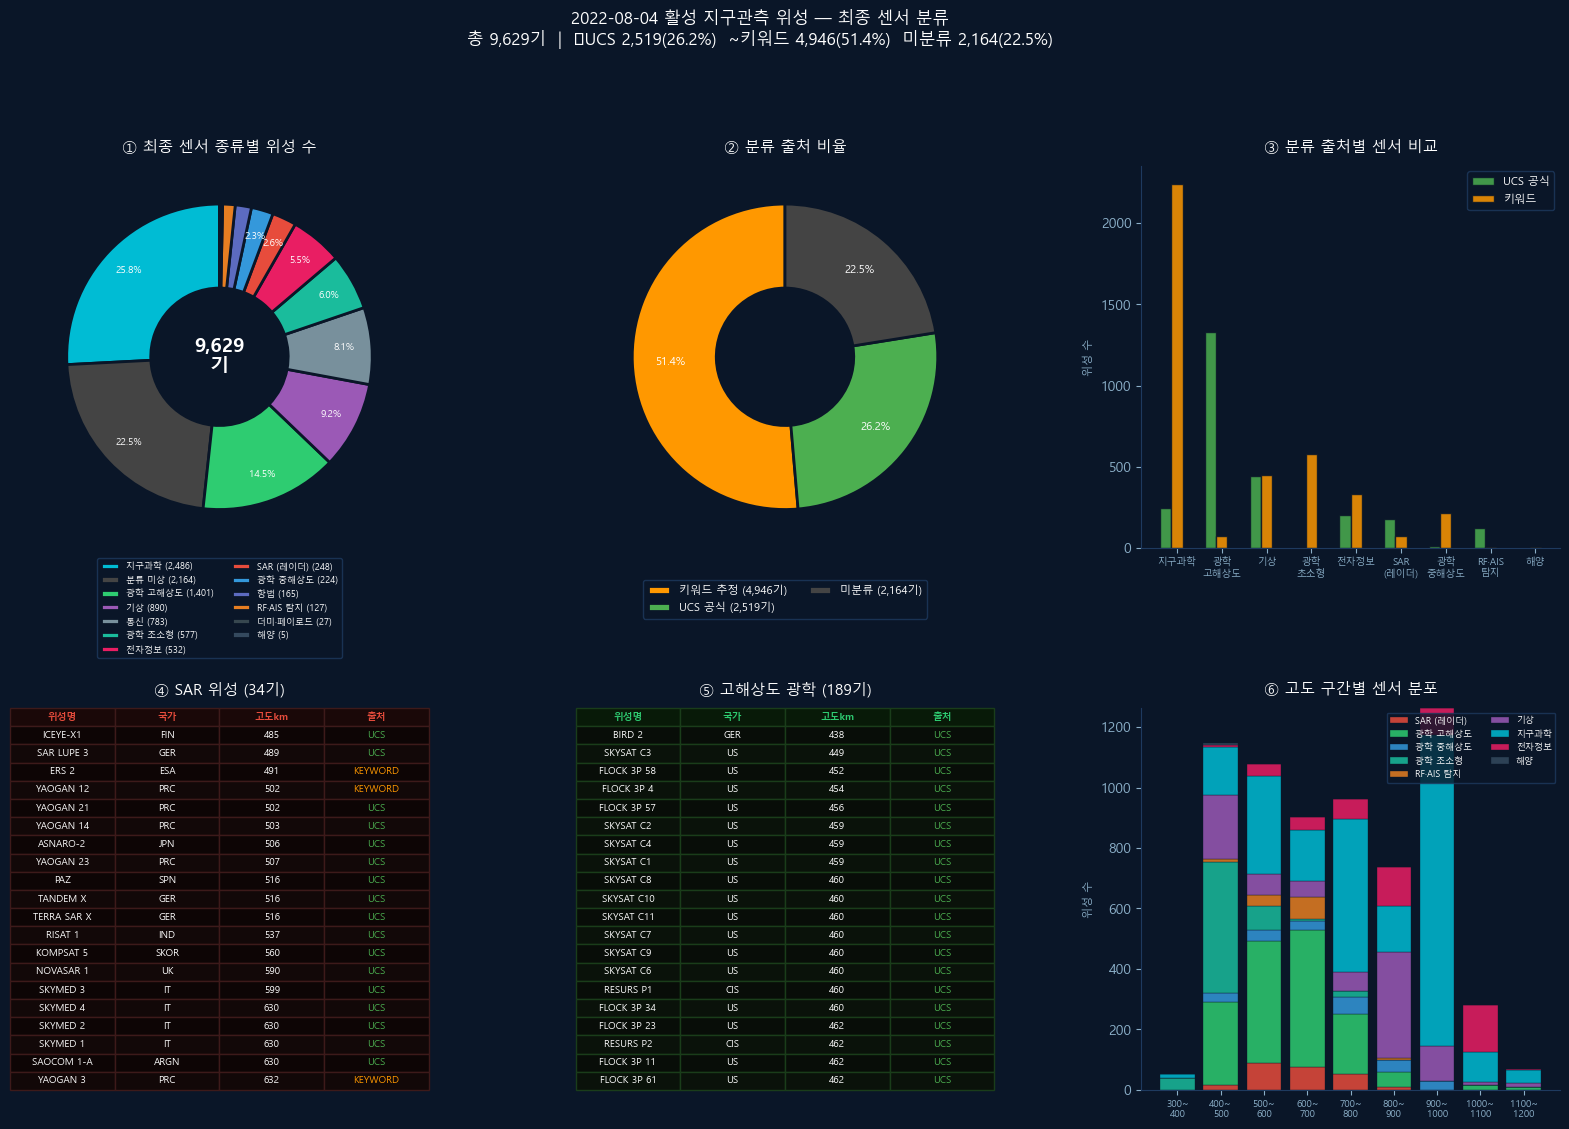

→ eo_satellite_final_v2.png 저장 완료
→ eo_satellites_final_classified_20220804.csv 저장 완료


In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# 현재 df 기준 통계
sensor_cnt = df["sensor"].value_counts()
src_cnt = df["source"].value_counts()

SENSOR_KR_FULL = {
    "SAR":    "SAR (레이더)",    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",   "OPT_SM": "광학 초소형",
    "RF":     "RF·AIS 탐지",    "MET":    "기상",
    "SCI":    "지구과학",        "ELINT":  "전자정보",
    "EW":     "조기경보",        "OCN":    "해양",
    "COM":    "통신",            "NAV":    "항법",
    "DUM":    "더미·페이로드",   "UNK":    "분류 미상",
}
SENSOR_CLR_FULL = {
    "SAR":    "#E74C3C", "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB", "OPT_SM": "#1ABC9C",
    "RF":     "#E67E22", "MET":    "#9B59B6",
    "SCI":    "#00BCD4", "ELINT":  "#E91E63",
    "EW":     "#FF5722", "OCN":    "#34495E",
    "COM":    "#78909C", "NAV":    "#5C6BC0",
    "DUM":    "#37474F", "UNK":    "#444444",
}
SRC_CLR = {
    "UCS":     "#4CAF50",
    "KEYWORD": "#FF9800",
    "CLAUDE":  "#2196F3",
    "UNK":     "#444444",
}
SRC_LBL = {
    "UCS":     "UCS 공식",
    "KEYWORD": "키워드 추정",
    "CLAUDE":  "Claude API",
    "UNK":     "미분류",
}

fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ① 센서 도넛
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")
labels  = [SENSOR_KR_FULL.get(s,s) for s in sensor_cnt.index]
sizes   = sensor_cnt.values
colors  = [SENSOR_CLR_FULL.get(s,"#888") for s in sensor_cnt.index]
wedges, _, ats = ax1.pie(
    sizes, labels=None, colors=colors,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    pctdistance=0.82,
    wedgeprops={"width":0.55,"edgecolor":"#0A1628","linewidth":2},
    startangle=90
)
for at in ats:
    at.set_fontsize(7); at.set_color("white")
ax1.text(0, 0, f"{len(df):,}\n기",
         ha="center", va="center", fontsize=14, fontweight="bold", color="white")
ax1.legend(wedges, [f"{l} ({v:,})" for l,v in zip(labels,sizes)],
           loc="lower center", bbox_to_anchor=(0.5,-0.30),
           ncol=2, fontsize=6.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax1.set_title("① 최종 센서 종류별 위성 수", color="white", fontsize=11, pad=10)

# ② 분류 출처 비율
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")
src_labels_list = [SRC_LBL.get(s,s) for s in src_cnt.index]
src_clrs        = [SRC_CLR.get(s,"#888") for s in src_cnt.index]
wedges2, _, ats2 = ax2.pie(
    src_cnt.values, labels=None, colors=src_clrs,
    autopct=lambda p: f"{p:.1f}%",
    pctdistance=0.75,
    wedgeprops={"width":0.55,"edgecolor":"#0A1628","linewidth":2},
    startangle=90
)
for at in ats2:
    at.set_fontsize(8); at.set_color("white")
ax2.legend(wedges2,
           [f"{l} ({v:,}기)" for l,v in zip(src_labels_list,src_cnt.values)],
           loc="lower center", bbox_to_anchor=(0.5,-0.20),
           ncol=2, fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax2.set_title("② 분류 출처 비율", color="white", fontsize=11, pad=10)

# ③ 분류 출처별 센서 막대
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")
sensors_show = [s for s in sensor_cnt.index
                if s not in ["UNK","COM","NAV","DUM","EW"]]
x = np.arange(len(sensors_show))
w = 0.25
for j, (src, color, label) in enumerate([
    ("UCS","#4CAF50","UCS 공식"),
    ("KEYWORD","#FF9800","키워드"),
]):
    vals = [((df["sensor"]==s)&(df["source"]==src)).sum()
             for s in sensors_show]
    ax3.bar(x+(j-1)*w, vals, w, label=label,
            color=color, alpha=0.85, edgecolor="#0A1628")
ax3.set_xticks(x)
ax3.set_xticklabels(
    [SENSOR_KR_FULL.get(s,s).replace(" ","\n") for s in sensors_show],
    fontsize=7, color="white")
ax3.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax3.set_title("③ 분류 출처별 센서 비교", color="white", fontsize=11, pad=10)
ax3.tick_params(colors="#8BAFC8")
ax3.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ④ SAR 위성 표
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628"); ax4.axis("off")
sar_show = (df[df["sensor"]=="SAR"]
            .sort_values("altitude_km")
            .drop_duplicates("norad_id").head(20))
ax4.set_title(f"④ SAR 위성 ({df[df['sensor']=='SAR']['norad_id'].nunique()}기)",
              color="white", fontsize=11, pad=10)
tbl_data = [[str(r["name"])[:20], str(r["country"])[:4],
             f"{r['altitude_km']:.0f}", r["source"]]
            for _, r in sar_show.iterrows()]
tbl = ax4.table(cellText=tbl_data,
                colLabels=["위성명","국가","고도km","출처"],
                cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(7)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1A0808")
        cell.set_text_props(color="#E74C3C", fontweight="bold")
    else:
        src_val = tbl_data[r-1][3]
        cell.set_facecolor("#120808" if r%2==0 else "#0D0505")
        cell.set_text_props(
            color=SRC_CLR.get(src_val,"white") if c==3 else "white")
    cell.set_edgecolor("#3D1A1A")

# ⑤ OPT_HR 위성 표
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628"); ax5.axis("off")
hr_show = (df[df["sensor"]=="OPT_HR"]
           .sort_values("altitude_km")
           .drop_duplicates("norad_id").head(20))
ax5.set_title(f"⑤ 고해상도 광학 ({df[df['sensor']=='OPT_HR']['norad_id'].nunique()}기)",
              color="white", fontsize=11, pad=10)
tbl_data2 = [[str(r["name"])[:20], str(r["country"])[:4],
              f"{r['altitude_km']:.0f}", r["source"]]
             for _, r in hr_show.iterrows()]
tbl2 = ax5.table(cellText=tbl_data2,
                 colLabels=["위성명","국가","고도km","출처"],
                 cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl2.auto_set_font_size(False); tbl2.set_fontsize(7)
for (r,c), cell in tbl2.get_celld().items():
    if r == 0:
        cell.set_facecolor("#081A08")
        cell.set_text_props(color="#2ECC71", fontweight="bold")
    else:
        src_val = tbl_data2[r-1][3]
        cell.set_facecolor("#0A120A" if r%2==0 else "#080D08")
        cell.set_text_props(
            color=SRC_CLR.get(src_val,"white") if c==3 else "white")
    cell.set_edgecolor("#1A3D1A")

# ⑥ 고도 구간별 분포
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")
bins       = [300,400,500,600,700,800,900,1000,1100,1200]
labels_bin = [f"{b}~\n{bins[i+1]}" for i,b in enumerate(bins[:-1])]
bottom     = np.zeros(len(bins)-1)
for sensor in ["SAR","OPT_HR","OPT_MR","OPT_SM","RF","MET","SCI","ELINT","OCN"]:
    sub   = df[df["sensor"]==sensor]
    color = SENSOR_CLR_FULL.get(sensor,"#888")
    cnt   = pd.cut(sub["altitude_km"], bins=bins).value_counts().reindex(
        pd.IntervalIndex.from_breaks(bins), fill_value=0).values
    ax6.bar(range(len(bins)-1), cnt, bottom=bottom,
            color=color, alpha=0.85, edgecolor="#0A1628", linewidth=0.3,
            label=SENSOR_KR_FULL.get(sensor,sensor))
    bottom += cnt
ax6.set_xticks(range(len(labels_bin)))
ax6.set_xticklabels(labels_bin, fontsize=7, color="#8BAFC8")
ax6.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 고도 구간별 센서 분포", color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=6.5, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F",
           framealpha=0.8, loc="upper right", ncol=2)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

ucs_n = (df["source"]=="UCS").sum()
kw_n  = (df["source"]=="KEYWORD").sum()
unk_n = (df["source"]=="UNK").sum()

fig.suptitle(
    f"2022-08-04 활성 지구관측 위성 — 최종 센서 분류\n"
    f"총 {len(df):,}기  |  "
    f"✓UCS {ucs_n:,}({ucs_n/len(df)*100:.1f}%)  "
    f"~키워드 {kw_n:,}({kw_n/len(df)*100:.1f}%)  "
    f"미분류 {unk_n:,}({unk_n/len(df)*100:.1f}%)",
    fontsize=12, color="white", y=1.01
)

plt.savefig("eo_satellite_final_v2.png", dpi=150,
            bbox_inches="tight", facecolor="#0A1628")
plt.show()
print("→ eo_satellite_final_v2.png 저장 완료")

# 최종 저장
df.to_csv("eo_satellites_final_classified_20220804.csv",
          index=False, encoding="utf-8-sig")
print("→ eo_satellites_final_classified_20220804.csv 저장 완료")

촬영 가능 위성: 374기 / 전체 9,629기
  광학 고해상도         :   189기 (50.5%)
  광학 초소형          :   111기 (29.7%)
  광학 중해상도         :    40기 (10.7%)
  SAR (레이더)       :    34기 (9.1%)


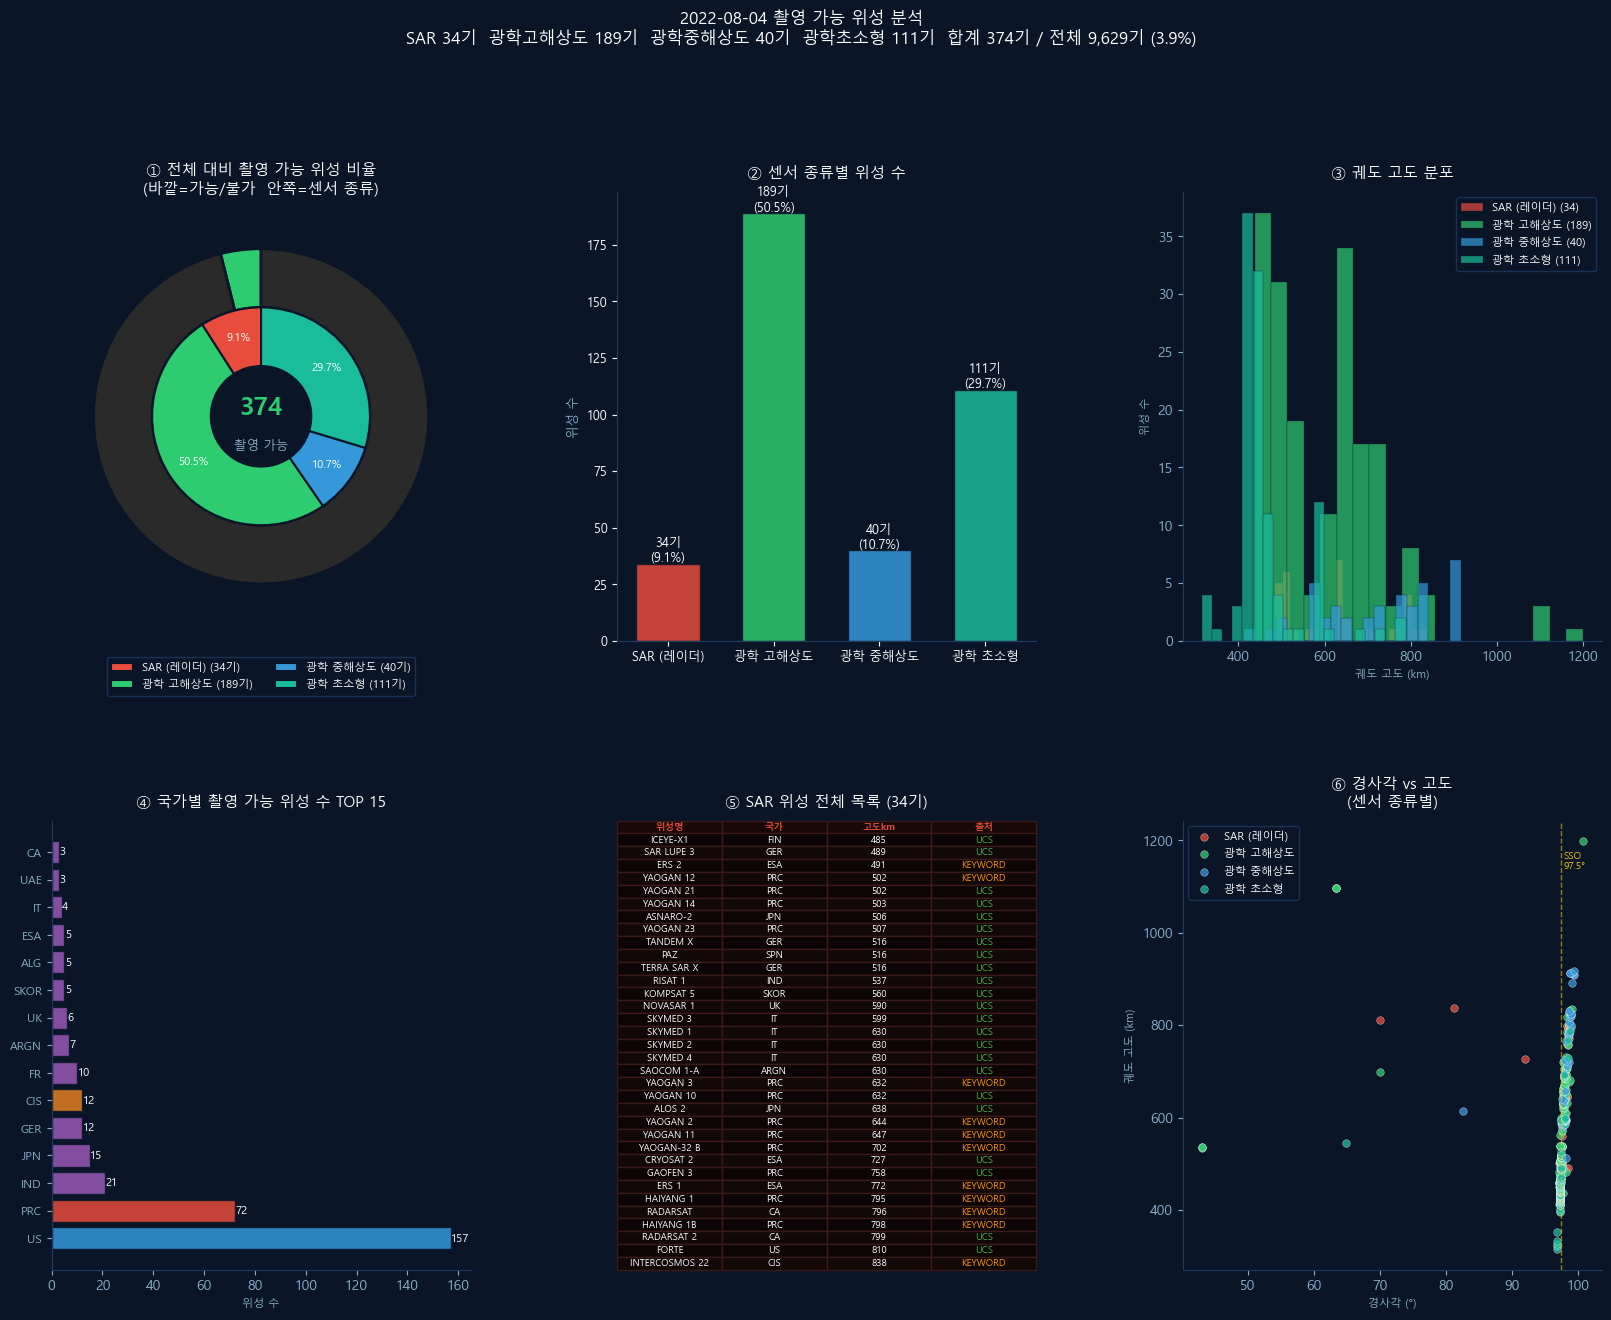

→ imaging_satellites_20220804.png 저장 완료
→ imaging_satellites_20220804.csv 저장 완료 (374기)
  → imaging_sar_20220804.csv (34기)
  → imaging_opt_hr_20220804.csv (189기)
  → imaging_opt_mr_20220804.csv (40기)
  → imaging_opt_sm_20220804.csv (111기)

촬영 가능 위성 전체 목록 (374기)
센서       위성명                            NORAD    국가    고도km     경사각°       출처
----------------------------------------------------------------------

  ── SAR (레이더) (34기) ──
  SAR      ICEYE-X1                     43114   FIN   485.0    97.36      UCS
  SAR      SAR LUPE 3                   32283   GER   488.8    98.22      UCS
  SAR      ERS 2                        23560   ESA   491.3    98.50  KEYWORD
  SAR      YAOGAN 12                    37875   PRC   501.5    97.31  KEYWORD
  SAR      YAOGAN 21                    40143   PRC   501.5    97.35      UCS
  SAR      YAOGAN 14                    38257   PRC   502.7    97.55      UCS
  SAR      ASNARO-2                     43152   JPN   505.8    97.42      UCS
  SAR      YAOGAN 2

In [34]:
"""
촬영 가능 위성 (SAR + OPT_HR + OPT_MR + OPT_SM) 시각화 + 리스트
사전 조건: df DataFrame 존재 (step3 결과)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
IMAGING_SENSORS = ["SAR", "OPT_HR", "OPT_MR", "OPT_SM"]

SENSOR_KR_IMG = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "OPT_SM": "광학 초소형",
}
SENSOR_CLR_IMG = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "OPT_SM": "#1ABC9C",
}
SRC_CLR = {
    "UCS":     "#4CAF50",
    "KEYWORD": "#FF9800",
    "CLAUDE":  "#2196F3",
    "UNK":     "#888888",
}

# ════════════════════════════════════════════════════════════════
# 촬영 가능 위성 필터링
# ════════════════════════════════════════════════════════════════
imaging_df = (df[df["sensor"].isin(IMAGING_SENSORS)]
              .drop_duplicates("norad_id")
              .sort_values(["sensor","altitude_km"])
              .reset_index(drop=True))

total_img  = len(imaging_df)
total_all  = len(df)

print("=" * 55)
print(f"촬영 가능 위성: {total_img}기 / 전체 {total_all:,}기")
print("=" * 55)
sensor_cnt = imaging_df["sensor"].value_counts()
for sensor, cnt in sensor_cnt.items():
    kr  = SENSOR_KR_IMG.get(sensor, sensor)
    pct = cnt / total_img * 100
    print(f"  {kr:<16}: {cnt:>5}기 ({pct:.1f}%)")

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 14))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── Chart 1: 촬영 가능 vs 불가 도넛 ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

# 바깥: 촬영가능 vs 불가
outer_sizes  = [total_img, total_all - total_img]
outer_labels = [f"촬영 가능\n({total_img}기)",
                f"촬영 불가\n({total_all-total_img:,}기)"]
outer_colors = ["#2ECC71", "#2A2A2A"]

# 안쪽: 센서 종류별
inner_sizes  = [sensor_cnt.get(s, 0) for s in IMAGING_SENSORS]
inner_colors = [SENSOR_CLR_IMG[s] for s in IMAGING_SENSORS]

ax1.pie(outer_sizes, labels=None, colors=outer_colors,
        wedgeprops={"width":0.35,"edgecolor":"#0A1628","linewidth":2},
        startangle=90, radius=1.0)
wedges_in, _, ats = ax1.pie(
    inner_sizes, labels=None, colors=inner_colors,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    pctdistance=0.75,
    wedgeprops={"width":0.35,"edgecolor":"#0A1628","linewidth":1.5},
    startangle=90, radius=0.65
)
for at in ats:
    at.set_fontsize(8); at.set_color("white")

ax1.text(0, 0.05, f"{total_img}",
         ha="center", va="center", fontsize=18,
         fontweight="bold", color="#2ECC71")
ax1.text(0, -0.18, "촬영 가능",
         ha="center", va="center", fontsize=9, color="#8BAFC8")

# 범례
ax1.legend(wedges_in,
           [f"{SENSOR_KR_IMG[s]} ({sensor_cnt.get(s,0)}기)"
            for s in IMAGING_SENSORS],
           loc="lower center", bbox_to_anchor=(0.5, -0.18),
           ncol=2, fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax1.set_title("① 전체 대비 촬영 가능 위성 비율\n(바깥=가능/불가  안쪽=센서 종류)",
              color="white", fontsize=11, pad=10)

# ── Chart 2: 센서별 위성 수 막대 ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")

sensors_ordered = ["SAR","OPT_HR","OPT_MR","OPT_SM"]
cnts   = [sensor_cnt.get(s,0) for s in sensors_ordered]
colors = [SENSOR_CLR_IMG[s] for s in sensors_ordered]
labels = [SENSOR_KR_IMG[s] for s in sensors_ordered]

bars = ax2.bar(labels, cnts, color=colors,
               alpha=0.85, edgecolor="#0A1628", width=0.6)
for bar, cnt in zip(bars, cnts):
    pct = cnt / total_img * 100
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1,
             f"{cnt}기\n({pct:.1f}%)",
             ha="center", fontsize=9, color="white")

ax2.set_ylabel("위성 수", color="#8BAFC8", fontsize=9)
ax2.set_title("② 센서 종류별 위성 수",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="white", labelsize=9)
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 3: 고도 분포 (센서별) ──────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")

for sensor in sensors_ordered:
    sub = imaging_df[imaging_df["sensor"]==sensor]
    ax3.hist(sub["altitude_km"], bins=20,
             color=SENSOR_CLR_IMG[sensor], alpha=0.7,
             label=f"{SENSOR_KR_IMG[sensor]} ({len(sub)})",
             edgecolor="#0A1628", linewidth=0.3)

ax3.set_xlabel("궤도 고도 (km)", color="#8BAFC8", fontsize=8)
ax3.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax3.set_title("③ 궤도 고도 분포",
              color="white", fontsize=11, pad=10)
ax3.tick_params(colors="#8BAFC8")
ax3.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 4: 국가별 촬영 위성 수 ────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628")

country_cnt = imaging_df["country"].value_counts().head(15)
bar_colors  = [
    "#E74C3C" if c in ["PRC","China"] else
    "#3498DB" if c in ["US","USA"] else
    "#2ECC71" if c in ["KOR","ROKL","South Korea"] else
    "#E67E22" if c in ["RUS","CIS"] else
    "#9B59B6"
    for c in country_cnt.index
]
bars2 = ax4.barh(range(len(country_cnt)), country_cnt.values,
                 color=bar_colors, alpha=0.85, edgecolor="#0A1628")
ax4.set_yticks(range(len(country_cnt)))
ax4.set_yticklabels(country_cnt.index, color="white", fontsize=8.5)
ax4.set_xlabel("위성 수", color="#8BAFC8", fontsize=8)
ax4.set_title("④ 국가별 촬영 가능 위성 수 TOP 15",
              color="white", fontsize=11, pad=10)
ax4.tick_params(colors="#8BAFC8")
for bar, val in zip(bars2, country_cnt.values):
    ax4.text(val+0.2, bar.get_y()+bar.get_height()/2,
             str(val), va="center", fontsize=8, color="white")
for spine in ax4.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 5: SAR 위성 목록 ───────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628"); ax5.axis("off")

sar_list = imaging_df[imaging_df["sensor"]=="SAR"].reset_index(drop=True)
ax5.set_title(f"⑤ SAR 위성 전체 목록 ({len(sar_list)}기)",
              color="white", fontsize=11, pad=10)

tbl_data = [[str(r["name"])[:22], str(r["country"])[:4],
             f"{r['altitude_km']:.0f}", r["source"]]
            for _, r in sar_list.iterrows()]
tbl = ax5.table(cellText=tbl_data,
                colLabels=["위성명","국가","고도km","출처"],
                cellLoc="center", loc="center", bbox=[0,0,1,1])
tbl.auto_set_font_size(False); tbl.set_fontsize(6.8)
for (r,c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_facecolor("#1A0808")
        cell.set_text_props(color="#E74C3C", fontweight="bold")
    else:
        src_val = tbl_data[r-1][3]
        cell.set_facecolor("#120808" if r%2==0 else "#0D0505")
        cell.set_text_props(
            color=SRC_CLR.get(src_val,"white") if c==3 else "white")
    cell.set_edgecolor("#3D1A1A")

# ── Chart 6: 경사각 vs 고도 (센서별) ────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

for sensor in sensors_ordered:
    sub = imaging_df[imaging_df["sensor"]==sensor]
    ax6.scatter(sub["inclination"], sub["altitude_km"],
                s=30, c=SENSOR_CLR_IMG[sensor], alpha=0.75,
                label=SENSOR_KR_IMG[sensor],
                edgecolors="white", linewidth=0.3)

ax6.axvline(97.5, color="#F1C40F", linewidth=1,
            linestyle="--", alpha=0.6)
ax6.text(97.8, imaging_df["altitude_km"].max()*0.95,
         "SSO\n97.5°", color="#F1C40F", fontsize=7)
ax6.set_xlabel("경사각 (°)", color="#8BAFC8", fontsize=8)
ax6.set_ylabel("궤도 고도 (km)", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 경사각 vs 고도\n(센서 종류별)",
              color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

fig.suptitle(
    f"2022-08-04 촬영 가능 위성 분석\n"
    f"SAR {sensor_cnt.get('SAR',0)}기  "
    f"광학고해상도 {sensor_cnt.get('OPT_HR',0)}기  "
    f"광학중해상도 {sensor_cnt.get('OPT_MR',0)}기  "
    f"광학초소형 {sensor_cnt.get('OPT_SM',0)}기  "
    f"합계 {total_img}기 / 전체 {total_all:,}기 ({total_img/total_all*100:.1f}%)",
    fontsize=12, color="white", y=1.01
)

plt.savefig("imaging_satellites_20220804.png",
            dpi=150, bbox_inches="tight", facecolor="#0A1628")
plt.show()
print("→ imaging_satellites_20220804.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 리스트 저장
# ════════════════════════════════════════════════════════════════
# 전체 리스트 (중복 없이)
imaging_df.to_csv("imaging_satellites_20220804.csv",
                  index=False, encoding="utf-8-sig")
print(f"→ imaging_satellites_20220804.csv 저장 완료 ({len(imaging_df)}기)")

# 센서별 개별 저장
for sensor in IMAGING_SENSORS:
    sub  = imaging_df[imaging_df["sensor"]==sensor].reset_index(drop=True)
    fname = f"imaging_{sensor.lower()}_20220804.csv"
    sub.to_csv(fname, index=False, encoding="utf-8-sig")
    print(f"  → {fname} ({len(sub)}기)")

# 콘솔 출력 — 전체 목록
print(f"\n{'='*65}")
print(f"촬영 가능 위성 전체 목록 ({total_img}기)")
print(f"{'='*65}")
print(f"{'센서':<8} {'위성명':<28} {'NORAD':>7} "
      f"{'국가':>5} {'고도km':>7} {'경사각°':>8} {'출처':>8}")
print("-" * 70)
for sensor in sensors_ordered:
    sub = imaging_df[imaging_df["sensor"]==sensor]
    print(f"\n  ── {SENSOR_KR_IMG[sensor]} ({len(sub)}기) ──")
    for _, row in sub.iterrows():
        print(f"  {row['sensor']:<8} {str(row['name'])[:26]:<26} "
              f"{row['norad_id']:>7} {str(row['country']):>5} "
              f"{row['altitude_km']:>7.1f} {row['inclination']:>8.2f} "
              f"{row['source']:>8}")

In [35]:
# 촬영 가능 위성 = SAR + OPT_HR + OPT_MR + OPT_SM
IMAGING_SENSORS = ["SAR", "OPT_HR", "OPT_MR", "OPT_SM"]

imaging_df = (df[df["sensor"].isin(IMAGING_SENSORS)]
              .drop_duplicates("norad_id")
              .sort_values(["sensor","altitude_km"])
              .reset_index(drop=True))

print(f"촬영 가능 위성: {len(imaging_df)}기")
print(imaging_df["sensor"].value_counts())

촬영 가능 위성: 374기
sensor
OPT_HR    189
OPT_SM    111
OPT_MR     40
SAR        34
Name: count, dtype: int64


### 상업 위성 필터링

In [36]:
import pandas as pd

# UCS 파일 로드 (실제 파일명으로 변경)
ucs_raw = pd.read_excel("UCS-Satellite-Database 5-1-2023.xlsx")

# Users, Operator 관련 컬럼 확인
print("전체 컬럼:")
for c in ucs_raw.columns:
    print(f"  {c}")

print(f"\n'Users' 컬럼 존재: {'Users' in ucs_raw.columns}")
print(f"\nUsers 값 분포:")
if "Users" in ucs_raw.columns:
    print(ucs_raw["Users"].value_counts().head(20))

전체 컬럼:
  Name of Satellite, Alternate Names
  Current Official Name of Satellite
  Country/Org of UN Registry
  Country of Operator/Owner
  Operator/Owner
  Users
  Purpose
  Detailed Purpose
  Class of Orbit
  Type of Orbit
  Longitude of GEO (degrees)
  Perigee (km)
  Apogee (km)
  Eccentricity
  Inclination (degrees)
  Period (minutes)
  Launch Mass (kg.)
  Dry Mass (kg.)
  Power (watts)
  Date of Launch
  Expected Lifetime (yrs.)
  Contractor
  Country of Contractor
  Launch Site
  Launch Vehicle
  COSPAR Number
  NORAD Number
  Comments
  Unnamed: 28
  Source Used for Orbital Data
  Source
  Source.1
  Source.2
  Source.3
  Source.4
  Source.5
  Source.6
  Unnamed: 37
  Unnamed: 38
  Unnamed: 39
  Unnamed: 40
  Unnamed: 41
  Unnamed: 42
  Unnamed: 43
  Unnamed: 44
  Unnamed: 45
  Unnamed: 46
  Unnamed: 47
  Unnamed: 48
  Unnamed: 49
  Unnamed: 50
  Unnamed: 51
  Unnamed: 52
  Unnamed: 53
  Unnamed: 54
  Unnamed: 55
  Unnamed: 56
  Unnamed: 57
  Unnamed: 58
  Unnamed: 59
  Unnamed:

Step 1 — UCS Commercial 위성 필터링
  전체 UCS 위성:      7,560기
  Commercial 위성:    6,269기

  Users 값 분포 (Commercial 포함):
Users_clean
Commercial                        6081
Government/Commercial               97
Military/Commercial                 82
Commercial/Civil                     4
Commercial/Military                  2
Civil/Commercial                     1
Commercial/Government                1
Government/Commercial/Military       1

Step 2 — 촬영 가능 위성과 조인
  촬영 가능 위성:        374기
  상업 촬영 위성 (조인): 89기
  키워드 보완 후:        202기

상업 촬영 위성 최종 목록 (202기)

[센서별 통계]
  SAR (레이더)       : 6기
  광학 고해상도         : 81기
  광학 중해상도         : 6기
  광학 초소형          : 109기

[위성 전체 목록]
센서       위성명                            NORAD    국가 운용사                     고도km       출처
------------------------------------------------------------------------------------------

  ── SAR (레이더) (6기) ──
  SAR      ICEYE-X1                     43114   FIN ICEYE Ltd.             485.0      UCS
  SAR      PAZ                     

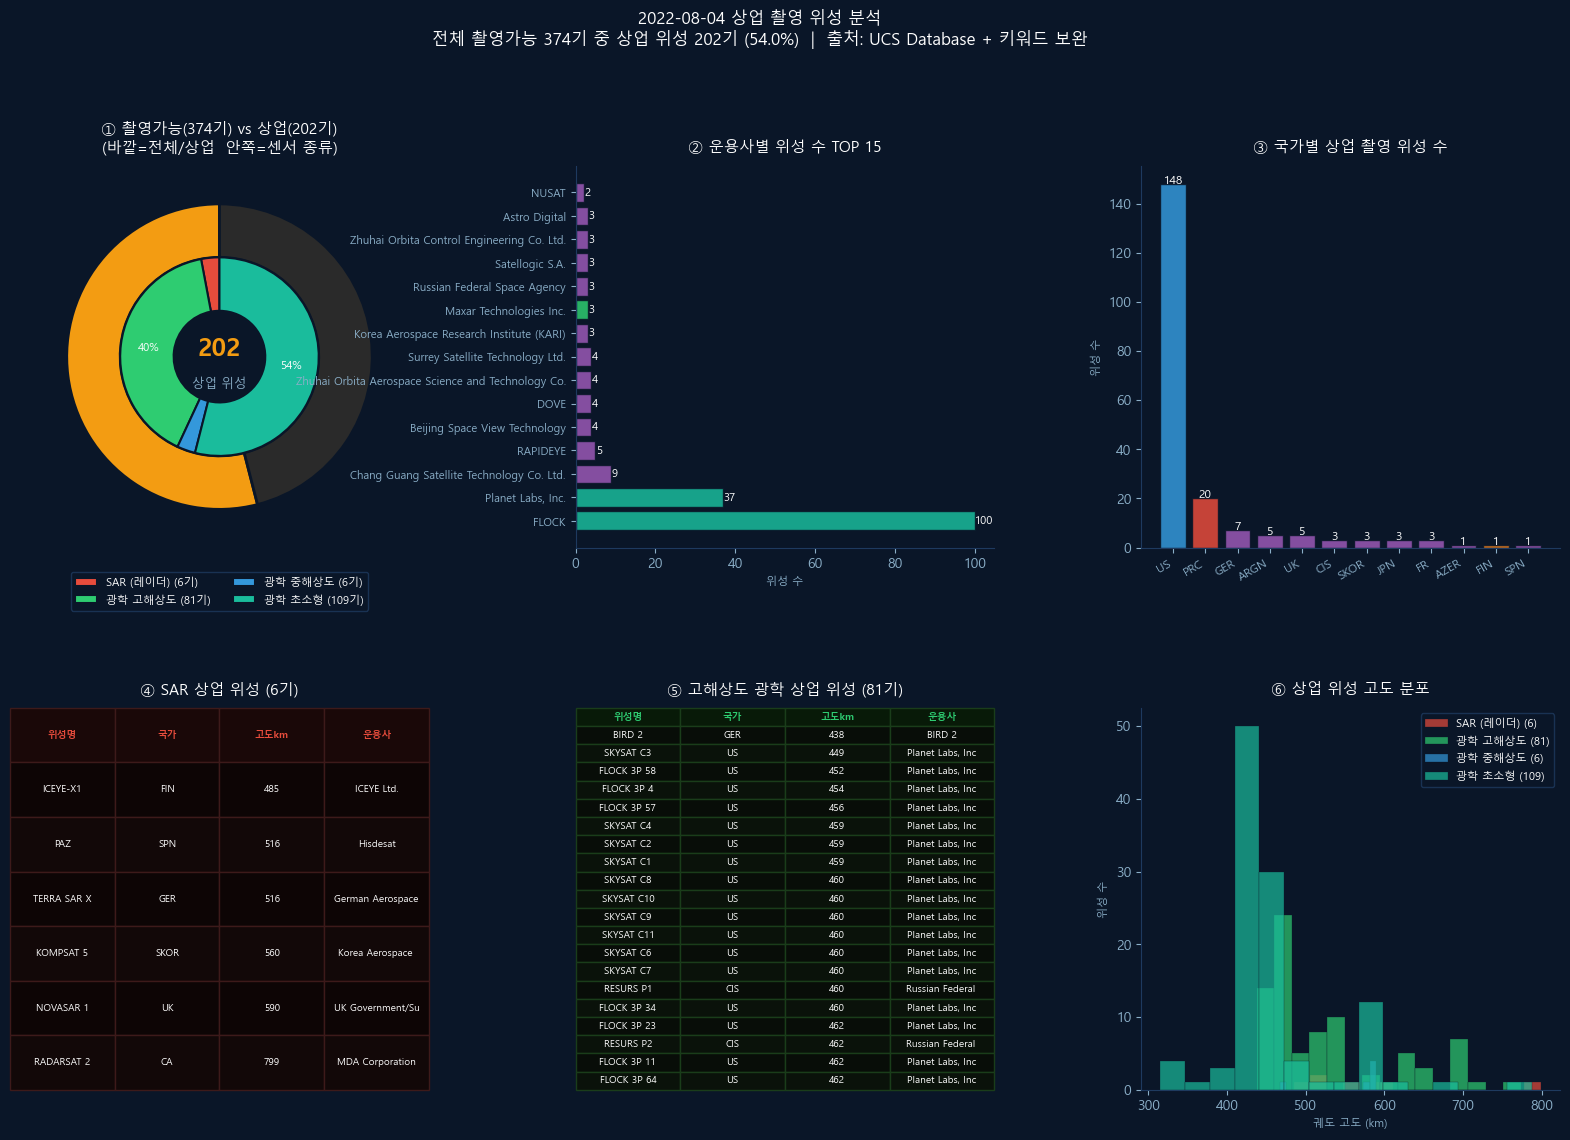

→ commercial_imaging_satellites_20220804.png 저장 완료

상업 촬영 위성 — 검증 사이트 포함 목록

▶ SAR (레이더) (6기)
  위성명                          운용사                  검증 URL
  ---------------------------------------------------------------------------
  ICEYE-X1                   ICEYE Ltd.           https://www.iceye.com/sar-data
  PAZ                        Hisdesat             https://space.skyrocket.de/doc_sdat/paz.htm
  TERRA SAR X                German Aerospace C   https://space.skyrocket.de/doc_sdat/terra-sar-x.htm
  KOMPSAT 5                  Korea Aerospace Re   https://sianalytics.ai
  NOVASAR 1                  UK Government/Surr   https://space.skyrocket.de/doc_sdat/novasar-1.htm
  RADARSAT 2                 MDA Corporation      https://space.skyrocket.de/doc_sdat/radarsat-2.htm

▶ 광학 고해상도 (81기)
  위성명                          운용사                  검증 URL
  ---------------------------------------------------------------------------
  BIRD 2                     BIRD 2               https://space.

In [37]:
"""
상업 위성 필터링
UCS Users = "Commercial" 기준 + NORAD ID 조인
검증 사이트 링크 포함
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
UCS_PATH        = "UCS-Satellite-Database 5-1-2023.xlsx"
IMAGING_SENSORS = ["SAR", "OPT_HR", "OPT_MR", "OPT_SM"]

SENSOR_KR = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "OPT_SM": "광학 초소형",
}
SENSOR_CLR = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "OPT_SM": "#1ABC9C",
}
SRC_CLR = {
    "UCS":     "#4CAF50",
    "KEYWORD": "#FF9800",
    "CLAUDE":  "#2196F3",
    "UNK":     "#888888",
}

# 주요 상업 위성 검증 사이트
VERIFY_URLS = {
    "ICEYE":      "https://www.iceye.com/sar-data",
    "CAPELLA":    "https://capellaspace.com",
    "UMBRA":      "https://umbra.space",
    "WORLDVIEW":  "https://www.maxar.com",
    "GEOEYE":     "https://www.maxar.com",
    "PLEIADES":   "https://www.intelligence-airbusds.com",
    "SPOT":       "https://www.intelligence-airbusds.com",
    "SKYSAT":     "https://www.planet.com",
    "FLOCK":      "https://www.planet.com",
    "DOVE":       "https://www.planet.com",
    "NUSAT":      "https://satellogic.com",
    "RAPIDEYE":   "https://www.planet.com",
    "KOMPSAT":    "https://sianalytics.ai",
    "SUPERVIEW":  "https://www.spaceview.com.cn",
    "JILIN":      "https://www.jl1.com.cn",
}

def get_verify_url(name):
    name_upper = str(name).upper()
    for keyword, url in VERIFY_URLS.items():
        if keyword.upper() in name_upper:
            return url
    return "https://space.skyrocket.de/doc_sdat/" + \
           str(name).lower().replace(" ","-").replace("/","-") + ".htm"

# ════════════════════════════════════════════════════════════════
# Step 1 — UCS Commercial 필터링
# ════════════════════════════════════════════════════════════════
print("=" * 60)
print("Step 1 — UCS Commercial 위성 필터링")
print("=" * 60)

ucs_raw = pd.read_excel(UCS_PATH)

# Users 컬럼 정제
ucs_raw["Users_clean"] = ucs_raw["Users"].astype(str).str.strip()

# Commercial 포함 위성 (Commercial/Government 등 혼합도 포함)
commercial_mask = ucs_raw["Users_clean"].str.contains(
    "Commercial", case=False, na=False)
ucs_commercial  = ucs_raw[commercial_mask].copy()

print(f"  전체 UCS 위성:      {len(ucs_raw):,}기")
print(f"  Commercial 위성:    {len(ucs_commercial):,}기")
print(f"\n  Users 값 분포 (Commercial 포함):")
print(ucs_commercial["Users_clean"].value_counts().to_string())

# NORAD ID 추출
ucs_commercial["norad_id"] = pd.to_numeric(
    ucs_commercial["NORAD Number"], errors="coerce")
ucs_commercial = ucs_commercial.dropna(subset=["norad_id"])
ucs_commercial["norad_id"] = ucs_commercial["norad_id"].astype(int)

# ════════════════════════════════════════════════════════════════
# Step 2 — 촬영 가능 위성과 조인
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("Step 2 — 촬영 가능 위성과 조인")
print("=" * 60)

# imaging_df: 촬영 가능 위성 374기
commercial_imaging = imaging_df.merge(
    ucs_commercial[["norad_id","Users_clean","Operator/Owner",
                    "Contractor","Country of Contractor"]],
    on="norad_id",
    how="inner"
)

print(f"  촬영 가능 위성:        {len(imaging_df)}기")
print(f"  상업 촬영 위성 (조인): {len(commercial_imaging)}기")

# ── 추가: UCS 미매칭이지만 명백한 상업 위성 키워드 보완 ───────────
COMMERCIAL_KEYWORDS = [
    "ICEYE","CAPELLA","UMBRA","SKYSAT","FLOCK","DOVE",
    "NUSAT","RAPIDEYE","WORLDVIEW","GEOEYE","PLEIADES",
    "SPOT-6","SPOT-7","SUPERVIEW","JILIN","KOMPSAT-3",
    "KOMPSAT-2","BIRD 2","TRIPLESAT",
]
extra_mask = (
    imaging_df["norad_id"].isin(commercial_imaging["norad_id"]) == False
) & imaging_df["name"].str.upper().apply(
    lambda n: any(kw.upper() in n for kw in COMMERCIAL_KEYWORDS)
)
extra_commercial = imaging_df[extra_mask].copy()
extra_commercial["Users_clean"]    = "Commercial (키워드 추정)"
extra_commercial["Operator/Owner"] = extra_commercial["name"].apply(
    lambda n: next((kw for kw in COMMERCIAL_KEYWORDS
                    if kw.upper() in n.upper()), "")
)

# 합치기
all_commercial = pd.concat(
    [commercial_imaging, extra_commercial], ignore_index=True
).drop_duplicates("norad_id")

print(f"  키워드 보완 후:        {len(all_commercial)}기")

# ════════════════════════════════════════════════════════════════
# Step 3 — 결과 출력
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"상업 촬영 위성 최종 목록 ({len(all_commercial)}기)")
print("=" * 60)

print(f"\n[센서별 통계]")
for sensor in IMAGING_SENSORS:
    cnt = (all_commercial["sensor"] == sensor).sum()
    kr  = SENSOR_KR.get(sensor, sensor)
    print(f"  {kr:<16}: {cnt}기")

print(f"\n[위성 전체 목록]")
print(f"{'센서':<8} {'위성명':<28} {'NORAD':>7} {'국가':>5} "
      f"{'운용사':<20} {'고도km':>7} {'출처':>8}")
print("-" * 90)

for sensor in IMAGING_SENSORS:
    sub = all_commercial[all_commercial["sensor"]==sensor].sort_values("altitude_km")
    if sub.empty:
        continue
    print(f"\n  ── {SENSOR_KR[sensor]} ({len(sub)}기) ──")
    for _, row in sub.iterrows():
        op = str(row.get("Operator/Owner",""))[:18]
        print(f"  {row['sensor']:<8} {str(row['name'])[:26]:<26} "
              f"{row['norad_id']:>7} {str(row['country']):>5} "
              f"{op:<20} {row['altitude_km']:>7.1f} "
              f"{row['source']:>8}")

# 검증 URL 추가
all_commercial["verify_url"] = all_commercial["name"].apply(get_verify_url)

# CSV 저장
all_commercial.to_csv("commercial_imaging_satellites_20220804.csv",
                      index=False, encoding="utf-8-sig")
print(f"\n→ commercial_imaging_satellites_20220804.csv 저장 완료")

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

sensor_cnt_com = all_commercial["sensor"].value_counts()

# ── Chart 1: 전체 vs 상업 비교 도넛 ─────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

outer_sizes  = [len(all_commercial), len(imaging_df)-len(all_commercial)]
outer_colors = ["#F39C12", "#2A2A2A"]
inner_sizes  = [sensor_cnt_com.get(s,0) for s in IMAGING_SENSORS]
inner_colors = [SENSOR_CLR[s] for s in IMAGING_SENSORS]

ax1.pie(outer_sizes, colors=outer_colors,
        wedgeprops={"width":0.35,"edgecolor":"#0A1628","linewidth":2},
        startangle=90, radius=1.0)
wedges_in, _, ats = ax1.pie(
    inner_sizes, labels=None, colors=inner_colors,
    autopct=lambda p: f"{p:.0f}%" if p > 5 else "",
    pctdistance=0.72,
    wedgeprops={"width":0.35,"edgecolor":"#0A1628","linewidth":1.5},
    startangle=90, radius=0.65
)
for at in ats:
    at.set_fontsize(8); at.set_color("white")

ax1.text(0, 0.05, f"{len(all_commercial)}",
         ha="center", va="center", fontsize=18,
         fontweight="bold", color="#F39C12")
ax1.text(0, -0.18, "상업 위성",
         ha="center", va="center", fontsize=9, color="#8BAFC8")
ax1.legend(wedges_in,
           [f"{SENSOR_KR[s]} ({sensor_cnt_com.get(s,0)}기)"
            for s in IMAGING_SENSORS],
           loc="lower center", bbox_to_anchor=(0.5,-0.18),
           ncol=2, fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
ax1.set_title(
    f"① 촬영가능({len(imaging_df)}기) vs 상업({len(all_commercial)}기)\n"
    f"(바깥=전체/상업  안쪽=센서 종류)",
    color="white", fontsize=11, pad=10)

# ── Chart 2: 운용사별 위성 수 ────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor("#0A1628")

op_cnt = all_commercial["Operator/Owner"].fillna("Unknown").value_counts().head(15)
bar_colors2 = []
for op in op_cnt.index:
    op_u = str(op).upper()
    if any(k in op_u for k in ["PLANET","SKYSAT","FLOCK"]):
        bar_colors2.append("#1ABC9C")
    elif any(k in op_u for k in ["MAXAR","WORLDVIEW","GEOEYE"]):
        bar_colors2.append("#2ECC71")
    elif any(k in op_u for k in ["AIRBUS","PLEIADES","SPOT"]):
        bar_colors2.append("#3498DB")
    elif any(k in op_u for k in ["ICEYE","CAPELLA","UMBRA"]):
        bar_colors2.append("#E74C3C")
    else:
        bar_colors2.append("#9B59B6")

bars = ax2.barh(range(len(op_cnt)), op_cnt.values,
                color=bar_colors2, alpha=0.85, edgecolor="#0A1628")
ax2.set_yticks(range(len(op_cnt)))
ax2.set_yticklabels(op_cnt.index, color="white", fontsize=8)
ax2.set_xlabel("위성 수", color="#8BAFC8", fontsize=8)
ax2.set_title("② 운용사별 위성 수 TOP 15",
              color="white", fontsize=11, pad=10)
ax2.tick_params(colors="#8BAFC8")
for bar, val in zip(bars, op_cnt.values):
    ax2.text(val+0.1, bar.get_y()+bar.get_height()/2,
             str(val), va="center", fontsize=8, color="white")
for spine in ax2.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 3: 국가별 상업 위성 수 ────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor("#0A1628")

country_cnt = all_commercial["country"].value_counts().head(12)
bar_colors3 = [
    "#3498DB" if c in ["US","USA"] else
    "#E74C3C" if c in ["PRC","China"] else
    "#2ECC71" if c in ["KOR","South Korea","ROKL"] else
    "#E67E22" if c in ["FIN","Finland"] else
    "#9B59B6"
    for c in country_cnt.index
]
bars3 = ax3.bar(range(len(country_cnt)), country_cnt.values,
                color=bar_colors3, alpha=0.85, edgecolor="#0A1628")
ax3.set_xticks(range(len(country_cnt)))
ax3.set_xticklabels(country_cnt.index, color="white",
                    fontsize=8.5, rotation=30, ha="right")
ax3.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax3.set_title("③ 국가별 상업 촬영 위성 수",
              color="white", fontsize=11, pad=10)
ax3.tick_params(colors="#8BAFC8")
for bar, val in zip(bars3, country_cnt.values):
    ax3.text(bar.get_x()+bar.get_width()/2, val+0.1,
             str(val), ha="center", fontsize=8.5, color="white")
for spine in ax3.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 4: SAR 상업 위성 표 ────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor("#0A1628"); ax4.axis("off")

sar_com = (all_commercial[all_commercial["sensor"]=="SAR"]
           .sort_values("altitude_km"))
ax4.set_title(f"④ SAR 상업 위성 ({len(sar_com)}기)",
              color="white", fontsize=11, pad=10)
if not sar_com.empty:
    tbl_d = [[str(r["name"])[:22],
              str(r["country"])[:4],
              f"{r['altitude_km']:.0f}",
              str(r.get("Operator/Owner",""))[:16]]
             for _, r in sar_com.iterrows()]
    tbl = ax4.table(cellText=tbl_d,
                    colLabels=["위성명","국가","고도km","운용사"],
                    cellLoc="center", loc="center", bbox=[0,0,1,1])
    tbl.auto_set_font_size(False); tbl.set_fontsize(7)
    for (r,c), cell in tbl.get_celld().items():
        if r == 0:
            cell.set_facecolor("#1A0808")
            cell.set_text_props(color="#E74C3C", fontweight="bold")
        else:
            cell.set_facecolor("#120808" if r%2==0 else "#0D0505")
            cell.set_text_props(color="white")
        cell.set_edgecolor("#3D1A1A")

# ── Chart 5: OPT_HR 상업 위성 표 ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628"); ax5.axis("off")

hr_com = (all_commercial[all_commercial["sensor"]=="OPT_HR"]
          .drop_duplicates("norad_id")
          .sort_values("altitude_km").head(20))
ax5.set_title(
    f"⑤ 고해상도 광학 상업 위성 ({all_commercial[all_commercial['sensor']=='OPT_HR']['norad_id'].nunique()}기)",
    color="white", fontsize=11, pad=10)
if not hr_com.empty:
    tbl_d2 = [[str(r["name"])[:22],
               str(r["country"])[:4],
               f"{r['altitude_km']:.0f}",
               str(r.get("Operator/Owner",""))[:16]]
              for _, r in hr_com.iterrows()]
    tbl2 = ax5.table(cellText=tbl_d2,
                     colLabels=["위성명","국가","고도km","운용사"],
                     cellLoc="center", loc="center", bbox=[0,0,1,1])
    tbl2.auto_set_font_size(False); tbl2.set_fontsize(7)
    for (r,c), cell in tbl2.get_celld().items():
        if r == 0:
            cell.set_facecolor("#081A08")
            cell.set_text_props(color="#2ECC71", fontweight="bold")
        else:
            cell.set_facecolor("#0A120A" if r%2==0 else "#080D08")
            cell.set_text_props(color="white")
        cell.set_edgecolor("#1A3D1A")

# ── Chart 6: 고도 분포 ───────────────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

for sensor in IMAGING_SENSORS:
    sub = all_commercial[all_commercial["sensor"]==sensor]
    if sub.empty:
        continue
    ax6.hist(sub["altitude_km"], bins=15,
             color=SENSOR_CLR[sensor], alpha=0.7,
             label=f"{SENSOR_KR[sensor]} ({len(sub)})",
             edgecolor="#0A1628", linewidth=0.3)

ax6.set_xlabel("궤도 고도 (km)", color="#8BAFC8", fontsize=8)
ax6.set_ylabel("위성 수", color="#8BAFC8", fontsize=8)
ax6.set_title("⑥ 상업 위성 고도 분포",
              color="white", fontsize=11, pad=10)
ax6.tick_params(colors="#8BAFC8")
ax6.legend(fontsize=8, labelcolor="white",
           facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

fig.suptitle(
    f"2022-08-04 상업 촬영 위성 분석\n"
    f"전체 촬영가능 {len(imaging_df)}기 중 상업 위성 {len(all_commercial)}기 "
    f"({len(all_commercial)/len(imaging_df)*100:.1f}%)  "
    f"|  출처: UCS Database + 키워드 보완",
    fontsize=12, color="white", y=1.01
)

plt.savefig("commercial_imaging_satellites_20220804.png",
            dpi=150, bbox_inches="tight", facecolor="#0A1628")
plt.show()
print("→ commercial_imaging_satellites_20220804.png 저장 완료")

# ════════════════════════════════════════════════════════════════
# 검증 사이트 포함 최종 출력
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("상업 촬영 위성 — 검증 사이트 포함 목록")
print("=" * 65)
for sensor in IMAGING_SENSORS:
    sub = all_commercial[all_commercial["sensor"]==sensor].sort_values("altitude_km")
    if sub.empty:
        continue
    print(f"\n▶ {SENSOR_KR[sensor]} ({len(sub)}기)")
    print(f"  {'위성명':<28} {'운용사':<20} {'검증 URL'}")
    print("  " + "-"*75)
    for _, row in sub.drop_duplicates("norad_id").iterrows():
        url = get_verify_url(row["name"])
        op  = str(row.get("Operator/Owner",""))[:18]
        print(f"  {str(row['name'])[:26]:<26} {op:<20} {url}")

In [39]:
# 구매 불가 위성 제외 리스트
EXCLUDE_NORAD = {
    26959,  # BIRD 2 — 재난 모니터링, 구매 불가
    42847,  # CORVUS BC1 — Astro Digital 서비스 종료
    42846,  # CORVUS BC2 — Astro Digital 서비스 종료
    43118,  # CORVUS BC3 — Astro Digital 서비스 종료
    41787,  # PATHFINDER 1 — BlackSky 실험위성, 서비스 종료
    39186,  # RESURS P1 — 러시아 정부위성
    40360,  # RESURS P2 — 러시아 정부위성
    41386,  # RESURS P3 — 러시아 정부위성
    39423,  # WNISAT 1 — 기상정보 전용, 구매 불가
    42835,  # WNISAT 1R — 기상정보 전용, 구매 불가
    42761,  # ZHUHAI-1 01 — 중국 내수용, 구매 불가
    42759,  # ZHUHAI-1 02 — 중국 내수용, 구매 불가
}

# 제거 전후 비교
n_before = len(all_commercial)
all_commercial = all_commercial[
    ~all_commercial["norad_id"].isin(EXCLUDE_NORAD)
].copy().reset_index(drop=True)
n_after = len(all_commercial)

print(f"제거 전: {n_before}기")
print(f"제거 후: {n_after}기 ({n_before-n_after}기 제거)")

print(f"\n[최종 상업 촬영 위성 센서별 통계]")
for sensor in ["SAR","OPT_HR","OPT_MR","OPT_SM"]:
    cnt = all_commercial[all_commercial["sensor"]==sensor]["norad_id"].nunique()
    kr  = SENSOR_KR.get(sensor, sensor)
    print(f"  {kr:<16}: {cnt}기")

# 저장
all_commercial.to_csv("commercial_imaging_satellites_20220804_v2.csv",
                      index=False, encoding="utf-8-sig")
print(f"\n→ commercial_imaging_satellites_20220804_v2.csv 저장 완료")

제거 전: 190기
제거 후: 190기 (0기 제거)

[최종 상업 촬영 위성 센서별 통계]
  SAR (레이더)       : 6기
  광학 고해상도         : 73기
  광학 중해상도         : 5기
  광학 초소형          : 106기

→ commercial_imaging_satellites_20220804_v2.csv 저장 완료


In [40]:
# eo_df에서 상업 위성 TLE 추출 (업데이트된 all_commercial 기준)
commercial_norad = set(all_commercial["norad_id"].tolist())
eo_commercial    = eo_df[eo_df["norad_id"].isin(commercial_norad)].copy()

print(f"상업 위성: {len(all_commercial)}기")
print(f"TLE 보유: {len(eo_commercial)}기")
print(f"\n센서별:")
for sensor in ["SAR","OPT_HR","OPT_MR","OPT_SM"]:
    n = all_commercial[all_commercial["sensor"]==sensor]["norad_id"].nunique()
    print(f"  {SENSOR_KR.get(sensor,sensor)}: {n}기")

상업 위성: 190기
TLE 보유: 1112기

센서별:
  SAR (레이더): 6기
  광학 고해상도: 73기
  광학 중해상도: 5기
  광학 초소형: 106기


In [41]:
# 2단계 키워드 보완으로 추가된 위성 확인
keyword_commercial = all_commercial[
    all_commercial["Users_clean"] == "Commercial (키워드 추정)"
]
print(f"키워드 보완으로 추가된 위성: {len(keyword_commercial)}기")
print(keyword_commercial[["name","norad_id","sensor","source"]].to_string(index=False))

키워드 보완으로 추가된 위성: 112기
           name  norad_id sensor  source
     PLEIADES 1     38012 OPT_HR     UCS
     RAPIDEYE 3     33315 OPT_MR KEYWORD
     RAPIDEYE 2     33312 OPT_MR KEYWORD
     RAPIDEYE 4     33316 OPT_MR KEYWORD
     RAPIDEYE 1     33314 OPT_MR KEYWORD
     RAPIDEYE 5     33313 OPT_MR KEYWORD
    FLOCK 2K 15     42890 OPT_SM KEYWORD
    FLOCK 2K 32     42870 OPT_SM KEYWORD
    FLOCK 2K 39     42866 OPT_SM KEYWORD
    FLOCK 2K 19     42886 OPT_SM KEYWORD
    FLOCK 2K 43     42874 OPT_SM KEYWORD
     FLOCK 3P 7     41970 OPT_SM KEYWORD
    FLOCK 2P 11     41608 OPT_SM KEYWORD
     FLOCK 3P 1     41967 OPT_SM KEYWORD
     FLOCK 2P 1     41617 OPT_SM KEYWORD
    FLOCK 3P 18     41957 OPT_SM KEYWORD
    FLOCK 3P 17     41962 OPT_SM KEYWORD
    FLOCK 3P 73     41981 OPT_SM KEYWORD
    FLOCK 3P 22     41958 OPT_SM KEYWORD
     FLOCK 2P 4     41611 OPT_SM KEYWORD
     FLOCK 2P 7     41615 OPT_SM KEYWORD
    FLOCK 3P 26     41961 OPT_SM KEYWORD
     FLOCK 3P 5     41971 OPT_SM KE

#### TLE 보유가 1,112기로 상업 위성 190기보다 많은 건 eo_df에 같은 NORAD ID가 여러 에폭으로 중복 수집 중복 제거

In [ ]:
# 중복 제거 — NORAD ID당 가장 최근 에폭 1개만
eo_commercial = (eo_df[eo_df["norad_id"].isin(commercial_norad)]
                 .sort_values("epoch", ascending=False)
                 .drop_duplicates("norad_id")
                 .copy()
                 .reset_index(drop=True))

print(f"중복 제거 후 TLE: {len(eo_commercial)}기")
print(f"상업 위성 190기 중 TLE 보유: {len(eo_commercial)}기")

### 상업 위성 중 대만 3곳 지나가는 위성 

In [ ]:
eo_df.head(5)

In [ ]:
"""
상업 위성 (SAR + OPT_HR + OPT_MR + OPT_SM)
대만 3개 ROI 상공 통과 위성 확인

ROI 1: 진먼기지지휘부   (24.4N, 118.3E)
ROI 2: 쑹산기지(타이베이) (25.0N, 121.5E)
ROI 3: 펑후방위지휘부    (24.0N, 119.0E)

사전 조건:
  - all_commercial DataFrame (commercial_satellites_analysis.py 결과)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ── 한글 폰트 설정 ───────────────────────────────────────────────
_FONT_CANDIDATES = [
    "C:/Windows/Fonts/malgun.ttf",
    "C:/Windows/Fonts/NanumGothic.ttf",
]
_font_path = None
for _p in _FONT_CANDIDATES:
    try:
        fm.fontManager.addfont(_p)
        _font_path = _p
        break
    except Exception:
        continue
if _font_path:
    plt.rcParams["font.family"] = fm.FontProperties(fname=_font_path).get_name()
else:
    _kor = [f.name for f in fm.fontManager.ttflist
            if any(k in f.name for k in ["Gothic","고딕","Malgun","Nanum"])]
    if _kor:
        plt.rcParams["font.family"] = _kor[0]
plt.rcParams["axes.unicode_minus"] = False

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
ROI_LIST = [
    {"id": "kinmen",   "name": "진먼기지지휘부",      "lat": 24.4, "lon": 118.3},
    {"id": "songshan", "name": "쑹산기지(타이베이)",   "lat": 25.0, "lon": 121.5},
    {"id": "penghu",   "name": "펑후방위지휘부(해협)", "lat": 24.0, "lon": 119.0},
]

START_DT  = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT    = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEV  = 30

SENSOR_KR = {
    "SAR":    "SAR (레이더)",
    "OPT_HR": "광학 고해상도",
    "OPT_MR": "광학 중해상도",
    "OPT_SM": "광학 초소형",
}
SENSOR_CLR = {
    "SAR":    "#E74C3C",
    "OPT_HR": "#2ECC71",
    "OPT_MR": "#3498DB",
    "OPT_SM": "#1ABC9C",
}

# 촬영 우선순위 (OPT 우선, 운량 따라 SAR)
PRIORITY = {"OPT_HR": 1, "OPT_MR": 2, "OPT_SM": 3, "SAR": 4}

# ════════════════════════════════════════════════════════════════
# TLE 로드 (eo_df에서 상업 위성만 추출)
# ════════════════════════════════════════════════════════════════
# all_commercial의 norad_id로 eo_df에서 TLE 가져오기
commercial_norad = set(all_commercial["norad_id"].tolist())
eo_commercial    = eo_df[eo_df["norad_id"].isin(commercial_norad)].copy()

print(f"상업 위성 TLE 로드: {len(eo_commercial)}기")
print(f"(전체 상업위성 {len(all_commercial)}기 중 "
      f"TLE 보유 {len(eo_commercial)}기)")

# ════════════════════════════════════════════════════════════════
# 궤도 계산 함수
# ════════════════════════════════════════════════════════════════
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(line1, line2, roi, start_dt, end_dt, min_elev=30):
    try:
        sat = Satrec.twoline2rv(line1, line2)
    except Exception:
        return []
    passes, buf, in_pass = [], [], False
    cur  = start_dt
    step = timedelta(minutes=1)
    while cur <= end_dt:
        jd, fr  = jday(cur.year, cur.month, cur.day,
                       cur.hour, cur.minute, cur.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue
        x, y, z = r
        alt  = np.sqrt(x**2+y**2+z**2) - 6371.0
        lat  = np.degrees(np.arctan2(z, np.sqrt(x**2+y**2)))
        jd_t = jd + fr
        T    = (jd_t-2451545.0)/36525.0
        gmst = (280.46061837+360.98564736629*(jd_t-2451545.0)
                +0.000387933*T**2) % 360
        lon  = (np.degrees(np.arctan2(y,x))-gmst+180) % 360-180
        dist = haversine_km(roi["lat"],roi["lon"],lat,lon)
        elev = np.degrees(np.arctan2(alt,dist)) if dist>1 else 90.0
        if elev >= min_elev:
            buf.append({"time":cur,"elev":round(elev,1),"alt":round(alt,1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step
    if in_pass and buf:
        passes.append(max(buf, key=lambda x: x["elev"]))
    return passes

# ════════════════════════════════════════════════════════════════
# ROI별 통과 위성 탐지
# ════════════════════════════════════════════════════════════════
all_results = {}

for roi in ROI_LIST:
    print(f"\n{'='*60}")
    print(f"ROI: {roi['name']} ({roi['lat']}N, {roi['lon']}E)")
    print("=" * 60)

    results = []
    for i, (_, sat) in enumerate(eo_commercial.iterrows()):
        passes = find_passes(
            sat["line1"], sat["line2"],
            roi, START_DT, END_DT, MIN_ELEV
        )
        # 해당 위성의 센서 정보 가져오기
        sat_info = all_commercial[
            all_commercial["norad_id"] == sat["norad_id"]
        ].iloc[0] if sat["norad_id"] in commercial_norad else None

        for p in passes:
            sensor = sat_info["sensor"] if sat_info is not None else "UNK"
            op     = str(sat_info.get("Operator/Owner","")) \
                     if sat_info is not None else ""
            results.append({
                "ROI":           roi["name"],
                "위성명":        sat["name"],
                "NORAD_ID":      sat["norad_id"],
                "국가":          sat["country"],
                "운용사":        op[:20],
                "센서":          sensor,
                "통과시간(UTC)": str(p["time"])[:19],
                "최대앙각(°)":   p["elev"],
                "궤도고도(km)":  p["alt"],
                "촬영우선순위":  PRIORITY.get(sensor, 9),
            })
        if (i+1) % 100 == 0:
            print(f"  {i+1}/{len(eo_commercial)} 처리... 통과 {len(results)}회")

    passes_df = pd.DataFrame(results)
    if passes_df.empty:
        print("  ⚠ 통과 위성 없음")
        all_results[roi["id"]] = pd.DataFrame()
        continue

    # 정제 + 우선순위 정렬
    passes_df = (passes_df
        .drop_duplicates(subset=["NORAD_ID","통과시간(UTC)"])
        .sort_values(["촬영우선순위","최대앙각(°)"],
                     ascending=[True, False])
        .reset_index(drop=True)
    )
    all_results[roi["id"]] = passes_df

    # 결과 출력
    print(f"\n  통과 위성: {passes_df['NORAD_ID'].nunique()}기 / "
          f"{len(passes_df)}회")
    print(f"\n  {'순위':>4} {'센서':<8} {'위성명':<26} {'운용사':<20} "
          f"{'통과시간(UTC)':<20} {'앙각°':>7}")
    print("  " + "-"*90)
    for rank, (_, row) in enumerate(passes_df.iterrows(), 1):
        sensor_kr = SENSOR_KR.get(row["센서"], row["센서"])
        print(f"  {rank:>4}  {sensor_kr:<14} {str(row['위성명'])[:24]:<24} "
              f"{str(row['운용사'])[:18]:<18} "
              f"{row['통과시간(UTC)']:<20} "
              f"{row['최대앙각(°)']:>7.1f}")

    # 저장
    fname = f"commercial_passes_{roi['id']}_20220804.csv"
    passes_df.to_csv(fname, index=False, encoding="utf-8-sig")
    print(f"\n  → {fname} 저장 완료")

# ════════════════════════════════════════════════════════════════
# 통합 요약
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("3개 ROI 통합 요약")
print("=" * 60)

for roi in ROI_LIST:
    df_r = all_results.get(roi["id"], pd.DataFrame())
    if df_r.empty:
        print(f"  {roi['name']:<22}: 0기")
        continue
    n_total  = df_r["NORAD_ID"].nunique()
    n_opt    = df_r[df_r["센서"].isin(["OPT_HR","OPT_MR","OPT_SM"])]["NORAD_ID"].nunique()
    n_sar    = df_r[df_r["센서"]=="SAR"]["NORAD_ID"].nunique()
    print(f"  {roi['name']:<22}: 총 {n_total}기 "
          f"(광학 {n_opt}기 / SAR {n_sar}기)")

# 3개 ROI 모두 통과한 위성
sets = []
for roi in ROI_LIST:
    df_r = all_results.get(roi["id"], pd.DataFrame())
    if not df_r.empty:
        sets.append(set(df_r["NORAD_ID"].unique()))
if len(sets) == 3:
    common = sets[0] & sets[1] & sets[2]
    print(f"\n  3개 ROI 모두 통과: {len(common)}기")
    if common:
        sample = all_results["kinmen"][
            all_results["kinmen"]["NORAD_ID"].isin(common)
        ][["위성명","센서","운용사","최대앙각(°)"]].drop_duplicates("위성명")
        print(sample.to_string(index=False))

# ════════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(20, 12))
fig.patch.set_facecolor("#0A1628")
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# ── 디버깅: ROI별 센서별 통과 위성 수 확인 ──
print("=== ROI별 센서별 통과 위성 수 ===")
for roi in ROI_LIST:
    df_r = all_results.get(roi["id"], pd.DataFrame())
    print(f"\n[{roi['name']}] 전체 행 수: {len(df_r)}")
    if not df_r.empty:
        print(df_r["센서"].value_counts())
    else:
        print("  → 데이터 없음 (빈 DataFrame)")

fig = plt.figure(figsize=(20, 14), facecolor="#060D1A")
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── Chart 1: ROI별 통과 위성 수 (센서별) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

sensors   = ["OPT_HR", "OPT_MR", "OPT_SM", "SAR"]
roi_names = [r["name"] for r in ROI_LIST]

x = np.arange(len(ROI_LIST))  # [0, 1, 2]
w = 0.18                       # 막대 너비

# 센서별 값 계산
sensor_vals = {}
for sensor in sensors:
    vals = []
    for roi in ROI_LIST:
        df_r = all_results.get(roi["id"], pd.DataFrame())
        if df_r.empty:
            vals.append(0)
        else:
            vals.append(df_r[df_r["센서"] == sensor]["NORAD_ID"].nunique())
    sensor_vals[sensor] = vals

# 막대 그리기
for j, sensor in enumerate(sensors):
    offset = (j - 1.5) * w   # -1.5, -0.5, 0.5, 1.5
    bars = ax1.bar(
        x + offset,
        sensor_vals[sensor],
        w,
        label=SENSOR_KR.get(sensor, sensor),
        color=SENSOR_CLR[sensor],
        alpha=0.85,
        edgecolor="#0A1628"
    )
    # 막대 위에 숫자 표시
    for bar, val in zip(bars, sensor_vals[sensor]):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val),
                ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold"
            )

# 축 설정
ax1.set_xticks(x)
ax1.set_xticklabels(
    [r["name"].replace("(", "\n(") for r in ROI_LIST],
    color="white", fontsize=8
)
ax1.set_ylabel("통과 위성 수 (고유)", color="#8BAFC8", fontsize=8)
ax1.set_title(
    "① ROI별 통과 상업 위성 수\n(OPT 우선 / SAR 보조)",
    color="white", fontsize=11, pad=10
)
ax1.legend(
    fontsize=8, labelcolor="white",
    facecolor="#0A1628", edgecolor="#1E3A5F",
    framealpha=0.8
)
ax1.tick_params(colors="#8BAFC8")
ax1.set_ylim(0, max(max(v) for v in sensor_vals.values()) * 1.2)  # y축 여유 공간

for spine in ax1.spines.values():
    spine.set_edgecolor("#1E3A5F")

# 배경 격자
ax1.yaxis.grid(True, color="#1E3A5F", linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)  # 격자가 막대 뒤로 가게

plt.show()

# ── Chart 2~4: ROI별 타임라인 ────────────────────────────────────
for idx, roi in enumerate(ROI_LIST):
    ax = fig.add_subplot(gs[0, idx+0] if idx == 0 else
                         gs[1, idx-1])
    if idx == 0:
        ax = fig.add_subplot(gs[0, 1])
    elif idx == 1:
        ax = fig.add_subplot(gs[0, 2])
    else:
        ax = fig.add_subplot(gs[1, 0])

    ax.set_facecolor("#0A1628")
    df_r = all_results.get(roi["id"], pd.DataFrame())
    if df_r.empty:
        ax.text(0.5, 0.5, "통과 위성 없음",
                ha="center", va="center",
                transform=ax.transAxes, color="white")
        ax.set_title(f"{'②③④'[idx]} {roi['name']}",
                     color="white", fontsize=10, pad=8)
        continue

    # 센서별 시간대 분포
    df_r["hour"] = pd.to_datetime(df_r["통과시간(UTC)"]).dt.hour
    for sensor in ["OPT_HR","OPT_MR","OPT_SM","SAR"]:
        sub = df_r[df_r["센서"]==sensor]
        if sub.empty:
            continue
        ax.scatter(sub["hour"], sub["최대앙각(°)"],
                   s=sub["궤도고도(km)"]/15,
                   c=SENSOR_CLR[sensor], alpha=0.8,
                   label=f"{SENSOR_KR[sensor]} ({len(sub)})",
                   edgecolors="white", linewidth=0.5)

    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(25, 95)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels([f"{h:02d}h" for h in range(0,24,3)],
                       fontsize=7, color="#8BAFC8")
    ax.set_xlabel("통과 시간 (UTC)", color="#8BAFC8", fontsize=7)
    ax.set_ylabel("최대 앙각 (°)", color="#8BAFC8", fontsize=7)
    ax.set_title(
        f"{'②③④'[idx]} {roi['name']}\n"
        f"(광학 {df_r[df_r['센서'].isin(['OPT_HR','OPT_MR','OPT_SM'])]['NORAD_ID'].nunique()}기 / "
        f"SAR {df_r[df_r['센서']=='SAR']['NORAD_ID'].nunique()}기)",
        color="white", fontsize=10, pad=8
    )
    ax.legend(fontsize=6.5, labelcolor="white",
              facecolor="#0A1628", edgecolor="#1E3A5F",
              framealpha=0.8, loc="upper right")
    ax.tick_params(colors="#8BAFC8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1E3A5F")
    # 배경 격자
    for h in range(0, 24, 3):
        ax.axvline(h, color="#1E3A5F", linewidth=0.5, alpha=0.5)
    ax.axhline(70, color="#F1C40F", linewidth=0.8,
               linestyle="--", alpha=0.4, label="70° 기준")

# ── Chart 5: 운용사별 통과 횟수 (3 ROI 합산) ────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628")

all_concat = pd.concat(
    [df for df in all_results.values() if not df.empty],
    ignore_index=True
)
op_cnt = all_concat["운용사"].value_counts().head(12)
bar_colors5 = []
for op in op_cnt.index:
    op_u = str(op).upper()
    if "PLANET" in op_u:     bar_colors5.append("#1ABC9C")
    elif "MAXAR" in op_u:    bar_colors5.append("#2ECC71")
    elif "AIRBUS" in op_u:   bar_colors5.append("#3498DB")
    elif "ICEYE" in op_u:    bar_colors5.append("#E74C3C")
    elif "CHANG" in op_u:    bar_colors5.append("#E74C3C")
    else:                    bar_colors5.append("#9B59B6")

bars5 = ax5.barh(range(len(op_cnt)), op_cnt.values,
                 color=bar_colors5, alpha=0.85, edgecolor="#0A1628")
ax5.set_yticks(range(len(op_cnt)))
ax5.set_yticklabels(op_cnt.index, color="white", fontsize=8)
ax5.set_xlabel("통과 횟수 (3 ROI 합산)", color="#8BAFC8", fontsize=8)
ax5.set_title("⑤ 운용사별 통과 횟수\n(3개 ROI 합산)",
              color="white", fontsize=11, pad=10)
ax5.tick_params(colors="#8BAFC8")
for bar, val in zip(bars5, op_cnt.values):
    ax5.text(val+0.1, bar.get_y()+bar.get_height()/2,
             str(val), va="center", fontsize=8, color="white")
for spine in ax5.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 6: 3 ROI 공통 통과 위성 ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628"); ax6.axis("off")

if len(sets) == 3 and common:
    common_rows = []
    for norad in common:
        row = all_results["kinmen"][
            all_results["kinmen"]["NORAD_ID"]==norad
        ].iloc[0]
        common_rows.append([
            str(row["위성명"])[:20],
            SENSOR_KR.get(row["센서"], row["센서"]),
            str(row["운용사"])[:16],
            f"{row['최대앙각(°)']:.1f}°"
        ])
    ax6.set_title(f"⑥ 3개 ROI 모두 통과 위성 ({len(common)}기)",
                  color="white", fontsize=11, pad=10)
    if common_rows:
        tbl = ax6.table(
            cellText=common_rows,
            colLabels=["위성명","센서","운용사","최대앙각"],
            cellLoc="center", loc="center", bbox=[0,0,1,1]
        )
        tbl.auto_set_font_size(False); tbl.set_fontsize(7.5)
        for (r,c), cell in tbl.get_celld().items():
            if r == 0:
                cell.set_facecolor("#0A1A2A")
                cell.set_text_props(color="#3498DB", fontweight="bold")
            else:
                sensor_val = common_rows[r-1][1]
                rev_clr = {v:k for k,v in SENSOR_KR.items()}
                s_key   = rev_clr.get(sensor_val,"")
                cell.set_facecolor("#0D1520" if r%2==0 else "#081020")
                cell.set_text_props(
                    color=SENSOR_CLR.get(s_key,"white") if c==1 else "white")
            cell.set_edgecolor("#1E3A5F")
else:
    ax6.text(0.5, 0.5, "3개 ROI 모두 통과한\n위성 없음",
             ha="center", va="center",
             transform=ax6.transAxes,
             fontsize=12, color="#8BAFC8")
    ax6.set_title("⑥ 3개 ROI 모두 통과 위성",
                  color="white", fontsize=11, pad=10)

# 전체 제목
total_unique = len(set().union(
    *[set(all_results[r["id"]]["NORAD_ID"].tolist())
      for r in ROI_LIST
      if not all_results[r["id"]].empty]
)) if any(not all_results[r["id"]].empty for r in ROI_LIST) else 0

fig.suptitle(
    f"2022-08-04 상업 촬영 위성 × 대만 3개 ROI 통과 분석\n"
    f"진먼기지 / 쑹산기지(타이베이) / 펑후방위지휘부  "
    f"| 광학 우선·운량따라 SAR 대체",
    fontsize=12, color="white", y=1.01
)

plt.savefig("commercial_passes_taiwan_20220804.png",
            dpi=150, bbox_inches="tight", facecolor="#0A1628")
plt.show()
print("→ commercial_passes_taiwan_20220804.png 저장 완료")

# 전체 통합 저장
all_concat.to_csv("commercial_passes_all_rois_20220804.csv",
                  index=False, encoding="utf-8-sig")
print("→ commercial_passes_all_rois_20220804.csv 저장 완료")

In [ ]:
# ── Step 1: 위성별로 TLE를 시간순 정렬해서 딕셔너리로 만들기 ──
from collections import defaultdict

# epoch timezone 통일 (UTC로 강제 지정)
eo_commercial["epoch"] = pd.to_datetime(eo_commercial["epoch"], utc=True)

# 그 다음 tle_by_sat 딕셔너리 만들기
tle_by_sat = defaultdict(list)
for _, row in eo_commercial.iterrows():
    tle_by_sat[row["norad_id"]].append(row)
    
print(f"고유 위성 수: {len(tle_by_sat)}기")
print(f"위성당 평균 TLE 수: {len(eo_commercial)/len(tle_by_sat):.1f}개")

In [ ]:
# 수정 후 이렇게 나오면 정상
print(eo_commercial["epoch"].dtype)
# → datetime64[ns, UTC]  ← UTC 붙어있으면 OK

In [ ]:
# ── Step 2: 특정 시간에 가장 가까운 TLE를 골라주는 함수 ──
def get_best_tle_for_time(norad_id, target_time, tle_by_sat):
    """
    target_time과 epoch 차이가 가장 작은 TLE 반환
    target_time: datetime (UTC)
    """
    candidates = tle_by_sat.get(norad_id, [])
    if not candidates:
        return None
    
    best = min(candidates,
               key=lambda r: abs((r["epoch"] - target_time).total_seconds()))
    return best

In [ ]:
# ── Step 3: all_results 계산 (수정된 버전) ──
all_results = {}

for roi in ROI_LIST:
    print(f"\n{'='*60}")
    print(f"ROI: {roi['name']} ({roi['lat']}N, {roi['lon']}E)")
    print("=" * 60)

    results = []
    
    # 위성별로 1번씩만 계산 (중복 제거)
    for norad_id, tle_list in tle_by_sat.items():
        
        # 일단 날짜 기준 가장 가까운 TLE로 1차 통과 시간 계산
        target_dt = pd.Timestamp("2022-08-04 12:00:00", tz="UTC")
        first_tle = min(tle_list,
                        key=lambda r: abs((r["epoch"] - target_dt).total_seconds()))
        
        passes = find_passes(
            first_tle["line1"], first_tle["line2"],
            roi, START_DT, END_DT, MIN_ELEV
        )

        # 센서 정보
        sat_info = all_commercial[
            all_commercial["norad_id"] == norad_id
        ].iloc[0] if norad_id in commercial_norad else None

        for p in passes:
            # 각 통과 시간에 가장 가까운 TLE로 정밀 재계산
            pass_time = p["time"]
            best_tle = get_best_tle_for_time(norad_id, pass_time, tle_by_sat)
            
            # 정밀 TLE로 재계산
            refined_passes = find_passes(
                best_tle["line1"], best_tle["line2"],
                roi, 
                pass_time - pd.Timedelta(hours=1),  # 전후 1시간만 계산
                pass_time + pd.Timedelta(hours=1),
                MIN_ELEV
            )
            
            # 정밀 계산 결과가 있으면 그걸로 대체
            final_pass = refined_passes[0] if refined_passes else p
            
            sensor = sat_info["sensor"] if sat_info is not None else "UNK"
            op     = str(sat_info.get("Operator/Owner", "")) \
                     if sat_info is not None else ""
            results.append({
                "ROI":           roi["name"],
                "위성명":        first_tle["name"],
                "NORAD_ID":      norad_id,
                "국가":          first_tle["country"],
                "운용사":        op[:20],
                "센서":          sensor,
                "통과시간(UTC)": str(final_pass["time"])[:19],
                "최대앙각(°)":   final_pass["elev"],
                "궤도고도(km)":  final_pass["alt"],
                "촬영우선순위":  PRIORITY.get(sensor, 9),
            })

    passes_df = pd.DataFrame(results)
    if passes_df.empty:
        print("  ⚠ 통과 위성 없음")
        all_results[roi["id"]] = pd.DataFrame()
        continue

    passes_df = (passes_df
        .drop_duplicates(subset=["NORAD_ID", "통과시간(UTC)"])
        .sort_values(["촬영우선순위", "최대앙각(°)"],
                     ascending=[True, False])
        .reset_index(drop=True)
    )
    all_results[roi["id"]] = passes_df

    print(f"\n  통과 위성: {passes_df['NORAD_ID'].nunique()}기 / "
          f"{len(passes_df)}회")

    fname = f"commercial_passes_{roi['id']}_20220804.csv"
    passes_df.to_csv(fname, index=False, encoding="utf-8-sig")
    print(f"\n  → {fname} 저장 완료")

In [ ]:
# all_results 데이터 확인
for roi in ROI_LIST:
    df_r = all_results.get(roi["id"], pd.DataFrame())
    print(f"\n[{roi['name']}]")
    print(f"  전체 행 수: {len(df_r)}")
    if not df_r.empty:
        print(f"  센서별 위성 수:")
        print(df_r.groupby("센서")["NORAD_ID"].nunique())

In [ ]:
fig = plt.figure(figsize=(20, 14), facecolor="#060D1A")
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── Chart 1: ROI별 통과 위성 수 (센서별) ────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

sensors   = ["OPT_HR", "OPT_MR", "OPT_SM", "SAR"]
roi_names = [r["name"] for r in ROI_LIST]

x = np.arange(len(ROI_LIST))  # [0, 1, 2]
w = 0.18                       # 막대 너비

# 센서별 값 계산
sensor_vals = {}
for sensor in sensors:
    vals = []
    for roi in ROI_LIST:
        df_r = all_results.get(roi["id"], pd.DataFrame())
        if df_r.empty:
            vals.append(0)
        else:
            vals.append(df_r[df_r["센서"] == sensor]["NORAD_ID"].nunique())
    sensor_vals[sensor] = vals

# 막대 그리기
for j, sensor in enumerate(sensors):
    offset = (j - 1.5) * w   # -1.5, -0.5, 0.5, 1.5
    bars = ax1.bar(
        x + offset,
        sensor_vals[sensor],
        w,
        label=SENSOR_KR.get(sensor, sensor),
        color=SENSOR_CLR[sensor],
        alpha=0.85,
        edgecolor="#0A1628"
    )
    # 막대 위에 숫자 표시
    for bar, val in zip(bars, sensor_vals[sensor]):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val),
                ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold"
            )

# 축 설정
ax1.set_xticks(x)
ax1.set_xticklabels(
    [r["name"].replace("(", "\n(") for r in ROI_LIST],
    color="white", fontsize=8
)
ax1.set_ylabel("통과 위성 수 (고유)", color="#8BAFC8", fontsize=8)
ax1.set_title(
    "① ROI별 통과 상업 위성 수\n(OPT 우선 / SAR 보조)",
    color="white", fontsize=11, pad=10
)
ax1.legend(
    fontsize=8, labelcolor="white",
    facecolor="#0A1628", edgecolor="#1E3A5F",
    framealpha=0.8
)
ax1.tick_params(colors="#8BAFC8")
ax1.set_ylim(0, max(max(v) for v in sensor_vals.values()) * 1.2)  # y축 여유 공간

for spine in ax1.spines.values():
    spine.set_edgecolor("#1E3A5F")

# 배경 격자
ax1.yaxis.grid(True, color="#1E3A5F", linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)  # 격자가 막대 뒤로 가게

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd

fig = plt.figure(figsize=(22, 14), facecolor="#060D1A")
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 공통 설정
sensors   = ["OPT_HR", "OPT_MR", "OPT_SM", "SAR"]

# ── Chart 1: ROI별 통과 위성 수 ──────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor("#0A1628")

x = np.arange(len(ROI_LIST))
w = 0.18

sensor_vals = {}
for sensor in sensors:
    vals = []
    for roi in ROI_LIST:
        df_r = all_results.get(roi["id"], pd.DataFrame())
        if df_r.empty:
            vals.append(0)
        else:
            vals.append(df_r[df_r["센서"] == sensor]["NORAD_ID"].nunique())
    sensor_vals[sensor] = vals

for j, sensor in enumerate(sensors):
    offset = (j - 1.5) * w
    bars = ax1.bar(
        x + offset, sensor_vals[sensor], w,
        label=SENSOR_KR.get(sensor, sensor),
        color=SENSOR_CLR[sensor], alpha=0.85,
        edgecolor="#0A1628"
    )
    for bar, val in zip(bars, sensor_vals[sensor]):
        if val > 0:
            ax1.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.5,
                str(val),
                ha="center", va="bottom",
                fontsize=8, color="white", fontweight="bold"
            )

ax1.set_xticks(x)
ax1.set_xticklabels(
    [r["name"].replace("(", "\n(") for r in ROI_LIST],
    color="white", fontsize=8
)
ax1.set_ylabel("통과 위성 수 (고유)", color="#8BAFC8", fontsize=8)
ax1.set_title(
    "① ROI별 통과 상업 위성 수\n(OPT 우선 / SAR 보조)",
    color="white", fontsize=11, pad=10
)
ax1.legend(
    fontsize=8, labelcolor="white",
    facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8
)
ax1.tick_params(colors="#8BAFC8")
ax1.set_ylim(0, max(max(v) for v in sensor_vals.values()) * 1.2)
ax1.yaxis.grid(True, color="#1E3A5F", linewidth=0.5, alpha=0.5)
ax1.set_axisbelow(True)
for spine in ax1.spines.values():
    spine.set_edgecolor("#1E3A5F")

# ── Chart 2~4: ROI별 타임라인 ────────────────────────────────────
chart_positions = [
    (0, 1),  # ② 진먼기지지휘부
    (0, 2),  # ③ 쑹산기지
    (1, 0),  # ④ 펑후방위지휘부
]
chart_nums = ["②", "③", "④"]

for idx, roi in enumerate(ROI_LIST):
    row, col = chart_positions[idx]
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor("#0A1628")

    df_r = all_results.get(roi["id"], pd.DataFrame())

    if df_r.empty:
        ax.text(0.5, 0.5, "통과 위성 없음",
                ha="center", va="center",
                transform=ax.transAxes, color="white")
        ax.set_title(
            f"{chart_nums[idx]} {roi['name']}",
            color="white", fontsize=10, pad=8
        )
        continue

    # 시간 컬럼 추가
    df_r = df_r.copy()
    df_r["hour"] = pd.to_datetime(df_r["통과시간(UTC)"]).dt.hour + \
                   pd.to_datetime(df_r["통과시간(UTC)"]).dt.minute / 60

    for sensor in sensors:
        sub = df_r[df_r["센서"] == sensor]
        if sub.empty:
            continue
        ax.scatter(
            sub["hour"], sub["최대앙각(°)"],
            s=sub["궤도고도(km)"] / 15,
            c=SENSOR_CLR[sensor], alpha=0.8,
            label=f"{SENSOR_KR[sensor]} ({len(sub)})",
            edgecolors="white", linewidth=0.5
        )

    # 70도 기준선
    ax.axhline(70, color="#F1C40F", linewidth=0.8,
               linestyle="--", alpha=0.6)
    ax.text(23, 71, "70°", color="#F1C40F", fontsize=7, ha="right")

    ax.set_xlim(-0.5, 23.5)
    ax.set_ylim(25, 95)
    ax.set_xticks(range(0, 24, 3))
    ax.set_xticklabels(
        [f"{h:02d}h" for h in range(0, 24, 3)],
        fontsize=7, color="#8BAFC8"
    )
    ax.set_xlabel("통과 시간 (UTC)", color="#8BAFC8", fontsize=7)
    ax.set_ylabel("최대 앙각 (°)", color="#8BAFC8", fontsize=7)

    opt_cnt = df_r[df_r["센서"].isin(
        ["OPT_HR", "OPT_MR", "OPT_SM"])]["NORAD_ID"].nunique()
    sar_cnt = df_r[df_r["센서"] == "SAR"]["NORAD_ID"].nunique()

    ax.set_title(
        f"{chart_nums[idx]} {roi['name']}\n"
        f"(광학 {opt_cnt}기 / SAR {sar_cnt}기)",
        color="white", fontsize=10, pad=8
    )
    ax.legend(
        fontsize=6.5, labelcolor="white",
        facecolor="#0A1628", edgecolor="#1E3A5F",
        framealpha=0.8, loc="upper right"
    )
    ax.tick_params(colors="#8BAFC8")
    for spine in ax.spines.values():
        spine.set_edgecolor("#1E3A5F")
    for h in range(0, 24, 3):
        ax.axvline(h, color="#1E3A5F", linewidth=0.5, alpha=0.5)

# ── Chart 5: 운용사별 통과 횟수 ──────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor("#0A1628")

# 3개 ROI 합산
all_passes = pd.concat(
    [df for df in all_results.values() if not df.empty],
    ignore_index=True
)

op_counts = (all_passes
    .groupby("운용사")["NORAD_ID"]
    .count()
    .sort_values()
)

# 상위 10개만 표시
op_counts = op_counts.tail(10)

# 운용사별 색상 (SAR 운용사는 붉은색)
sar_ops = all_passes[all_passes["센서"] == "SAR"]["운용사"].unique()
colors  = ["#F97316" if op in sar_ops else "#4F9CF9"
           for op in op_counts.index]

bars = ax5.barh(
    op_counts.index, op_counts.values,
    color=colors, alpha=0.85, edgecolor="#0A1628"
)
for bar, val in zip(bars, op_counts.values):
    ax5.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center", fontsize=8,
        color="white", fontweight="bold"
    )

ax5.set_xlabel("통과 횟수 (3 ROI 합산)", color="#8BAFC8", fontsize=8)
ax5.set_title(
    "⑤ 운용사별 통과 횟수\n(3개 ROI 합산)",
    color="white", fontsize=11, pad=10
)
ax5.tick_params(colors="#8BAFC8")
ax5.set_xlim(0, op_counts.max() * 1.15)
ax5.xaxis.grid(True, color="#1E3A5F", linewidth=0.5, alpha=0.5)
ax5.set_axisbelow(True)
for spine in ax5.spines.values():
    spine.set_edgecolor("#1E3A5F")

# SAR / OPT 범례
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#4F9CF9", label="광학(OPT)"),
    Patch(facecolor="#F97316", label="SAR(레이더)")
]
ax5.legend(
    handles=legend_elements,
    fontsize=8, labelcolor="white",
    facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8
)

# ── Chart 6: 3개 ROI 모두 통과 위성 ─────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor("#0A1628")

# 3개 ROI 모두에 있는 NORAD_ID 찾기
id_sets = []
for roi in ROI_LIST:
    df_r = all_results.get(roi["id"], pd.DataFrame())
    if not df_r.empty:
        id_sets.append(set(df_r["NORAD_ID"].unique()))

if len(id_sets) == 3:
    common_ids = id_sets[0] & id_sets[1] & id_sets[2]
else:
    common_ids = set()

common_df = all_passes[all_passes["NORAD_ID"].isin(common_ids)]

# 운용사별 집계
common_op = (common_df
    .groupby("운용사")["NORAD_ID"]
    .nunique()
    .sort_values()
    .tail(10)
)

colors6 = ["#F97316" if op in sar_ops else "#22D3A5"
           for op in common_op.index]

bars6 = ax6.barh(
    common_op.index, common_op.values,
    color=colors6, alpha=0.85, edgecolor="#0A1628"
)
for bar, val in zip(bars6, common_op.values):
    ax6.text(
        bar.get_width() + 0.1,
        bar.get_y() + bar.get_height() / 2,
        str(val),
        va="center", fontsize=8,
        color="white", fontweight="bold"
    )

ax6.set_xlabel("위성 수 (고유)", color="#8BAFC8", fontsize=8)
ax6.set_title(
    f"⑥ 3개 ROI 모두 통과 위성 ({len(common_ids)}기)\n"
    f"(동시 커버리지 가능 후보)",
    color="white", fontsize=11, pad=10
)
ax6.tick_params(colors="#8BAFC8")
ax6.set_xlim(0, common_op.max() * 1.2)
ax6.xaxis.grid(True, color="#1E3A5F", linewidth=0.5, alpha=0.5)
ax6.set_axisbelow(True)
for spine in ax6.spines.values():
    spine.set_edgecolor("#1E3A5F")

ax6.legend(
    handles=legend_elements,
    fontsize=8, labelcolor="white",
    facecolor="#0A1628", edgecolor="#1E3A5F", framealpha=0.8
)

# ── 전체 제목 ────────────────────────────────────────────────────
fig.suptitle(
    "2022-08-04 상업 촬영 위성 × 대만 3개 ROI 통과 분석\n"
    "진먼기지 / 쑹산기지(타이베이) / 펑후방위지휘부  │  "
    "광학 우선·운량따라 SAR 대체",
    color="white", fontsize=13, y=0.98
)

plt.savefig("commercial_passes_dashboard_20220804.png",
            dpi=150, bbox_inches="tight",
            facecolor="#060D1A")
plt.show()
print("→ 대시보드 저장 완료")

In [ ]:
"""
Step 2 — 저장된 지구관측 위성 리스트 로드
대만 3개 ROI 상공 통과 위성 확인 및 저장

ROI 1: 진먼기지지휘부   (24.4N, 118.3E)
ROI 2: 쑹산기지(타이베이) (25.0N, 121.5E)
ROI 3: 펑후방위지휘부    (24.0N, 119.0E)

사전 조건: step1 실행 후 eo_satellites_20220804.csv 존재
"""

import numpy as np
import pandas as pd
from datetime import datetime, timezone, timedelta
from sgp4.api import Satrec, jday

# ════════════════════════════════════════════════════════════════
# 설정
# ════════════════════════════════════════════════════════════════
ROI_LIST = [
    {"id": "kinmen",   "name": "진먼기지지휘부",     "lat": 24.4, "lon": 118.3},
    {"id": "songshan", "name": "쑹산기지(타이베이)",  "lat": 25.0, "lon": 121.5},
    {"id": "penghu",   "name": "펑후방위지휘부(해협)", "lat": 24.0, "lon": 119.0},
]

START_DT  = datetime(2022, 8, 4,  0, 0, 0, tzinfo=timezone.utc)
END_DT    = datetime(2022, 8, 4, 23, 59, 0, tzinfo=timezone.utc)
MIN_ELEV  = 30

# ════════════════════════════════════════════════════════════════
# Step 2-1 — 위성 리스트 로드
# ════════════════════════════════════════════════════════════════
print("=" * 55)
print("Step 2 — 지구관측 위성 리스트 로드")
print("=" * 55)

eo_df = pd.read_csv("eo_satellites_20220804.csv")
print(f"  로드 완료: {len(eo_df):,}기")

# ════════════════════════════════════════════════════════════════
# Step 2-2 — 궤도 계산 함수
# ════════════════════════════════════════════════════════════════
def haversine_km(lat1, lon1, lat2, lon2):
    R    = 6371.0
    dlat = np.radians(lat2 - lat1)
    dlon = np.radians(lon2 - lon1)
    a    = (np.sin(dlat/2)**2
            + np.cos(np.radians(lat1))
            * np.cos(np.radians(lat2))
            * np.sin(dlon/2)**2)
    return R * 2 * np.arcsin(np.sqrt(a))

def find_passes(line1, line2, roi, start_dt, end_dt, min_elev=30):
    """단일 위성의 ROI 통과 이벤트 탐지"""
    try:
        sat = Satrec.twoline2rv(line1, line2)
    except Exception:
        return []

    passes, buf, in_pass = [], [], False
    cur  = start_dt
    step = timedelta(minutes=1)

    while cur <= end_dt:
        jd, fr  = jday(cur.year, cur.month, cur.day,
                       cur.hour, cur.minute, cur.second)
        e, r, v = sat.sgp4(jd, fr)
        if e != 0:
            cur += step
            continue

        x, y, z = r
        alt  = np.sqrt(x**2 + y**2 + z**2) - 6371.0
        lat  = np.degrees(np.arctan2(z, np.sqrt(x**2 + y**2)))
        jd_t = jd + fr
        T    = (jd_t - 2451545.0) / 36525.0
        gmst = (280.46061837 + 360.98564736629 * (jd_t - 2451545.0)
                + 0.000387933 * T**2) % 360
        lon  = (np.degrees(np.arctan2(y, x)) - gmst + 180) % 360 - 180
        dist = haversine_km(roi["lat"], roi["lon"], lat, lon)
        elev = np.degrees(np.arctan2(alt, dist)) if dist > 1 else 90.0

        if elev >= min_elev:
            buf.append({"time": cur, "elev": round(elev, 1),
                        "alt":  round(alt, 1)})
            in_pass = True
        else:
            if in_pass and buf:
                best = max(buf, key=lambda x: x["elev"])
                passes.append(best)
                buf = []
            in_pass = False
        cur += step

    # 마지막 통과 처리
    if in_pass and buf:
        best = max(buf, key=lambda x: x["elev"])
        passes.append(best)

    return passes

# ════════════════════════════════════════════════════════════════
# Step 2-3 — ROI별 통과 위성 탐지
# ════════════════════════════════════════════════════════════════
all_results = {}

for roi in ROI_LIST:
    print(f"\n{'='*55}")
    print(f"ROI: {roi['name']} ({roi['lat']}N, {roi['lon']}E)")
    print("=" * 55)

    results = []
    for i, (_, sat) in enumerate(eo_df.iterrows()):
        passes = find_passes(
            sat["line1"], sat["line2"],
            roi, START_DT, END_DT, MIN_ELEV
        )
        for p in passes:
            results.append({
                "ROI":          roi["name"],
                "위성명":       sat["name"],
                "NORAD_ID":     sat["norad_id"],
                "국가":         sat["country"],
                "통과시간(UTC)": str(p["time"])[:19],
                "최대앙각(°)":  p["elev"],
                "궤도고도(km)": p["alt"],
                "경사각(°)":    sat["inclination"],
            })
        if (i+1) % 500 == 0:
            print(f"  {i+1:>5}/{len(eo_df)} 처리  "
                  f"통과 {len(results)}회")

    # 정제
    passes_df = pd.DataFrame(results)
    if passes_df.empty:
        print(f"  ⚠ 통과 위성 없음")
        all_results[roi["id"]] = pd.DataFrame()
        continue

    passes_df = (passes_df
        .drop_duplicates(subset=["NORAD_ID","통과시간(UTC)"])
        .sort_values("최대앙각(°)", ascending=False)
        .reset_index(drop=True)
    )
    all_results[roi["id"]] = passes_df

    # 결과 출력
    print(f"\n  통과 위성: {passes_df['NORAD_ID'].nunique()}기 / "
          f"{len(passes_df)}회")
    print(f"\n  {'위성명':<28} {'NORAD':>7} {'국가':>5} "
          f"{'통과시간(UTC)':>20} {'앙각°':>7} {'고도km':>8}")
    print("  " + "-" * 78)
    for _, row in passes_df.iterrows():
        print(f"  {str(row['위성명'])[:26]:<26} {row['NORAD_ID']:>7} "
              f"{str(row['국가']):>5} {row['통과시간(UTC)']:>20} "
              f"{row['최대앙각(°)']:>7.1f} {row['궤도고도(km)']:>8.1f}")

    # CSV 저장
    fname = f"passes_{roi['id']}_20220804.csv"
    passes_df.to_csv(fname, index=False, encoding="utf-8-sig")
    print(f"\n  → {fname} 저장 완료")

# ════════════════════════════════════════════════════════════════
# Step 2-4 — 3개 ROI 통합 요약
# ════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print("전체 ROI 통합 요약")
print("=" * 55)

for roi in ROI_LIST:
    df = all_results.get(roi["id"], pd.DataFrame())
    if df.empty:
        print(f"  {roi['name']:<20}: 0기")
    else:
        print(f"  {roi['name']:<20}: "
              f"{df['NORAD_ID'].nunique()}기 / {len(df)}회 통과")

# 3개 ROI 모두 통과한 위성
sets = []
for roi in ROI_LIST:
    df = all_results.get(roi["id"], pd.DataFrame())
    if not df.empty:
        sets.append(set(df["NORAD_ID"].unique()))

if len(sets) == 3:
    common = sets[0] & sets[1] & sets[2]
    print(f"\n  3개 ROI 모두 통과: {len(common)}기")
    if common:
        sample = all_results["kinmen"][
            all_results["kinmen"]["NORAD_ID"].isin(common)
        ][["위성명","NORAD_ID","국가"]].drop_duplicates()
        print(sample.to_string(index=False))

# 전체 통합 저장
all_passes = pd.concat(
    [df for df in all_results.values() if not df.empty],
    ignore_index=True
)
all_passes.to_csv("passes_all_rois_20220804.csv",
                  index=False, encoding="utf-8-sig")
print(f"\n→ passes_all_rois_20220804.csv 저장 완료 "
      f"(전체 {len(all_passes)}행)")